Kelompok 07 Analisis Perbandingan Sentimen dan Aspek Ulasan Terhadap Aplikasi Roblox dan Mobile Legend di Google Play Store

Anggota Kelompok 07 2024 A:
1. Aida Zahira (24031554106)
2. Luthfiana Syakira (24031554071)
3. Oktavia M. Lumban (24031554147)

##Scraping

In [1]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.3 MB/s eta 0:00:00


In [2]:
from google_play_scraper import reviews, Sort
import pandas as pd
import numpy as np
from datetime import datetime
import time

In [3]:
def scrape_reviews(app_id, total_count=1500, lang='id', country='id'):
    all_reviews = []
    next_token = None

    while len(all_reviews) < total_count:
        count = min(200, total_count - len(all_reviews))
        result, next_token = reviews(
            app_id,
            lang=lang,
            country=country,
            sort=Sort.MOST_RELEVANT,
            count=count,
            continuation_token=next_token
        )
        all_reviews.extend(result)

        if not next_token:
            break
        time.sleep(1)

    if len(all_reviews) > total_count:
      all_reviews = all_reviews[:total_count]


    df = pd.DataFrame(all_reviews)[[
        'userName', 'score', 'content', 'thumbsUpCount',
        'reviewCreatedVersion', 'at'
    ]].rename(columns={
        'userName': 'username',
        'score': 'rating',
        'content': 'review_text',
        'thumbsUpCount': 'helpful_count',
        'reviewCreatedVersion': 'app_version',
        'at': 'review_date'
    })

    return df


In [4]:
apps = {
    'Roblox': 'com.roblox.client'
}

for name, app_id in apps.items():
    df = scrape_reviews(app_id, total_count=2500)
    print(df.head())

    filename = f"{name.lower().replace(' ', '')}_reviews.csv"
    df.to_csv(filename, index=False)

                 username  rating  \
0               Rizki Num       1   
1          Dirga Atthalla       5   
2            Raihan Salim       5   
3  Vivi Aryanibandungrejo       5   
4              Skywo Kiwi       1   

                                         review_text  helpful_count  \
0  Tolong untuk "App player detected" dipertimban...          10553   
1  udah bagus, gak ngeleg ngeleg, Playernya ramah...           7615   
2  game bagus, map banyak, asal device sama sinya...           6627   
3  bagus game nya dan banyak map map yang bisa ka...           2441   
4  Tolong untuk "App player detected" dipertimban...           3323   

  app_version         review_date  
0   2.700.937 2025-11-25 17:48:56  
1   2.700.937 2025-11-26 10:55:54  
2   2.700.937 2025-11-29 07:21:57  
3   2.700.937 2025-11-28 15:42:49  
4   2.700.937 2025-11-27 09:08:51  


In [5]:
apps = {
    'Mobile Legends': 'com.mobile.legends'
}

for name, app_id in apps.items():
    df = scrape_reviews(app_id, total_count=2500)
    print(df.head())

    filename = f"{name.lower().replace(' ', '')}_reviews.csv"
    df.to_csv(filename, index=False)

            username  rating  \
0     Monalisa Kakak       5   
1           Jarr Bae       1   
2    Ultra Seven1968       1   
3  Muhammad Abdillah       1   
4       sabita putri       1   

                                         review_text  helpful_count  \
0  tolong moonton benerin gamenya dong. digame si...           3522   
1  Udah beberapa season belakangan, Masih aja Ser...           7912   
2  Game Rusak, match making payah, gangguan sinya...           3899   
3  Ini adalah game favorit saya, hanya saja selal...            399   
4  kami player solo, sangat kecewa dengan sistem ...           1897   

    app_version         review_date  
0  2.1.31.11233 2025-12-06 15:56:04  
1  2.1.31.11233 2025-11-19 15:24:12  
2  2.1.31.11233 2025-11-16 06:07:17  
3  2.1.31.11233 2025-12-07 14:45:07  
4  2.1.31.11233 2025-11-20 09:48:15  


##Pre Processing Roblox

In [6]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.6 MB/s eta 0:00:00


In [7]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

list_stopwords = []
stopwords_sastrawi = StopWordRemoverFactory().get_stop_words()
list_stopwords.extend(stopwords_sastrawi)
list_stopwords = list(dict.fromkeys(list_stopwords))
list_stopwords.sort()
len(list_stopwords)

123

In [8]:
sw = pd.read_csv('/content/TextProcessing - Sheet1.csv')
sw['Stopwords'] = sw['Stopwords'].str.lower()
sw

,Stopwords
0,ada
1,adalah
2,adanya
3,adapun
4,agak
...,...
764,wkwkkk
765,wkwkwk
766,yaa
767,gimana


In [9]:
list_stopwords += list(sw['Stopwords'])
list_stopwords = list(dict.fromkeys(list_stopwords))
list_stopwords.sort()
len(list_stopwords)

786

In [10]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import re
import string

stemmer_indo = StemmerFactory().create_stemmer()

In [11]:
df = pd.read_csv('/content/roblox_reviews.csv')
df

,username,rating,review_text,helpful_count,app_version,review_date
0,Rizki Num,1,"Tolong untuk ""App player detected"" dipertimban...",10553,2.700.937,2025-11-25 17:48:56
1,Dirga Atthalla,5,"udah bagus, gak ngeleg ngeleg, Playernya ramah...",7615,2.700.937,2025-11-26 10:55:54
2,Raihan Salim,5,"game bagus, map banyak, asal device sama sinya...",6627,2.700.937,2025-11-29 07:21:57
3,Vivi Aryanibandungrejo,5,bagus game nya dan banyak map map yang bisa ka...,2441,2.700.937,2025-11-28 15:42:49
4,Skywo Kiwi,1,"Tolong untuk ""App player detected"" dipertimban...",3323,2.700.937,2025-11-27 09:08:51
...,...,...,...,...,...,...
2495,Aldi Setiawan,4,geme nya bagus tapi kalo sinyal nya hilang har...,0,2.690.721,2025-10-19 01:15:05
2496,Neng Estri,5,ini game nya bagus banget aku suka tapi menuru...,0,2.697.926,2025-11-08 11:26:00
2497,Hirmawan Sudarma,1,game nya bagus cuaman kekurangannya itu game i...,0,2.693.960,2025-10-10 23:55:31
2498,Wijaya Wahruri,5,kasih tutorial cara makai microfon gimana bagu...,0,2.694.983,2025-10-13 10:34:51


In [12]:
def remove_emojis(data):
    emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
                      "]+", re.UNICODE)
    return re.sub(emoj, '', data)

In [13]:
def clean_text(text):
  text = text.lower() # lowercase
  text = re.sub(r'\d+', '', text) # remove number
  text = re.sub(r'\$\w*', '', text) # remove stock market tickers like $GE
  text = re.sub(r'^RT[\s]+', '', text) # remove old style retweet text "RT"
  text = re.sub(r'https?://[^\s\n\r]+', '', text) # remove hyperlinks and every \s\n\r
  text = re.sub(r'(?:\@|https?\://)\S+', '', text) #remove links and mentions
  text = re.sub(r'#[A-Za-z0-9]+', '', text) #remove hastag
  text = re.sub(r'[^\x00-\x7f]',r'', text) #remove non utf8/ascii characters such as '\x9a\x91\x97\x9a\x97'
  for c in string.punctuation: # remove punctuation
      text=text.replace(c,' ')
  text = ' '.join(text.strip().split()) # remove white space and extra spaces
  #text = normalize_slang(text) # normalize words from slang

  text_fix = []
  for word in text.split():
      if word not in list_stopwords:
          stem_word_indo = stemmer_indo.stem(word)
          text_fix.append(stem_word_indo)
  return ' '.join(text_fix)

In [14]:
df = df.copy(deep=True)
df['full_text_clean'] = df['review_text'].apply(clean_text)
df

,username,rating,review_text,helpful_count,app_version,review_date,full_text_clean
0,Rizki Num,1,"Tolong untuk ""App player detected"" dipertimban...",10553,2.700.937,2025-11-25 17:48:56,app player detected timbang game game roblox b...
1,Dirga Atthalla,5,"udah bagus, gak ngeleg ngeleg, Playernya ramah...",7615,2.700.937,2025-11-26 10:55:54,bagus ngeleg ngeleg playernya ramah aneh ngebu...
2,Raihan Salim,5,"game bagus, map banyak, asal device sama sinya...",6627,2.700.937,2025-11-29 07:21:57,game bagus map device sinyal bagus game lancar...
3,Vivi Aryanibandungrejo,5,bagus game nya dan banyak map map yang bisa ka...,2441,2.700.937,2025-11-28 15:42:49,bagus game map map mainin contoh gunung gunung...
4,Skywo Kiwi,1,"Tolong untuk ""App player detected"" dipertimban...",3323,2.700.937,2025-11-27 09:08:51,app player detected timbang game game roblox b...
...,...,...,...,...,...,...,...
2495,Aldi Setiawan,4,geme nya bagus tapi kalo sinyal nya hilang har...,0,2.690.721,2025-10-19 01:15:05,geme bagus kalo sinyal hilang ngulang tombol l...
2496,Neng Estri,5,ini game nya bagus banget aku suka tapi menuru...,0,2.697.926,2025-11-08 11:26:00,game bagus banget suka harga kaya rambut face ...
2497,Hirmawan Sudarma,1,game nya bagus cuaman kekurangannya itu game i...,0,2.693.960,2025-10-10 23:55:31,game bagus cuaman kurang game gampang banget n...
2498,Wijaya Wahruri,5,kasih tutorial cara makai microfon gimana bagu...,0,2.694.983,2025-10-13 10:34:51,kasih tutorial maka microfon bagus gamenya pas...


In [15]:
df = df[['review_text', 'full_text_clean', 'rating']]
df

,review_text,full_text_clean,rating
0,"Tolong untuk ""App player detected"" dipertimban...",app player detected timbang game game roblox b...,1
1,"udah bagus, gak ngeleg ngeleg, Playernya ramah...",bagus ngeleg ngeleg playernya ramah aneh ngebu...,5
2,"game bagus, map banyak, asal device sama sinya...",game bagus map device sinyal bagus game lancar...,5
3,bagus game nya dan banyak map map yang bisa ka...,bagus game map map mainin contoh gunung gunung...,5
4,"Tolong untuk ""App player detected"" dipertimban...",app player detected timbang game game roblox b...,1
...,...,...,...
2495,geme nya bagus tapi kalo sinyal nya hilang har...,geme bagus kalo sinyal hilang ngulang tombol l...,4
2496,ini game nya bagus banget aku suka tapi menuru...,game bagus banget suka harga kaya rambut face ...,5
2497,game nya bagus cuaman kekurangannya itu game i...,game bagus cuaman kurang game gampang banget n...,1
2498,kasih tutorial cara makai microfon gimana bagu...,kasih tutorial maka microfon bagus gamenya pas...,5


In [16]:
df.to_csv('roblox_reviews_clean.csv', index=False)

##Pre Processing ML

In [17]:
df = pd.read_csv('/content/mobilelegends_reviews.csv')
df

,username,rating,review_text,helpful_count,app_version,review_date
0,Monalisa Kakak,5,tolong moonton benerin gamenya dong. digame si...,3522,2.1.31.11233,2025-12-06 15:56:04
1,Jarr Bae,1,"Udah beberapa season belakangan, Masih aja Ser...",7912,2.1.31.11233,2025-11-19 15:24:12
2,Ultra Seven1968,1,"Game Rusak, match making payah, gangguan sinya...",3899,2.1.31.11233,2025-11-16 06:07:17
3,Muhammad Abdillah,1,"Ini adalah game favorit saya, hanya saja selal...",399,2.1.31.11233,2025-12-07 14:45:07
4,sabita putri,1,"kami player solo, sangat kecewa dengan sistem ...",1897,2.1.31.11233,2025-11-20 09:48:15
...,...,...,...,...,...,...
2495,Muh Nur Ikhsan,1,Gamenya sangat jelek. Aku selalu di kasih lawa...,82,2.1.18.11201,2025-10-17 11:39:43
2496,ikbal balo,1,spek hp dan ram mendukung. tapi selalu ngefram...,69,1.9.99.10932,2025-09-12 04:43:02
2497,Bayu Kurniawan,1,bug nya bikin kesel gerak sendiri dan ga bisa ...,0,2.1.31.11233,2025-12-02 04:39:41
2498,Muh Brian,1,sqngat kecewa dengan game ini update sering sk...,48,2.1.18.11201,2025-10-27 14:37:06


In [18]:
def remove_emojis(data):
    emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
                      "]+", re.UNICODE)
    return re.sub(emoj, '', data)

In [19]:
def clean_text(text):
  text = text.lower() # lowercase
  text = re.sub(r'\d+', '', text) # remove number
  text = re.sub(r'\$\w*', '', text) # remove stock market tickers like $GE
  text = re.sub(r'^RT[\s]+', '', text) # remove old style retweet text "RT"
  text = re.sub(r'https?://[^\s\n\r]+', '', text) # remove hyperlinks and every \s\n\r
  text = re.sub(r'(?:\@|https?\://)\S+', '', text) #remove links and mentions
  text = re.sub(r'#[A-Za-z0-9]+', '', text) #remove hastag
  text = re.sub(r'[^\x00-\x7f]',r'', text) #remove non utf8/ascii characters such as '\x9a\x91\x97\x9a\x97'
  for c in string.punctuation: # remove punctuation
      text=text.replace(c,' ')
  text = ' '.join(text.strip().split()) # remove white space and extra spaces
  #text = normalize_slang(text) # normalize words from slang

  text_fix = []
  for word in text.split():
      if word not in list_stopwords:
          stem_word_indo = stemmer_indo.stem(word)
          text_fix.append(stem_word_indo)
  return ' '.join(text_fix)

In [20]:
df = df.copy(deep=True)
df['full_text_clean'] = df['review_text'].apply(clean_text)
df

,username,rating,review_text,helpful_count,app_version,review_date,full_text_clean
0,Monalisa Kakak,5,tolong moonton benerin gamenya dong. digame si...,3522,2.1.31.11233,2025-12-06 15:56:04,moonton benerin gamenya digame sinyal hijau ng...
1,Jarr Bae,1,"Udah beberapa season belakangan, Masih aja Ser...",7912,2.1.31.11233,2025-11-19 15:24:12,season ngeframe pas in game sinyal kadang suka...
2,Ultra Seven1968,1,"Game Rusak, match making payah, gangguan sinya...",3899,2.1.31.11233,2025-11-16 06:07:17,game rusak match making payah ganggu sinyal si...
3,Muhammad Abdillah,1,"Ini adalah game favorit saya, hanya saja selal...",399,2.1.31.11233,2025-12-07 14:45:07,game favorit lag bug ping crash error rusa apl...
4,sabita putri,1,"kami player solo, sangat kecewa dengan sistem ...",1897,2.1.31.11233,2025-11-20 09:48:15,player solo kecewa sistem matchmaking classic ...
...,...,...,...,...,...,...,...
2495,Muh Nur Ikhsan,1,Gamenya sangat jelek. Aku selalu di kasih lawa...,82,2.1.18.11201,2025-10-17 11:39:43,gamenya jelek kasih lawan ahli kalah developer...
2496,ikbal balo,1,spek hp dan ram mendukung. tapi selalu ngefram...,69,1.9.99.10932,2025-09-12 04:43:02,spek hp ram dukung ngeframe jaring kadang lalo...
2497,Bayu Kurniawan,1,bug nya bikin kesel gerak sendiri dan ga bisa ...,0,2.1.31.11233,2025-12-02 04:39:41,bug bikin kesel gerak digerakin sinyal bagus t...
2498,Muh Brian,1,sqngat kecewa dengan game ini update sering sk...,48,2.1.18.11201,2025-10-27 14:37:06,sqngat kecewa game update skin terus game pley...


In [21]:
df = df[['review_text', 'full_text_clean', 'rating']]
df

,review_text,full_text_clean,rating
0,tolong moonton benerin gamenya dong. digame si...,moonton benerin gamenya digame sinyal hijau ng...,5
1,"Udah beberapa season belakangan, Masih aja Ser...",season ngeframe pas in game sinyal kadang suka...,1
2,"Game Rusak, match making payah, gangguan sinya...",game rusak match making payah ganggu sinyal si...,1
3,"Ini adalah game favorit saya, hanya saja selal...",game favorit lag bug ping crash error rusa apl...,1
4,"kami player solo, sangat kecewa dengan sistem ...",player solo kecewa sistem matchmaking classic ...,1
...,...,...,...
2495,Gamenya sangat jelek. Aku selalu di kasih lawa...,gamenya jelek kasih lawan ahli kalah developer...,1
2496,spek hp dan ram mendukung. tapi selalu ngefram...,spek hp ram dukung ngeframe jaring kadang lalo...,1
2497,bug nya bikin kesel gerak sendiri dan ga bisa ...,bug bikin kesel gerak digerakin sinyal bagus t...,1
2498,sqngat kecewa dengan game ini update sering sk...,sqngat kecewa game update skin terus game pley...,1


In [22]:
df.to_csv('mobilelegends_reviews_clean.csv', index=False)

##Integrasi Data

In [23]:
data1 = pd.read_csv('/content/mobilelegends_reviews_clean.csv')
data2 = pd.read_csv('/content/roblox_reviews_clean.csv')

In [24]:
data1['app_name'] ='Mobile Legends'
data2['app_name'] ='Roblox'

In [25]:
df = pd.concat([data1, data2])

In [26]:
df.to_csv('data_integrasi_clean.csv', index=False)

##Labeling

In [27]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
import textblob
from textblob import TextBlob

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [28]:
df = pd.read_csv('/content/data_integrasi_clean.csv')
df

,review_text,full_text_clean,rating,app_name
0,tolong moonton benerin gamenya dong. digame si...,moonton benerin gamenya digame sinyal hijau ng...,5,Mobile Legends
1,"Udah beberapa season belakangan, Masih aja Ser...",season ngeframe pas in game sinyal kadang suka...,1,Mobile Legends
2,"Game Rusak, match making payah, gangguan sinya...",game rusak match making payah ganggu sinyal si...,1,Mobile Legends
3,"Ini adalah game favorit saya, hanya saja selal...",game favorit lag bug ping crash error rusa apl...,1,Mobile Legends
4,"kami player solo, sangat kecewa dengan sistem ...",player solo kecewa sistem matchmaking classic ...,1,Mobile Legends
...,...,...,...,...
4995,geme nya bagus tapi kalo sinyal nya hilang har...,geme bagus kalo sinyal hilang ngulang tombol l...,4,Roblox
4996,ini game nya bagus banget aku suka tapi menuru...,game bagus banget suka harga kaya rambut face ...,5,Roblox
4997,game nya bagus cuaman kekurangannya itu game i...,game bagus cuaman kurang game gampang banget n...,1,Roblox
4998,kasih tutorial cara makai microfon gimana bagu...,kasih tutorial maka microfon bagus gamenya pas...,5,Roblox


In [29]:
df_integrasi_clean = df['rating'].tolist()
df_integrasi_clean

[5,
 1,
 1,
 1,
 1,
 4,
 1,
 1,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 4,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 5,
 1,
 1,
 2,
 1,
 2,
 3,
 1,
 3,
 2,
 2,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 1,
 3,
 1,
 1,
 1,
 2,
 1,
 5,
 3,
 1,
 1,
 5,
 2,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 5,
 2,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 1,
 1,
 4,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 5,
 1,
 1,
 4,
 2,
 1,
 2,
 1,
 4,
 1,
 1,
 1,
 3,
 1,
 1,
 1,
 1,
 2,
 4,
 1,
 1,
 1,
 2,
 2,
 3,
 1,
 1,
 1,
 2,
 1,
 3,
 1,
 1,
 1,
 2,
 5,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 4,
 2,
 1,
 2,
 4,
 1,
 2,
 3,
 1,
 1,
 3,
 3,
 3,
 1,
 1,
 2,
 1,
 1,
 1,
 3,
 1,
 4,
 1,
 3,
 1,
 1,
 2,
 1,
 1,
 1,
 2,
 1,
 1,
 3,
 4,
 1,
 1,
 2,
 2,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 2,
 3,
 1,
 1,
 5,
 1,
 2,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 2,
 1,
 2,
 4,
 1,
 3,
 1,
 5,
 3,
 3,
 1,
 1,
 1,
 1,
 1,
 3,
 1,
 4,
 5,
 5,
 1,
 2,
 1,
 4,
 3,
 1,
 5,
 1,
 2,
 1,
 4,
 2,
 1,
 2,
 1,
 2,
 5,
 3,
 2,
 3,
 1,


In [30]:
def label_sentiment(rating):
    rating = int(rating)
    if rating >= 4:
        return 'positif'
    elif rating == 3:
        return 'netral'
    elif rating <= 2:
        return 'negatif'

In [31]:
df = pd.DataFrame({
    'Rating Asli': df['rating'],
    'Rating Pre-processed': df['full_text_clean'],
    'Sentimen': df['rating'].apply(label_sentiment),
    'App_name': df['app_name']})
df

,Rating Asli,Rating Pre-processed,Sentimen,App_name
0,5,moonton benerin gamenya digame sinyal hijau ng...,positif,Mobile Legends
1,1,season ngeframe pas in game sinyal kadang suka...,negatif,Mobile Legends
2,1,game rusak match making payah ganggu sinyal si...,negatif,Mobile Legends
3,1,game favorit lag bug ping crash error rusa apl...,negatif,Mobile Legends
4,1,player solo kecewa sistem matchmaking classic ...,negatif,Mobile Legends
...,...,...,...,...
4995,4,geme bagus kalo sinyal hilang ngulang tombol l...,positif,Roblox
4996,5,game bagus banget suka harga kaya rambut face ...,positif,Roblox
4997,1,game bagus cuaman kurang game gampang banget n...,negatif,Roblox
4998,5,kasih tutorial maka microfon bagus gamenya pas...,positif,Roblox


In [32]:
df.to_csv('data_labeling.csv', index=False)

##Cek Hasil

In [42]:
import warnings
warnings.filterwarnings('ignore')
from collections import Counter

In [43]:
df_pos = df[df['Rating Asli'] >= 4]
df_neg = df[df['Rating Asli'] <= 2]

In [44]:
def get_top_words(series, n=50):
    words = []
    for text in series:
        if isinstance(text, str):
            words.extend(text.split())
    return [w for w, _ in Counter(words).most_common(n)]

In [45]:
lexicon_positif_df = pd.read_csv("positive.tsv", sep="\t", header=None)
lexicon_negatif_df = pd.read_csv("negative.tsv", sep="\t", header=None)

In [46]:
lexicon_positif = lexicon_positif_df[0].tolist()
lexicon_negatif = lexicon_negatif_df[0].tolist()

In [47]:
def sentiment_lexicon(text):
    if not isinstance(text, str) or text.strip() == "":
        return 'netral'

    pos = sum(word in lexicon_positif for word in text.split())
    neg = sum(word in lexicon_negatif for word in text.split())

    if pos > neg:
        return 'positif'
    elif neg > pos:
        return 'negatif'
    else:
        return 'netral'

In [48]:
df_3 = df[df['Rating Asli'] == 3].copy()

In [49]:
df_3['Kecenderungan_sentimen'] = df_3['Rating Pre-processed'].apply(sentiment_lexicon)

In [50]:
print(df_3['Kecenderungan_sentimen'].value_counts())

pd.crosstab(df_3['Sentimen'], df_3['Kecenderungan_sentimen'])

Kecenderungan_sentimen
negatif    208
positif    193
netral      74
Name: count, dtype: int64


Kecenderungan_sentimen,negatif,netral,positif
Sentimen,,,
netral,208,74,193


In [51]:
df_3[df_3["Kecenderungan_sentimen"] == "negatif"].head(10)

,Rating Asli,Rating Pre-processed,Sentimen,App_name,Kecenderungan_sentimen
8,3,baca main sistem match making bagus pilih team...,netral,Mobile Legends,negatif
132,3,moonton rusak ganggu sinyal untuk moonton baik...,netral,Mobile Legends,negatif
155,3,tergganggu main rank classic sebab server apli...,netral,Mobile Legends,negatif
168,3,game gila bug sikit lag dikit tanding ngasih l...,netral,Mobile Legends,negatif
214,3,hii moonton mobile legend buka coba hubung ser...,netral,Mobile Legends,negatif
218,3,benci game main klo luang itu bantu mode a i t...,netral,Mobile Legends,negatif
224,3,benerin min sinyal main sinyal ijo gerak buruk...,netral,Mobile Legends,negatif
233,3,knp karakter ko gk liat map bikin pusing cewa ...,netral,Mobile Legends,negatif
250,3,kasih bintang dlu sih atas muncul frame drop p...,netral,Mobile Legends,negatif
271,3,moonton gj pas main momen ngelag trus mati anj...,netral,Mobile Legends,negatif


In [52]:
df_3[df_3["Kecenderungan_sentimen"] == "positif"].head(10)

,Rating Asli,Rating Pre-processed,Sentimen,App_name,Kecenderungan_sentimen
37,3,game bagus strategi tpi bikin emosi jaring bag...,netral,Mobile Legends,positif
39,3,jamin darah rendah game tolong moonton baik ja...,netral,Mobile Legends,positif
53,3,game seru senang baik kadang ketemu lawan jago...,netral,Mobile Legends,positif
55,3,lag tanding tarung kali lag freeze guna game c...,netral,Mobile Legends,positif
114,3,thn loh game jadul sih gw bgt top up player ad...,netral,Mobile Legends,positif
126,3,cipta lingkung main adil match keasalahnya tea...,netral,Mobile Legends,positif
144,3,game bagus memori gede plus pas main ls ws dap...,netral,Mobile Legends,positif
152,3,gamenya oke bintang jaring contoh late game ge...,netral,Mobile Legends,positif
156,3,hp ram gede ngelag tlng baik suka ngelag bngt ...,netral,Mobile Legends,positif
157,3,muas tim mumpuni sinyal lag nonton youtube lag...,netral,Mobile Legends,positif


In [53]:
df_3.to_csv('data_labelingproof.csv', index=False)

In [54]:
sentimen_terbanyak= (df.groupby('App_name')['Sentimen'].value_counts().groupby(level=0).idxmax())
sentimen_terbanyak

,count
App_name,
Mobile Legends,"(Mobile Legends, negatif)"
Roblox,"(Roblox, positif)"


In [55]:
sentimen_rb = (
    df[df['App_name'] == 'Roblox']['Sentimen']
    .value_counts()
    .idxmax()
)

df_10_rb = df[
    (df['App_name'] == 'Roblox') &
    (df['Sentimen'] == sentimen_rb)
][['App_name', 'Rating Asli', 'Rating Pre-processed', 'Sentimen']].head(10)

df_10_rb


,App_name,Rating Asli,Rating Pre-processed,Sentimen
2501,Roblox,5,bagus ngeleg ngeleg playernya ramah aneh ngebu...,positif
2502,Roblox,5,game bagus map device sinyal bagus game lancar...,positif
2503,Roblox,5,bagus game map map mainin contoh gunung gunung...,positif
2505,Roblox,5,game bagus seru bug kadang kadang ngeleg patah...,positif
2506,Roblox,5,bagus banget game nyaaa map pake kurang karna ...,positif
2507,Roblox,4,game bagus banget cuman kurang dikit tombol lo...,positif
2508,Roblox,5,kadang sih loding seru main game pas download ...,positif
2511,Roblox,5,gamenya bagus map interaksi player teman event...,positif
2513,Roblox,5,roblox map unik map suka ku malam map temu tem...,positif
2514,Roblox,5,seru game bug kadang suka ngelag tpi gpp bikin...,positif


In [56]:
sentimen_ml = (
    df[df['App_name'] == 'Mobile Legends']['Sentimen']
    .value_counts()
    .idxmax()
)

df_10_ml = df[
    (df['App_name'] == 'Mobile Legends') &
    (df['Sentimen'] == sentimen_ml)
][['App_name', 'Rating Asli', 'Rating Pre-processed', 'Sentimen']].head(10)

df_10_ml


,App_name,Rating Asli,Rating Pre-processed,Sentimen
1,Mobile Legends,1,season ngeframe pas in game sinyal kadang suka...,negatif
2,Mobile Legends,1,game rusak match making payah ganggu sinyal si...,negatif
3,Mobile Legends,1,game favorit lag bug ping crash error rusa apl...,negatif
4,Mobile Legends,1,player solo kecewa sistem matchmaking classic ...,negatif
6,Mobile Legends,1,tes ping sinyal bagus lobby bagus hijau masuk ...,negatif
7,Mobile Legends,1,kronologi permasalahanya draft pick sesi playe...,negatif
9,Mobile Legends,1,gatau ngeframe parah pas draf pas loading tand...,negatif
10,Mobile Legends,1,jujur event sedia bagus sistem match making be...,negatif
11,Mobile Legends,1,game lu bug noh jaring gw ms gerak gerak analo...,negatif
12,Mobile Legends,1,tes ping sinyal bagus lobby bagus hijau masuk ...,negatif


##EDA

In [57]:
df = pd.read_csv('/content/data_labeling.csv')
df

,Rating Asli,Rating Pre-processed,Sentimen,App_name
0,5,moonton benerin gamenya digame sinyal hijau ng...,positif,Mobile Legends
1,1,season ngeframe pas in game sinyal kadang suka...,negatif,Mobile Legends
2,1,game rusak match making payah ganggu sinyal si...,negatif,Mobile Legends
3,1,game favorit lag bug ping crash error rusa apl...,negatif,Mobile Legends
4,1,player solo kecewa sistem matchmaking classic ...,negatif,Mobile Legends
...,...,...,...,...
4995,4,geme bagus kalo sinyal hilang ngulang tombol l...,positif,Roblox
4996,5,game bagus banget suka harga kaya rambut face ...,positif,Roblox
4997,1,game bagus cuaman kurang game gampang banget n...,negatif,Roblox
4998,5,kasih tutorial maka microfon bagus gamenya pas...,positif,Roblox


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Rating Asli           5000 non-null   int64 
 1   Rating Pre-processed  4988 non-null   object
 2   Sentimen              5000 non-null   object
 3   App_name              5000 non-null   object
dtypes: int64(1), object(3)
memory usage: 156.4+ KB


In [59]:
df.shape

(5000, 4)

In [60]:
df['Rating Asli'].value_counts()

,count
Rating Asli,
1,2008
5,1491
4,589
3,475
2,437


In [61]:
count_wd = []
df['Rating Pre-processed'] = df['Rating Pre-processed'].fillna('').astype(str)
for word_string in df['Rating Pre-processed']:
    count = len(word_string.split())
    count_wd.append(count)
df['count_words'] = count_wd
df

,Rating Asli,Rating Pre-processed,Sentimen,App_name,count_words
0,5,moonton benerin gamenya digame sinyal hijau ng...,positif,Mobile Legends,30
1,1,season ngeframe pas in game sinyal kadang suka...,negatif,Mobile Legends,46
2,1,game rusak match making payah ganggu sinyal si...,negatif,Mobile Legends,30
3,1,game favorit lag bug ping crash error rusa apl...,negatif,Mobile Legends,24
4,1,player solo kecewa sistem matchmaking classic ...,negatif,Mobile Legends,34
...,...,...,...,...,...
4995,4,geme bagus kalo sinyal hilang ngulang tombol l...,positif,Roblox,15
4996,5,game bagus banget suka harga kaya rambut face ...,positif,Roblox,19
4997,1,game bagus cuaman kurang game gampang banget n...,negatif,Roblox,14
4998,5,kasih tutorial maka microfon bagus gamenya pas...,positif,Roblox,20


##Feature Engineering

In [62]:
df = pd.read_csv('/content/data_labeling.csv')
df

,Rating Asli,Rating Pre-processed,Sentimen,App_name
0,5,moonton benerin gamenya digame sinyal hijau ng...,positif,Mobile Legends
1,1,season ngeframe pas in game sinyal kadang suka...,negatif,Mobile Legends
2,1,game rusak match making payah ganggu sinyal si...,negatif,Mobile Legends
3,1,game favorit lag bug ping crash error rusa apl...,negatif,Mobile Legends
4,1,player solo kecewa sistem matchmaking classic ...,negatif,Mobile Legends
...,...,...,...,...
4995,4,geme bagus kalo sinyal hilang ngulang tombol l...,positif,Roblox
4996,5,game bagus banget suka harga kaya rambut face ...,positif,Roblox
4997,1,game bagus cuaman kurang game gampang banget n...,negatif,Roblox
4998,5,kasih tutorial maka microfon bagus gamenya pas...,positif,Roblox


In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [64]:
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['Rating Pre-processed'].fillna(''))
y = df['Sentimen']

In [65]:
df_FE = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df_FE

,abis,ad,add,adil,admin,afk,ai,aj,ajaa,ajak,...,woi,woy,wr,ws,yaaa,yah,yaudah,yng,you,youtube
0,0.0,0.0,0.0,0.000000,0.0,0.180206,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.0,0.317334,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.148093,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4996,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4998,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [66]:
sum_tf = df_FE.sum(axis=0)
sum_tf[sum_tf >= 4]

,0
abis,9.900605
ad,13.922773
add,4.069717
adil,48.501986
admin,12.478567
...,...
yah,16.765559
yaudah,4.905896
yng,4.634780
you,6.148542


In [67]:
sum_tf = df_FE.sum(axis=0)
sum_tf[sum_tf <= 2]

,0


In [68]:
sum_tf = df_FE.sum(axis=0)
sum_tf[sum_tf == 3]

,0


In [69]:
sum_tf.describe()

,0
count,1000.000000
mean,17.766314
std,28.228171
min,3.117279
25%,5.402081
50%,8.491028
75%,18.388218
max,374.002922


In [70]:
df_FE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 1000 entries, abis to youtube
dtypes: float64(1000)
memory usage: 38.1 MB


In [71]:
df_FE.shape

(5000, 1000)

In [72]:
df_FE.isnull().mean()

,0
abis,0.0
ad,0.0
add,0.0
adil,0.0
admin,0.0
...,...
yah,0.0
yaudah,0.0
yng,0.0
you,0.0


##Naive Bayes Roblox

In [73]:
df = pd.read_csv('/content/data_labeling.csv')
df

,Rating Asli,Rating Pre-processed,Sentimen,App_name
0,5,moonton benerin gamenya digame sinyal hijau ng...,positif,Mobile Legends
1,1,season ngeframe pas in game sinyal kadang suka...,negatif,Mobile Legends
2,1,game rusak match making payah ganggu sinyal si...,negatif,Mobile Legends
3,1,game favorit lag bug ping crash error rusa apl...,negatif,Mobile Legends
4,1,player solo kecewa sistem matchmaking classic ...,negatif,Mobile Legends
...,...,...,...,...
4995,4,geme bagus kalo sinyal hilang ngulang tombol l...,positif,Roblox
4996,5,game bagus banget suka harga kaya rambut face ...,positif,Roblox
4997,1,game bagus cuaman kurang game gampang banget n...,negatif,Roblox
4998,5,kasih tutorial maka microfon bagus gamenya pas...,positif,Roblox


In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [75]:
# TF-IDF
df_roblox = df[df['App_name'] == 'Roblox']
vectorizer = TfidfVectorizer(max_features=1000)
X_rb = vectorizer.fit_transform(df_roblox['Rating Pre-processed'].fillna(''))
y_rb = df_roblox['Sentimen']

In [76]:
# Split
X_train_rb, X_test_rb, y_train_rb, y_test_rb = train_test_split(
    X_rb, y_rb, test_size=0.2, stratify=y_rb, random_state=42
)

In [77]:
# Train
model_rb = MultinomialNB()
model_rb.fit(X_train_rb, y_train_rb)

MultinomialNB()

In [78]:
# Prediksi & Evaluasi
pred_rb = model_rb.predict(X_test_rb)

In [79]:
print("ROBLOX")
print("Akurasi:", accuracy_score(y_test_rb, pred_rb))
print(classification_report(y_test_rb, pred_rb))

ROBLOX
Akurasi: 0.726
              precision    recall  f1-score   support

     negatif       0.74      0.43      0.54       124
      netral       0.00      0.00      0.00        55
     positif       0.72      0.97      0.83       321

    accuracy                           0.73       500
   macro avg       0.49      0.46      0.46       500
weighted avg       0.65      0.73      0.67       500



##Confusion Metrix Roblox

In [80]:
from sklearn.metrics import confusion_matrix

In [81]:
cm_rb = confusion_matrix(y_test_rb, pred_rb)
cm_rb

array([[ 53,   0,  71],
       [  8,   0,  47],
       [ 11,   0, 310]])

##Naive Bayes ML

In [82]:
df = pd.read_csv('/content/data_labeling.csv')
df

,Rating Asli,Rating Pre-processed,Sentimen,App_name
0,5,moonton benerin gamenya digame sinyal hijau ng...,positif,Mobile Legends
1,1,season ngeframe pas in game sinyal kadang suka...,negatif,Mobile Legends
2,1,game rusak match making payah ganggu sinyal si...,negatif,Mobile Legends
3,1,game favorit lag bug ping crash error rusa apl...,negatif,Mobile Legends
4,1,player solo kecewa sistem matchmaking classic ...,negatif,Mobile Legends
...,...,...,...,...
4995,4,geme bagus kalo sinyal hilang ngulang tombol l...,positif,Roblox
4996,5,game bagus banget suka harga kaya rambut face ...,positif,Roblox
4997,1,game bagus cuaman kurang game gampang banget n...,negatif,Roblox
4998,5,kasih tutorial maka microfon bagus gamenya pas...,positif,Roblox


In [83]:
# TF-IDF
df_ml = df[df['App_name'] == 'Mobile Legends']
vectorizer = TfidfVectorizer(max_features=1000)
X_ml = vectorizer.fit_transform(df_ml['Rating Pre-processed'].fillna(''))
y_ml = df_ml['Sentimen']

In [84]:
# Split
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml, y_ml, test_size=0.2, stratify=y_ml, random_state=42
)

In [85]:
model_ml = MultinomialNB()
model_ml.fit(X_train_ml, y_train_ml)

MultinomialNB()

In [86]:
# Prediksi & evaluasi
pred_ml = model_ml.predict(X_test_ml)

In [87]:
print("MOBILE LEGENDS")
print("Akurasi:", accuracy_score(y_test_ml, pred_ml))
print(classification_report(y_test_ml, pred_ml))

MOBILE LEGENDS
Akurasi: 0.758
              precision    recall  f1-score   support

     negatif       0.75      0.99      0.86       365
      netral       0.00      0.00      0.00        40
     positif       0.85      0.18      0.30        95

    accuracy                           0.76       500
   macro avg       0.53      0.39      0.38       500
weighted avg       0.71      0.76      0.68       500



##Confusion metrix ML

In [88]:
from sklearn.metrics import confusion_matrix

In [89]:
cm_ml = confusion_matrix(y_test_ml, pred_ml)
cm_ml

array([[362,   0,   3],
       [ 40,   0,   0],
       [ 78,   0,  17]])

##Support Machine Roblox

In [90]:
df = pd.read_csv('/content/data_labeling.csv')
df

,Rating Asli,Rating Pre-processed,Sentimen,App_name
0,5,moonton benerin gamenya digame sinyal hijau ng...,positif,Mobile Legends
1,1,season ngeframe pas in game sinyal kadang suka...,negatif,Mobile Legends
2,1,game rusak match making payah ganggu sinyal si...,negatif,Mobile Legends
3,1,game favorit lag bug ping crash error rusa apl...,negatif,Mobile Legends
4,1,player solo kecewa sistem matchmaking classic ...,negatif,Mobile Legends
...,...,...,...,...
4995,4,geme bagus kalo sinyal hilang ngulang tombol l...,positif,Roblox
4996,5,game bagus banget suka harga kaya rambut face ...,positif,Roblox
4997,1,game bagus cuaman kurang game gampang banget n...,negatif,Roblox
4998,5,kasih tutorial maka microfon bagus gamenya pas...,positif,Roblox


In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [92]:
# TF-IDF
df_roblox = df[df['App_name'] == 'Roblox']
vectorizer = TfidfVectorizer(max_features=1000)
X_rb = vectorizer.fit_transform(df_roblox['Rating Pre-processed'].fillna(''))
y_rb = df_roblox['Sentimen']

In [93]:
# Split
X_train_rb, X_test_rb, y_train_rb, y_test_rb = train_test_split(
    X_rb, y_rb, test_size=0.2, random_state=42, stratify=y_rb
)

In [94]:
# Train SVM
svm_rb = LinearSVC()
svm_rb.fit(X_train_rb, y_train_rb)

LinearSVC()

In [95]:
# Prediksi & Evaluasi
pred_svm_rb = svm_rb.predict(X_test_rb)

In [96]:
print("SVM ROBLOX")
print("Akurasi:", accuracy_score(y_test_rb, pred_svm_rb))
print(classification_report(y_test_rb, pred_svm_rb))

SVM ROBLOX
Akurasi: 0.728
              precision    recall  f1-score   support

     negatif       0.65      0.68      0.66       124
      netral       0.12      0.04      0.06        55
     positif       0.79      0.87      0.82       321

    accuracy                           0.73       500
   macro avg       0.52      0.53      0.51       500
weighted avg       0.68      0.73      0.70       500



##Confusion Metrix Roblox

In [97]:
from sklearn.metrics import confusion_matrix

In [98]:
cm_svm_rb = confusion_matrix(y_test_rb, pred_svm_rb)
cm_svm_rb

array([[ 84,   4,  36],
       [ 14,   2,  39],
       [ 32,  11, 278]])

##Support Vector Machine ML

In [99]:
df = pd.read_csv('/content/data_labeling.csv')
df

,Rating Asli,Rating Pre-processed,Sentimen,App_name
0,5,moonton benerin gamenya digame sinyal hijau ng...,positif,Mobile Legends
1,1,season ngeframe pas in game sinyal kadang suka...,negatif,Mobile Legends
2,1,game rusak match making payah ganggu sinyal si...,negatif,Mobile Legends
3,1,game favorit lag bug ping crash error rusa apl...,negatif,Mobile Legends
4,1,player solo kecewa sistem matchmaking classic ...,negatif,Mobile Legends
...,...,...,...,...
4995,4,geme bagus kalo sinyal hilang ngulang tombol l...,positif,Roblox
4996,5,game bagus banget suka harga kaya rambut face ...,positif,Roblox
4997,1,game bagus cuaman kurang game gampang banget n...,negatif,Roblox
4998,5,kasih tutorial maka microfon bagus gamenya pas...,positif,Roblox


In [100]:
#TF-IDF
df_ml = df[df['App_name'] == 'Mobile Legends']
vectorizer = TfidfVectorizer(max_features=1000)
X_ml = vectorizer.fit_transform(df_ml['Rating Pre-processed'].fillna(''))
y_ml = df_ml['Sentimen']

In [101]:
# Split
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml
)

In [102]:
# Train SVM
svm_ml = LinearSVC()
svm_ml.fit(X_train_ml, y_train_ml)

LinearSVC()

In [103]:
# Prediksi & evaluasi
pred_svm_ml = svm_ml.predict(X_test_ml)

In [104]:
print("SVM MOBILE LEGENDS")
print("Akurasi:", accuracy_score(y_test_ml, pred_svm_ml))
print(classification_report(y_test_ml, pred_svm_ml))

SVM MOBILE LEGENDS
Akurasi: 0.76
              precision    recall  f1-score   support

     negatif       0.80      0.92      0.86       365
      netral       0.00      0.00      0.00        40
     positif       0.57      0.45      0.51        95

    accuracy                           0.76       500
   macro avg       0.46      0.46      0.45       500
weighted avg       0.69      0.76      0.72       500



##Confusion Metrix ML

In [105]:
from sklearn.metrics import confusion_matrix

In [106]:
cm_svm_ml = confusion_matrix(y_test_ml, pred_svm_ml)
cm_svm_ml

array([[337,   2,  26],
       [ 34,   0,   6],
       [ 51,   1,  43]])

##LDA Roblox

In [107]:
import warnings
warnings.filterwarnings('ignore')

In [108]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.4 MB/s eta 0:00:00


In [109]:
from gensim import corpora
from gensim.models import LdaModel
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
import string

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [110]:
df = pd.read_csv('/content/data_labeling.csv')
df

,Rating Asli,Rating Pre-processed,Sentimen,App_name
0,5,moonton benerin gamenya digame sinyal hijau ng...,positif,Mobile Legends
1,1,season ngeframe pas in game sinyal kadang suka...,negatif,Mobile Legends
2,1,game rusak match making payah ganggu sinyal si...,negatif,Mobile Legends
3,1,game favorit lag bug ping crash error rusa apl...,negatif,Mobile Legends
4,1,player solo kecewa sistem matchmaking classic ...,negatif,Mobile Legends
...,...,...,...,...
4995,4,geme bagus kalo sinyal hilang ngulang tombol l...,positif,Roblox
4996,5,game bagus banget suka harga kaya rambut face ...,positif,Roblox
4997,1,game bagus cuaman kurang game gampang banget n...,negatif,Roblox
4998,5,kasih tutorial maka microfon bagus gamenya pas...,positif,Roblox


In [111]:
data_labeling = df[df['App_name'] == 'Roblox']['Rating Pre-processed'].dropna().tolist()
data_labeling

['app player detected timbang game game roblox banyak milik gameplay grinding afk butuh item bagus gamenya alas dorong player afk nonstop item item kendala sendiri device biaya listrik roblox ban cloud phone player rugi hadap',
 'bagus ngeleg ngeleg playernya ramah aneh ngebug loading screen kurang bug kamera kadang kamera gerak atas dgn buka menu tutup overall bagus',
 'game bagus map device sinyal bagus game lancar jujur poin playstore turut bagus ganti robux accessories mantap pokok game no toxic ajar bahasa inggris dikit dikit',
 'bagus game map map mainin contoh gunung gunung map mancing bs el maja megalodon penasaran langsung instal teman teman',
 'app player detected timbang game game roblox banyak milik gameplay grinding afk butuh item bagus gamenya alas dorong player afk nonstop item item kendala sendiri device biaya listrik roblox ban cloud phone player rugi hadap',
 'game bagus seru bug kadang kadang ngeleg patah patah pas main nge fresh loading banget jaring lancar bagus hi

In [112]:
documents = ['app player detected timbang game game roblox banyak milik gameplay grinding afk butuh item bagus gamenya alas dorong player afk nonstop item item kendala sendiri device biaya listrik roblox ban cloud phone player rugi hadap',
 'gamenya bagus map interaksi player teman event special byk ugc item bagus edit avatarnya cuman bug kena android bugnya player lihat patung kayak henti rejoin normal koneksi map kena tau bugnya ngalamin main',
 'bagus ngeleg ngeleg playernya ramah aneh ngebug loading screen kurang bug kamera kadang kamera gerak atas dgn buka menu tutup overall bagus',
 'update gk afk redvingger ugphone hadir sistem guna hp asli emulator tahu sistem langsung keluar roblox bagus main fish it grow a garden game sistem afk untung guna hp cepat panas mudah crash uras baterai',
 'main roblox kecewa game sistem r game aktif main gari grow a garden fish it sisi roblox update tingkat kualitas avatar animasi tampil visual r sisi game populer ikut kembang asa beli avatar mahal asa buang buang uang',
 'roblox map unik map suka ku malam map temu teman erti tower math malam tahan pokok seru unik kurang tombol jumpnya hilang join layar kalo geser kamera ngezoom bagus game ku rating',
 'bug login map terkadang masuk atas rating bug beri rating main game terkadang bug baik risih suka game pakai samsung suka roblox samsung satu',
 'game bagus seru banget bug atas main aman aman tau minggu baju ava ngeblur pas masuk map dalem tuh muncul map ngeblur bngt atas kalo gin bikin males main',
 'seru sih cmn klo main map rblx tulis game pause jaring lancar bagus mohon baik iya dlu pake grafik rendah baju hd tulis burem liat tulis baju rblx pake grafik hd tetep burem baik bug rblx',
 'gamenya bagus game coba tualang kurang ganggu terkadang koneksi putus sinyal masalah ngelag kursor jalan gerak game isi kandung keras omong kotor kolom chat membully developer roblox atas suasana main nyaman',
 'bagus banget game nyaaa map pake kurang karna sangking banyak map susah nyari map masuk gpp tetep ngasih bintang map seru oke segitu thanks',
 'game bagus seru bug kadang kadang ngeleg patah patah pas main fresh loading banget jaring lancar bagus hilang bug game mantap enak dimainin susah susah moga erti terimakasih',
 'game seru abisss pilih pilih map map pilih pilih bikin sebell beli item baju kek pakai robux robux mahal mahal dimainin minggu bikin akun baruu game offline jaring jelek wifinya gitu bikin akun baruuu tetep kasih bintang karna seru baik',
 'keluh game baca masalah bug texture roblox blur avatar game blur masalah ganggu performa main segi estetika kurang minat main terimakasih',
 'bagus map bosen main jam jam pusing mual kesel tombol lompat gedein atur posisi pencet tombol karna jempol nyampe woi lompat jatuh mulu pencet tombol layar arahin main parkour lancar tuhh kenapaa ngelag mulu main map hp panas kasi hp ledak kalo top up aplikasi web mahal turunin harga orang kaya top up aplikasi engga murah',
 'game kasih bintang apa beli ribu robux lancar update bagus jelek banget bikin jengkel jaring wifi bagus banget coba main game lancar banget scroll tiktok lihat youtube pas login roblox langsung lag eror moga bug biar sampe mati',
 'moga fitur teman mudah search lobby home roblox ketik usernamenya overall bagus banget game game dalam iya sinyal pakai wifi kuat sinyal kuat kuat reconnect langsung menu utama sih thanks a lot',
 'hallo developer baik bug controller gamepad sesuai loby controller mas deteksi masuk dalam game analog kiri gera ava fungsi terimakasih versi rilis oktober',
 'game roblox variasi map guna ajar matematika kurang main orang negara bahaya main anak erti terimakasih',
 'game roblox konsisten main game roblox pas gerakin gameplay pause kalo gerak gilir diam gameplay pause hapus fitur gameplay pause ganggu senang orang',
 'haloo nama rachel nilai aplikasi bintang karna ribu pilih game main tualang rintang luk bug alami masuk dalam game baik terima kasih',
 'sukaa bgt sm geme nyaa seru pokok sih instal rekomendasi temen eh cinta sm geme grafik jelek pas update pas masuk map suka loding kadang langsung keluar aplikasi gtw baik',
 'gamenya bagus anak anak cocok cari teman main salah karakter player lumayan mesum awas anak anak main game anak main ajar handphone anak ajar segitu saran ku maaf salah terimakasih',
 'developer sih bagus kembang update custom tombol loncat geser keluh tombol terkadang susah pencet kecil saran gitu min mau player teman teman keluh semangat team kembang terima kasih',
 'update muncul notif pop up scurity detected buka game roblox langsung aplikasi terus cheat mod apa baik developer',
 'saran developer sistem ngedeteksi player emulator minimal baik sistem biar device guna cepet panas nguras baterai mah grafik gue turunin sampe mentok tetep berat hp pc kayak gitu jan langsung sistem rugi guna btw sih manfaat sistem nguntungin roblox',
 'indonesian gamenya fix gw login error mulu alas jaring wifi gw bagus banget error mulu pake data kuota hotspot error fix cepat kesal teman rasa inggris english the game needs to be fixed first i want to log in but i can t but it keeps getting errors because of the network even though my wifi is really good it keeps getting errors',
 'seru game bug kadang suka ngelag tpi gpp bikin game kayak gin mudah maklum game multiplayer fitur kadang event event',
 'suka main game kalo main drag drive beuhhh grafik bagus banget tapi sayang alami ngelag patah main hp deh ngebug min',
 'game seru main mabar ama temen bgt map smpe bingung pilih map aksesoris bagus unik updatetan ngelag ngelagnya emg hp butut kentang kasih bintang',
 'main roblox rekomended pake wifi game masuk map mendownload data ukur beda gw suka data hp gw mati progres gamenya ngulang cek point masuk rom main game player orang backrooms kalo data hp gw mati gamenya restart rom main update kalo dc ngulang pas pencet hubung ulang',
 'suka game seru deh pokok bug hilang update bikin kadang bug orang ram numayan suka game rate',
 'bagus cuman benerin bugnya kadang kalo wallhopkan teken tombol loncat analog gerakin kamera kiri kanan kadang suka gerak kamera adain mode kontrol kontrol ngatur tombol loncat kadang suka teken',
 'bagus banget game pake data wifi gpp iklan kurang suka ngebug kluar map tp masuk segitu doang sih bagus update semangat depeloper',
 'game hibur main game roleplay sad kadang wifi bagus suka disconnect aman sistem tingkat baik sdikit trims',
 'map kadang suka hilang detail atur high grafik pakai classic suka blurr pakai accecoris hilang blurr detail uninstall install sampe kali restart device detail map pakai suka hilang high graphic baik bugnya',
 'gamenya bagus bikin gk main brookhaven game bug ganggu bugnya wajah skin interaksi ama barang edit kecewa banget update kali pencet upgrade pindah play s updatenya hp penuh hapus file apk dri hp',
 'game lumayan banget bug login main salah map game roblox login teks hubung server periksa koneksi internet pake wifi main tiktok yt main roblox developer baik kasih bintang',
 'game seru kadang pas amin join server teman tuh pas main map tuh loading tuh kadang ngelag banget kadang kode eror gitu game seru',
 'update login roblox tulis salah harap coba password username pake kode pakai ngga nunggu jam nyoba tetep nyoba akun',
 'gamenya bagus banget cocok mabar main teman sayang roblox seru lumayan player toxic player player pacar roblox pribadi sih mending player hubung bgtu mending band akun kalo kasih ingat pribadi sih cuman gamenya seru map hubung dgn iq anak',
 'deviloper gamenya bagus ganjal atas bug item hilang item hilang beli item pakai robuk item hilang sia sia robuk atas kembali robuk hilang beli item robuk',
 'semenjak update tuh bug gitu kaya aksesoris baju ngeblur wifi udh lancar sinyal dah turunin grafik low tetep blur masuk map aksesoris map kadang ngeblur kadang koneksi bagus ehh tau taumya masuk map baik roblox',
 'admin bayak bug salah pass loading muncul koneksi putus pake wifi data kayak teleport map mucul warna abux serux map suka map dandy s world ken main',
 'game seru game dalam game seru seru game catalog avatar hias ava sesuai keren hias bacon rasa keren gitu sih ku',
 'baik bug gamepad tombol analog kiri maju pakai jempol tombol pencet jempol baik roblox analog gamepad terimakasih',
 'kadang sih loding seru main game pas download bayar kayak minecraft bayar mata uang robux bayar pakai uang murah harga robux beli robux ulas oke baca moga alami buruk bohong canda dah dah',
 'main bagus main seru baik internet lancar disconnect lag enak main bug barang benda hilang dinding rumah tembus mohon baca',
 'udh seru bgt sayang bug baik tampil ngeblur device bilang bagus game roblox ngeblur ganggu main map butuh teliti udh',
 'gamenya bagus mohon hilang bugnya ngalamin bug jalan main brokheaven nulis gitu ngelag dikit suka roblox ngalamin nge stuck baik',
 'open voice tablet suara dengar orang mic in external rekam video voice call discord suara ny dengar kendala',
 'bug lag gameplay paused fitur hambat komunikasi kreativitas player fitu chat hrus verifikasi umur player umurny bawah tdk chat brsama bnyk game andal komunikasi player fitur player sulit komunikasi fitur lindung anak anak predator anak org tdk komunikasi',
 'game bagus pilih map mode game tinggal atur sesuai selera suka mode seru temen masuk baik server ping main tembus ms normal wifi jaring stabil test ping game main ms main roblox ping normal masuk akal coba baik biar player betah main game',
 'bagus game seru pilih nambah koneksi kadang suka ngelek memory cepat penuh kalo sih rekomendasi game yah oke deh sih rating ku',
 'masuk akun pakai wfi pas coba main kayak gitu update masuk gitu bug kayak pas main game dandys world elevator buka eja mesin loading player elevator wifi koneksi ful kayak gin koneksi putus emang full wifinya capek cari wifi betul',
 'kurang aplikasi layar gerak gerak sentuh server masuk masuk akun butuh kali log in sekian baik',
 'game bagus baik bug terkadang ngelag alas aneh kalo game jelek masuk contoh simulator kotak sinyal main jembatan konyol',
 'game bagus tpi kurang login anak anak bingung tampil login akun google langsung isi nama pw developer bikin kayak gin biar tolol tau nama login biar kecewa tampil kecewa langsung uninstal',
 'update game milik bug contoh masuk private server top up layar putih hilang main game berat contoh plant vs brainrot steal a brainrot game baik cepat',
 'update gk afk redvingger ugphone hadir sistem guna hp asli emulator tahu sistem langsung keluar roblox bagus main fish it grow a garden game sistem afk untung guna hp cepat panas mudah crash uras baterai',
 'update kali resah yh udh nyoba reset data nyala ulang handphone instal ulang sih memo tpi main forsaken suka menganggu jdi nikmat game favourite ku plus nguras bnyk data kerja gk maksimal harap roblox baca pesan ku nikmat gamenya sedia',
 'tau user samsung emang update baru tampil full mode landscape ganti mode potrait mode landscape tampil full layar muncul menu icon full layar dekat icon loncat klik relog sebal main masuk ulang map',
 'seru banget geme cacat player roblox ngeblur bagus bagus aduk aduk baju berobax kecewa salah geme mas seru rame',
 'poko game bagus banget main game terkadang suka lag bug harap game main offline orang data boros data pakai wifi harap kalo game seru cari teman online digame map main',
 'game seru seru cuman doang kadang sinyal gk kuat main game butuh sinyal kuota pasti cepat habis mending hemat kuota fps atas rasa game aplikasi roblox',
 'game bagus seru senang suka game tarik hibur main teman game senang roblox kembang baik perhati sekian byeee seee you',
 'roblox game dalam banyakkk bgt ngebosenin ketemu teman ngobrol voice chat jugaa main tahun bosen bosen sampe addfriend kalo beli item avatar top up huhu but its okay isi game ituu avatarnyaaa',
 'game seruu mabar temen pake kayaa game sebelahh gk nyinggung tpi bug lumayan bnyk siii lag disconnec koneksi putus kena kick hack dri owner map daannn lagi ak udh pernaa top up kli pas main gag sab pvb makinn seruu klo tingkat lagi biar kembang happy orng mainnn yaudh segitu ajaa mksh udh bacaa',
 'baik bug main ponsel hp tombol tombolny sulit pencet lgsung merespon tombol auto fishing tombol inventory ganggu',
 'gamenya bagus lumayan baik bug bug ganggu main kadang jalan lompat kadang kamera gerakin baik',
 'baik bug gamepadnya gamepad kemarin gerak info mengatasinyaa beli gamepad mudah gera main roblok jujur pas main gamepad seru banget stelah kendala main malas alami',
 'suka sih game terkadang masuk map mabar main bareng map sulit masuk login hasil masuk jaring lag bgt jaring oke kouta dukung beritahu tombol lompat besar main tower kadang sulit tekan tombol lompat avatar lompat',
 'game bagus baik koneksi main pakai koneksi wifi lancar main jaring error jaring wifi harap depan baik terimakasih',
 'game bagus seru bug ilangin doang ngebug uda hapusin data ttp ngebug gmn yah ilangin bug masuk map server jaring uda pake wifi kadang data tetep ngelag',
 'bro ayo main roblox ping sampe gw pake wifi super lancar banget gw anak orang kaya jaring wifi ku lancar jaya main ping lag ampun tolong roblox baik ping main nyaman main',
 'update november kecewa karna main game fish it device redfinger harus update layan main tenang seru tarik sulit guna atur baru orang tolol bodoh roblox tinggal main dah sulit minat goodbye fish it',
 'bagus banget kalo bosen main hmm kadang ngelag sih gapapa situ banget map sampe bingung pilih map dead rails brookhaven map tema tuh survival gitu karna ngebantu ngilangin stress kasih rating deh',
 'game bagus sih pakai banyakin gratis mabar teman tau contonhnya main tower teman nama adiba bilang gin salah koneksi adiba senang gk cari si adiba doo klau bilang tu heran makasih baca',
 'game baguss bgt gw bacon berobux koneksi asik bareng dev kembali robux kau hapus item akun usn jooyeinnn hilang aksesoris senapan harga robux kau kembali robux item kau kembali item kembali robux belu aksesoris please developer',
 'seru teman map map main roblox kendala status jaring pakai wifi g jaring dukung main ingat game pause sekian',
 'game kadang sulit lewat game senang ulas game berat handphone android contoh ram handphone lot ringan game roblox terima kasih',
 'game bagus banget tu suka beli rumah brookhaven pake robux gratis kalo pas tu gratis kalo gratis nonton iklan tu iklan roblox pas cobain iklan jaringaku bagus tetep iklan tonton mohon baik minn',
 'game seru bagus roblox ngeleg pdahal wifi kuota banget roblox suka suruh relog login ulang server sibuk masuk map terkadang ngeleg bgt item item muat pas masuk tuh si karakter ilang enga trus kalo ngeleg gitu sebentar bgt',
 'game bagus salah bug jdi kasih nilai bintang game mudah iklan mudah bug jdi kasih bintang mohon baik',
 'muas game bagus seru ragu mendownload game ayo download game banyakkkkk map rp brookhaven livetopia tower obby wallhop pokok bagus banget bug contoh layar gera game gros a garden kadang suka tombol loncat kamera suka gerak kadang suka loncat kali kali pencet tombol loncat bug',
 'game seruuu temu temen dengerin suka yaping map dimainin contoh brookhaven grow a garden evade mm lagiii sangatt suka game iniiiii lop you rosbloxxxxx',
 'developer device ku kentang grafik kanan ngerender map bikin susah kalo main banget baik rendering susah render',
 'main lumayan keren gk bahasa lokal bahasa inggris binggung sih mai paham bahasa inggris coba bahasa lokal deh biar erti main',
 'game layak bintang seru game milik alam evade fish it grow a garden nyaman tinggal sesuai roblox semangat',
 'tolonh sedia fitur ting tombol kontrol ukur posisi sesuai apk berat user hp guna kuota batas pakai kuota item beli hilang tindak depan nyaman player roblox terimakasih',
 'game roblox keren banget mabar kawan teman pokok seru banget map grow a garden map terkadang bug sinyal bagus mohon baik',
 'seru bug ayo min benerin bug baju burik habis pas main lihat objek grafik full hd tetep baju burik lihat jalan bangun lumayan minggu kemarin minggu minggu bug min benerin',
 'game bagus kurang player game toxic player emis map map kadang loading jam suka disconnect jaring kasih bintang karna suka map gamenya game warga indonesia',
 'dear developer cinta tambahkn fitur fungsi utk memindahkn tombol lompat jump dlm main manfaat utk player roblox main menggunakn smartphone bkn tablet pc dikarenakn main coba fokus terkadang tombol lompat jump tekan pencet posisiny pojok jg tombolny menyebabkn player seringkali pencet tombol bikin gemes gregetan sih',
 'sistem game game afk sistem kalo cari solusi orang fokus main akun device cloud',
 'game bagus unik main bareng temen tpi ku lri game lari tambahin trs tambahin animasi kalo jatuh mati trus game bosenin jdi tlng bikin game biar seru loncat loncat kasih animasi biar main nikmatin kualitas animasi klo ku klo loncat tuh gera jdi yksih animasi biar nikmatin kualitas',
 'roblox game seru map aneka baju aksesoris tpi sayang lgi main kadang suka map suka ngeleg gitu loh maksud tuh main roblox pake data wifi pas lgi main suka ngeleg gk muncul gitu loh gambar map baik developer',
 'seru bgt baik lag jaring kuat tpi maklum roblox game lumayan berat lag dunia lag bikin main lag mati map roblox sinyal kuat segitu tangan roblox terimakasih',
 'game seruuu harga robux mahal teman main seru game suka map grow a garden buat jandel karna map melajarkan sabar rawat kebun merating game bintang karna seruu youtube game tambah tombol scroll atur roblox main tonton tau pasu akun',
 'gamenya bagus bug sihh developer rangin bug contoh pas main kadang layar gerak karakter rangin bug sihh baguss bangett updatenya rangin karna ngeganggu bangett',
 'gemenya lumayan kalo main map random kadang suka dc kuota wifi lancar tuh kadang nge bug kalo main map evade kadang layar blur gerak gitu kadang kalo malem login gitu main map nge lag kalo main malem baik terimakasih',
 'bagus banget game unik map seru kenal orang negara ketemu negara banyak mas tahun pdhl ni game hahaha tetep seru kendala game basic bug kamera gerak terkadang tombol lompat tekan doang lebih bagus kembang robloxx',
 'game bagus seru karna map game bangun kreatifitas anak luas wawas tani gabut kurang map ngebug map pusat karir roblox suka ngebug jaring stabil map moga update baik map',
 'banget game main seru banget teman mabar rame rame benerapa kendala main gunung suka ngelag hilang sinyal wifi on developer baik tingkat nyaman main makasih moga kembang oke mbuat game semangat',
 'game lumayan cocok cocok game kreasi puas kreasi gw maksud map game game bilang game tambah cerdas gantung orang map nih map obby teka teki hitung pikir hitung otak paksa pikir asah otak minus map usia leceh',
 'kadang ngelag asik main eh jaring lancar saran bikin game hd kalo grafik patah patah kurang ngelag',
 'geme baguss sih pas main map blur kaya avatar ny baju celana klo kaya join tombol ny kgk pencet lho klo chat kaya double gitu kaya kali kali suka game nyaa ku kasih bintang lumayan bug terimakasih byee',
 'senang suka cdid andai cdid upgreqd nongkrong pecel lele makan coffe beneran seru realistis enjoy mabar',
 'aplikasi bagus game aplikasi device rendah ngebug ngelag lebih sih kalo baik device rendah main nyaman',
 'game seru map temen roblox ku bug mulu kayak masuk hapus instal alhamdulillah udha mainin kadang bug muncul enak enak main eh roblox gitu yah udahlah gpp',
 'suka game pilih map starts ngelag sengaja wifi lancar lancar main map ugc ugc rambut kayak tipu nyelesain parkour susah susah nunggu jam pas map timer ngulang sengaja ngelag baik',
 'bagus senang guna kuota internet boros aplikasi update fix bug tambah pilih skin gender login pilih opsi pria karakter utmanya postur pria wanita',
 'asalamualaikum tau roblox emang game seru updatenya bug hilang bug hilang bug kasihan orang orang pakai hp kentang memori penuh roblox game seru kalo main brookhaven eh ngeleg karakter jalan kalok main tower kamera gerak developer hilang bug asalamualaikum',
 'ku roblox game senang hilang stress baik main kesal masuk map map main seru seru ko v',
 'gamenya bagus grafik controlnya terkadang bug mohon baik gamenya bagus pokok seru deh pilih gamenya ngebosenin dapet alam',
 'berat habis update main suka ngga gerakin baik kayak gin update aman aman main lancar habis update patah patah gerak baik kek gin ngga nyaman mainin sekian terimakasih moga baik bug bug',
 'game seru hp ku ngelag gara jaring jaring bagus ngelag kadang gara jaring buruk baik developer bug klo org add teman tombol lompat atas kanan baik',
 'bagussss cuman minus kalo nge add pas map teken tombol loncat sarana kalo nge add mending kanan map dilobby banget map realistis sampe hp ngelag coba kalo map gitu mending pc iphone android ngeleagg',
 'alas rubah ulas karena capek spam game play paused jaring lancar main game online bug kerja selesai update bersih bug urus bug sekian usul terimakasih',
 'denger roblox jujur nyoba nyesel kekk duluu tau nih gamee anti bosen banyaakk bangett game dalem seru semuaa beratt ram gb lancar jaya pokoknyaa sejauhh best banget cuman keluh kalo adain fitur voice map setting analog jalan lompat biar nyaman dimainin harap depan diadain',
 'roblox number one in my heart because gamenya seru bangeeet mainin gituu dri covid gitu seru sih temen negeri jdi ajar bahasa asing map dar game makna map grow a garden ajar tanam uang hal kerja gitu jdi ngajarin kalo uang mudah gitu sih inti game beneran bagus always good',
 'baik bug koneksi error wifi lancar login pas login tulis koneksi error restart hp kali download ulang roblox kali hapus data kali tetep plis baik bug',
 'enak dimainin mabar teman online kadang suka eror toleransi game seru map kaya gunung seru banget grafik jelek bagus map bosen kalo main ber jam jam lompat bikin kesel kalo main tower salah pencet langsung jatoh jempol ku nyampe woii kadang kalo main pake putar layar kalo pake layar lurus',
 'halo kenal chloe suka game guna banget aktif main terus ajar nilai bintang suka game tower tualang luk suka bug hacker baik terima kasih',
 'gamenya bagus suka kurang ganggu player main contoh ngelag sinyal bagus ngelag lumayan parah dc disconec jalan kadang lompat lompat moga masalah cepat atas',
 'game bagus grafik lumayan main main kadang ngeselin jaring full nge leg gitulah main game aman aman perbaikin sampe ni bug',
 'stop bikin map bikin update bug woi ram gb suka lag kasi guna main game bocah pake hp kentang sulit karna ruang simpan penuh',
 'mantap roblox map mount grow a garden fish it wallhop indo voice indo hangout indo beach semenjak fitur voice yapping puas terkadang map ketemu ava anime inti roblox tuh manteb banget terkadang fitur voice error kayak mic baik yah citer menggangu main',
 'udh bagus jujur game good bug main indo voice login gerak loading roblox game oke update handphone kayak akuu sumpah sebenernya bintang sih ku nyamann mohon maapp banget roblox suka bgt game koks thanks moga baik',
 'game bagus jenis game variasi semenjak update eror mulu koneksi bagus kadang pas main eror trus gabisa dimainin nunggu ber jam jam biar gk eror kalo update baik eror',
 'bagus suka map teman roblox kenal brookhaven tpi suka tuh ngelag disconnect karna wifi ku sih eror pas masuk map kayak trol gitu beli admin kayak terbang gitu masuk map disconnect masuk kali kali tetep game roblox masuk masuk',
 'gamenya bagus evade signal bagus wifi bagus mohon cepat masukke game terima kasih',
 'i really hate this update ngapain coba nambahin age check pake ai parental control plus kasihan anak komunikasi age check akurat texture gambar material ngeblur main roblox pake blackberry cok simpul saran sih age check nyusahin update depan tambahin advanced graphic settings biar ubah resolusi texture material',
 'gamenya seru banget kadang kalo masuk game susah gapapa gamenya seru banget kalo baik developer bugnya kalo bug gitu seru baik developer',
 'game bagus segi main kreatifitasnya kurang mohon atas bug kali bemunculan parah eror server koneksi masuk roblox eror mohon roblox baca terima masuk terimakasih',
 'update si update bug sampe bnyak bnget bug game prasaan gin dah semenjak update bnyak bug ava ngeblur gabisa masuk map karna lag pdhall wifi lancar game paused kalo emang update update persiapin cek cek update kalo gin rugi nyaman',
 'haloo game bagus bngt suka salah main dc jaring kuat nyala mohon diperbaikin periksa terimakasih',
 'gamenya bug lag kadang slalu hubung buru main udh gitu gk brapa map main trus kdg apk kluar sndiri lag chat sm trus kdg pas ngetik gk gk kluar keyboardnya pas masuk akun masuk apknya baik lag coba trus jaring sm jaring wifi udh bagus lancar sm lag pas main eh bug ngelag trus kluar sndiri apknya baik trimakasih',
 'game bgus bgt map tantang tanam tanam tualang kadang suka bug bug kayak gerak gitu layar kadang kadang suka ngelek hp suka panas hp ku kentang jaring pull developer bug tangan tetep kasih bintang',
 'game banyak orang login pakai kunci layar verifikasi tau sedih item item bagus main hilang mohon passkey verifikasi langkah hilang roblox tulis november',
 'min bug blur hilang seru loh game ny d kasih bug blur nyalahin divce ram main rblox grafik dh kanan aj blur cba ulang donlwod ttp aj hasil nihil baju beli it blurr g nyaman d mata aj',
 'game bagus kendala ava burem blur map blur bug gmna plis kalo bug fiks kalo blur ku kasih bintang',
 'game sih bagus main seru baik bug tulis bug login roblox kalo pakai wifi sinyal bagus bug baju blurr bug sinyal ngelag pas dalem game sinyal kenceng bug render ngerender banget nunggu bug pas game pas pencet tombol delay hp bagus segitu masalah maaf kalo salah trimakasih',
 'game bagus sih bug hilang bug banget suka bikin kesal salah bug bikin kesal banget bug bikin akun karakter susah payah reset suruh akun karakter ulang ulang masuk map disconek sinyal devolopernya bug hapus please',
 'grakfik roblox ku ubah grafik majapahit bagus update skin ngeblur hilang grafik cocok mata update bug kagak game',
 'sihh yakk suka game ganti nama main night dann seru ganti karakter cobain game roblox kalo wifi koutanya sinyal mati robloxnya fungsi sinyal habis kalo mati lampu sih dimainin ngelag',
 'bagus banget woy minus tombol lompat digedein kek minimal geser geser sesuai jari gitu dikit dikit disconnect pls jaring bagus disconnect yaudah overall bagus tombol lompat ngeselin',
 'ni game mayan seru bug joystick nyangkut geser layar baik aye edit roblox ku login wok tulis update update playstore emg nguwawor ni',
 'bagus banget mabar temen game seru seru minus hacker script map haru layak anak item avatar dewasa banget contoh nih bh itu nonjol bgt baju aneh moga roblox kyk gitu mohon cepat band segitu saran terimakasih',
 'platform game bagus seru anak anak remaja dewasa terimakasih baik kasih bintang jaring disconnect bagus',
 'fitur ai ambil foto orang gw asli umur aplikasi redfinger jalan bagus tambah jumblah player afk ramai roblox versi masuk roblox gw coba hp ram hpnya bawah ram masuk masuk lag grafis gw setting buruk',
 'fitur gameplay pause ilangin ngehambat pas main hp kentang berat optimalin sinyal biar pas main lancar gk hambat',
 'bagus pilih map kayak main game beda beda mes suka disconnect pas nyampe jalan item ilang robuxnya trs suka loading error sinyal bagus keluh sisa oke banget developer bikin nyesek item ilang robuxnya',
 'semenjak viral server mount join apk roblox update ukur apknya berat disconnect item marketplace mahal item duplikat gamenya makan kuota internet boros turut update tambah turun main roblox rasa beda server kandung aktifitas dewasa',
 'eem game it the best minus game suruh update sebentar suruh update gapapa sih suruh update cepat uyy teruss kadang suka ngeleg kadang klo akun orang suka tekan ap ap bug ngeselin kadang my hp ikut ngeleg karna roblox hadehh moga kurang baik y dahh cape cape main ni game tpi ngeleg',
 'game seru aga bug map kayak main disconnect jaring lancar baik bug game sueruuuuu pwollllll bug terima kasih ucap baca kalimat see youu game seruuu banget sukaaa',
 'pake item marketplace fitur enak banget numpuk numpuk item gitu ntar tinggal beli dipake cocok',
 'suka bangat game map seru mabar jga teman sahabat cari teman on mic pokok game seru bangat game milik lebih kurang kurang game roblox tombol lompat udh pencet aj g lompat jatuh menang kadang kadang kalo lompat annya lompat terus g pencet',
 'game bagus main ku lumayan kesal pas masuk roblox posisi tuh internet bagus poko bagus cawak dikit kadang kadang gk masuk robloxnya malas game baik game cepat yaudah mohon bantu buat gamenya oke sekian terima kasih',
 'roblox bagus segi gameplay bug mainin roblox udh parah jaring bagus banget gabisa masuk server apa apk greget banget asli developer baik bug bug pls',
 'game bagus banget pilih main sayang minggu update ngebuat game berat banget kalo update kasi ram hp gb penuh gara update',
 'tukar play point scam lapor aju banding item kirim bukti lengkap riwayat transaksi vidio full rekam tukar item gubris minggu nanti hasil nihil item tukar heart shades bobux cloud email roblox playstore hapus email hp turutin tetep kirim item',
 'seru banget asliiii mabar temen latih kreatifitas ajar sosial mes banget nih roblox terkadang orang toxic sesat map sus gitu sih tauu recomended banget pokok',
 'bagus banget gameplay mabar ama temen negeri sayang kalo main game gitu layar kagak digerakin liat kiri kanan game bilang bagus',
 'aplikasi senang batas chat ketat tukar akun kena langgar teman tau tuju bagus didik hati hati teman cuman tukeran akun loh pls bikin biar chatan puas cape banget chatan roblox dikit dikit kena',
 'bgs sih game gua nge bug wifi gk lancar ku suka game tpi ku kasih bintang krn suka mabar ama temen game seru ad situ ad gk ad hehe jga rada suka sih update tpi gua blng stu mohon roblox kasih bnyk bug ama ku benci hater roblox pura jdi orng gitu mohon band y sekian terima gajieh maksud terima kasih',
 'gamau seru bikin bosen teman main pokok seru banget main candu kasi bintang padalan game suka enak banget mainin seru banget',
 'seru map tarik bosen main update bikin hp drop bikin roblox map map seru berterimakasih game ngebosenin main luang mabar teman seruu saran bnyak salah game online tipu anak roblox cegah sekian terimakasih',
 'sumpah main game tuh seruu bgt boros kuota tapiii asikk dapet temen gara game ini makasih asik kalo item dimurahin kyk rambut body panas lengan face headless kw sweater baju klasik hee hee',
 'main asik main hilang penat permainannini game ajar game bantu relasi teman karna open mic masuk komunitas recommended',
 'game bagus banget map kalo gabut suka main trus mabar temen temen kadang kalo main map update suka ngebug suka main bareng temen suka map tema kayak tahan hidup kayak night in the forest dead rails',
 'roblox enak enak bug lho kadang ngefris gitu kamera habis tuh kamera ngikut gitu pas jalan tuh ikutin gitu baik kalo main tower game sendir kadang ngelagg ngotak jaring ku trus pas ak main disconnect kesel gitu moga upgrade bagus tysm',
 'game baguss sih ngebug baik upgrade roblox masuk game tulis upgrade roblox pencet tulis upgrade baik bagus gamenya kasih bintang',
 'gem gajelas akun ku masuk aju bikin verifikasi langkah aneh aneh baik napa kait verifikasi langkah verifikasi langkah email no telepon kait aneh',
 'main ssngat seru main main mabar main suka main roblox sayang kadang nge bug kdang jdii maless main kloo udh nge bug bgituu baik minn',
 'game baguss bangett kadang suka nge bug kyk jalan lompat lompat disconnect but gamenya baguss seru banget map nyaa cari temann frekuensi oke laaah benerin bug minn',
 'login ad ngebug login ny masuk ad kendala eror akun hilang aga kecewa tpi game ny bagus map jga mohon baik hilang akun lgi',
 'main bagus main seru kurang contoh ngelek wifi lancar game panas berat ganti avatar pas main kagak ganti ava baik makasih',
 'gamenya bgs map bnyk kurang main tuh error wifi penuh lgi bnyk barang berobux g barang berobux kyk turun gitu hargany game bngt discronec maen tuh kyk g enak lgi pas event segitu dapat oke sekian terima gaji',
 'seru tombol lompat bikin seru tower ken hias estetik pokok seru bagus grafik roblox avatar gratis bagus bagus seru deh',
 'semenjak update game berat bug boros kuota gue kecewa berat sih gue main game udh udh ngerasain beda sungguh performa game update bugnya ngelag memori hp gue nggk penuh sisa gb ngelag hpa ku panas bentar main gamenya baik game',
 'gamenya asik lag banget jaring lancar coba tips ngaruh semenjak update gamenya berat bug boros banget kuota',
 'game sih lumayan seru engga bosenin yah cuman karakter suka lompat lompat and map ku kasih and developer baik bug bug aplikasi moga baca developer makasih',
 'roblox emang seru banget main bosen temen temen temuin game map tarik hias avatar bug kadang kadang aplikasi pas main map gatau roblox ku pakai blur gitu nyaman liat moga baik',
 'update guna hp kentang patah patah main nih game coba update nih roblok enak main patah patah patah terkadang muncul sisa lancar main update kasihan anak player main hp dukung ruang simpan',
 'apk seru suka ngeleg trus pas koneksi bagus suruh periksa koneksi kuat sinyal bagus bagus loh seru udh dapet an koneksi roblox pas avatar pas ngedit bayar sihh gratis bayar kasih bintang',
 'internet dah lancar main game nonton youtube pas roblox error baik baik kali kayk gin februari error eror lancar',
 'kayak update main gb hp kayak mohon ubah update bis main kasih rating bis main update kasih terima kasih moga baca',
 'bnyk game seru tpi menynang game menggapa wifi data jalan dgn main ttk game tpi roblox emosi harap baik game',
 'asik bgt ngisi gabut cocok usia map mainin tower obby rp gambar rias minus uprad aj sih tp lebih bgs banget ttp kasih bintang',
 'suka game map fitur fitur kendala kena hilang item roblox hilang item dengn harga rbx rbx mahal baik',
 'gua login masukin username sandi ko tulis salah coba ulang nama sandi min cepat atasin game rusak akun gua hilang suruh vertifikasi mulu suruh vertifikasi kode gua masukin email gk kirim suruh vertifikasi hp ipad cuman pakek doang pokok download mending main mobile legends',
 'pleasee seruu bangett pokok nih game the bestt bgt sih mes nge bug gituu kadang suka disconnect pdhl jaringn ku bgus tuh suka muncul gmbr wifi gitu jaring masalah klo gk slh blg kyk gtu pdhl lancar bgt wifi ku pling kgk suka jumpnya kyk bgt jumpnyaaaa pas main tower kadang gk pencet jdi kyk jatuh teruss apalgi pas buruh main towernyaa pleasee tutorinn besarin jump',
 'huh roblox gin ngeleg sinyal bagus ngebug tulis rutin baru bug fix cih tetep ngelag bugs',
 'gamenya nge lag banget susah login game skin baju kadang hilang beli roblox baik karna rugi main',
 'overall bagus sih kurang kamera ngebug digerakin dibenerin dngan klik logo roblox kiri layar tetep ganggu suka loncat loncat kadang kadang pas main game tower apa tpi jujur ngeselin banget karakter suka jalan kadang pas main game kompe kayak forsaken tsb suka banget nih bug nyamperin gw yah sih bug gw alamin depan gw kasih bintang bug',
 'bagus banget game banget pilih gamenya lumayan kurang jalan loncat loncat kamera atur sisa bgs trs roblox d yaw sbr nungguin game versi d pokok trs kembang robloxxx',
 'roblox baik error nyebelin banget main pas teken coba banget loadingnya roblox habis main deh baik error',
 'saran nih size map rangin kasi hp dukung main map gunung banyak efek player suka efek bikin fitur custom tombol roblox lompat custom size transparansi jaring jaring over banget selesai poin efek selesai krn render efek map ngaruh jaring',
 'seru bangett kadang kadang login roblox suka kaya roblox tanggap koneksi putus wifi lancar bgt pake apk lancar baik',
 'roblox game bagus bug resah contoh main game scammer triding ticket moga sehat',
 'halo berry plisss game roblox game favorit enak login ulang jdi ilang tpi jgn bikin item hilang balikin harga robux dlu mahal item mahal sih fitur udh mantep bgt tpi ganti roblox hitam bagus android banyak anak hpnya kentang sampe depresi nge download in roblox adek ku aplikasi google tpi gitu',
 'halo developer developer load sinyal kenceng salah koneksi baik muak nih login susah main',
 'game bagus seru karna map bosen cuman kalo skrng masuk map burem gitu avatar bug si depan bug baik',
 'game bagus item gratis map tarik map jugaa milik teman bangun rumah bangun restoran bangun salon map horor horror lumayan ekstrem game roblox bagus',
 'suka game roblox map tarik seru seru tepi kadang jugak map ngelag gk papa tetep suka main roblox kasih bintang sorry kalo ulas gk bingung',
 'main senang main tower obby lucu beli barang barang lucu bagus robux khawatir gratis lucu bagus game favorit sungguh hebat youtuber suka main kak fanny aluna amanda leika dasar suka game hebat iroblox',
 'gatau bingung banget masuk map roblox render ava orang orang banget sinyal bagus pin oke bikin player males pas buka aplikasi lancar roblox doang susah render pake wifi main kota pinggir an',
 'komunitas rame game seru lumayan nyentuh akun dikit kena face id ai salah prediksi umur banget muda akses fitur fa akun hapus roblox support banget perhati nyaman player',
 'roblox kembang game game paused game internet bagus bagus menganggu harap baik suka roblox load map pakai sistem game paused',
 'dear roblox kembali visualisasi beranda profil gerak fitur opsi animasi gerak diam update suka update baru avatar hd beranda profil mohon bantu terima kasih',
 'gw kasih bintang system servernya bagus wifi koneksi ku lancar aneh login robloxnya tolak masuk connection error pdhl koneksi ku lancar putus putus aplikasi youtube play store lancar air game ny emg seru down error just translate it can you fix the bug or the error',
 'roblox terkadang translate roblox bahasa indonesia ngasal g translate pakai nama tuhan bahasa inggris god mode dalam bahasa indonesia modus tuhan baik',
 'game bagus dc ku deketin wifi sinyal udh bagus bet gw dikeluarin player dikit map pls donate org donate gw robux trs gw tungguin masuk masuk dah donate bangettt baik',
 'kasi bintang bnyk bug hrus baik kait login knp pake wifi pakai data gk login baik yak overall enjoy sih',
 'player mandang karakter main suka game puzzle parkur game balap brookhaven avatar catalog livetopia game benci caper landak alien kurus kerempeng scripter benci sc',
 'alam main guna mobile nyaman karena atur custom hud alam main nyaman ganggu fokus main salah pencet tombol lompat ujung custom hud guna mobile main nyaman sekian',
 'suka banget game beli robux main mudah bagus favorit grow a garden dibenerin bug ganti map contoh tower obby grow a garden wall hoppe wall flik poko deh grow a garden ku hp bunda kasih bintang suka perang latih berani percaya suka game kayak gitu kasih bintang suka',
 'game sih tarik macem game sedia boros banget kuota daya handphone baik kuota internet masuk akal pakai',
 'suka game ku main jam bug salah satu dapat blur yap teks teks burem nyaman baca baju baju klasik wajah burem coba tutorial baik mempan mood main roblox top up harap baik',
 'suka banget game ny teman obrol org map seru pokok game seru deh tpi kadang suka nge bug ama ngelang tpi tetep seru deh',
 'overrall gamenya segi gameplay devolopper bnyk bug pas main kadang analog tbtb gda gamenya bgus kokkk rame bgt ngerasain player roblox main parkour bikin nyebelinnya tombol lompat analog mohon dengar keluh kesah main roblox biar nyaman',
 'bnyak bug dlm game nyaa ava susah ganti beli brng si barang ny ilang suka henti koneksi putus pdahal wifi data lancar pkok na bnyakk yng bikin gk nyman developer bug ny kurang main nyaman',
 'gamenya seru sih baik eror main gamenya main malam suka eror ramah hp kentang suka ngeleg moga baca',
 'roblox knp updt bug baju kadang blur pas msk map kadang blur lelet bgt klo loding game pdhlh wifi data bagus bagus sinyal suka eror pdhlh hp bagus benerin',
 'roblox keren game hp komputer komputer free verivikasi centang biru contoh kayak gitu loh kadang kadang suka roblox teman mabar teman teman teman sekolah',
 'game bagus bagus bug bug kamera loncat pake hack script gercep ban map knp down',
 'rusak ni game habis update login loading pas masuk game disconnect mulu wifi jaring bagus baik update event jaring eggk bagus',
 'game bagus suka bangettt minussnyaa koneksi ku suruh hubung hubung makan suruh upgrade terusss capekkkk jan kek gituuu kasi ama bocah hp kentang memori saiprit perbaikinnnn',
 'gamenya bagus tapi bug bikin ganggu kayak map avatar blur gua kena bugnya map blur gitu enak baju blur enak moga baik yah bug bugnya',
 'developer perbaikin bug game main leg roblox error ngebug robloknya gk pencet update mohon developer baik game dalam main terima kasih developer baca',
 'gamenya seru main bareng temen roblox kadang etik kasar sensor pas chat tmn diroblox gaada kasar sensor terus kadang pas ngechat pribadi it chatnya putus putus baik',
 'game sih bagus klo main map dc wifi lancar sinyal oke dc map evade trus item hilang beli pake robux robux ku cek pesan gaada baik',
 'aplikasi bagus roblox bilang ken main buka roblox tulis maaf eror hubung server salah koneksi tombol coba pencet tetep roblox plis help',
 'login game salah jaring pdhl pake wifi gada ganggu nonton video yt lancar main game moba lancar banget game knp muncul ingat login server update jga developer perhati keluh',
 'game senang main game bagus grafik super bagus tapi game bikin offline main tambah ikut roblox sekian terima kasih roblox',
 'roblox servernya update update versi baru diperbaikin usaha game miliar dollar loh',
 'game bagus main bug mati logout akun akses tim roblox baca logout akun',
 'gamenya seru bgt karna map coba jdi bosen tp sayang bug game pause kadang berat map kalo main hp',
 'bintang dlu perfect ngeselin gabisa masuk roblox wifi bagus top up harga harga item murah tambah x lipat moga baik',
 'min gua main roblox gua kecewa segi map lot banget wifi lancar baju ava gua blur maps blur kasihan min ngelarang lo update cuman ngotak dikit update kecewain',
 'roblox seru main kesal karna jatuh gara gara tombol loncat geser tamat jatuh gara gara tombol loncat tombol loncat geser tenang pakai komputer enak tinggal pencet d pakai hp emosi editor update tombol loncat geser seru sih tombol loncat doang editor update biar susah oke',
 'bagus game seru kurang map update besar roblox langsung error kayak masuk game tunggu loading tambah down down baik kasih bintang baik',
 'kasih bintang karna roblox error akun sayang tmn ku pakai tau karna game suka main in karna error roblox gin terimakasih moga game main error kena',
 'bagus sih suka map gara gara koneksi koneksi bagus bagus koneksi buruk',
 'roblox tuh seru kurang tuh kalo main lag wifi lancar hp lot klo main roblox tuh lag mulu kasi bintang dah segitu makasii moga lancar main',
 'update buruk gampang bobol hacker sistem indonesia gampang bobol rasa iya versi main cheater player rugi items hilang alas jaring hilang wifi data seluler jalan normal',
 'alam main game dalam masuk pental harap baik',
 'seru banget main roblox luang sempetin login map seruu aplikasi salah satu indo voice wajib download sihh ini biar boring proses daftar mudah banget',
 'kecewa update kali karna afk guna hp afk apk redfingger ugphone sebab panas parah bikin hp crash rusa lcd redfingger ugphone pengaruh akibat panas hp crash rusa lcd',
 'game bagus upgrade nge bug jaring wifi bagus nge lag mohon kurang bug',
 'update baru bikin rugi guna hp pakai red finger ug phone aplikasi afk main roblox bikin rame game grow a garden plant vs brainrot fish it steal a brainrot game andal afk handphone andal hp hp rusak lagi afk pake red finger apk rugi roblox untung',
 'bagus item game bayar anak candu salah avatar zepeto lihat anak anak bawah remaja dewasa server anak anak kata kasar chat sensor',
 'kikir semuaa ingat pemberitahuan item aksesoris beli ngeluarin duit item ilang jejak jelas lahhhh keren keren ilang item kikir betollll',
 'roblox update kasi suka abis kuota pake wifi si pake kuota trus tu kalo update gabisa gitu banget update kesel uda main main pas buka suruh update kaya update milik penuh gabisa update roblox kalo update tu gt gausa nyicil',
 'game perampokam beli item notif ganggu bom kena biaya knapa robux kurang item baik jngan rampas hak orang',
 'bagus banget tahun main kadang ngelag dc gitu game seru banget barang marketplace top up harga seru kalo bosen main cari map gitu sumpah seru banget dalam bnyak game seru deh',
 'game wifi masuk game alih kuota internet masuk jaring wifi lancar baik susah irit kuota internet',
 'bagus gamenya kenadala buka roblox pakai wifi gilir pakai data wifi lancar pas main game gilir buka roblox pakai data baik bugnya',
 'bagus karna game seru server down karna tunggu jam takut server nge down update alam virtual game favorit ikut bagus bagi event batas game fish it update game karna server nge down event luck event chance mutasi bagus ikan',
 'tampil tombol jump lari enak jangkau kek gin susah main update maen robloxnya nyaman nyaman pas update down gin gk enak karna tombol kecil bikin ux gk bagus mohon baik',
 'bagus banget seru ngilangin gabut kasih bintang sumpah pantes banget dapet bintang cuman suka kalo asyik asyik bikin marah marah kalo ramadhan bikin batal sayang kalo marah marah game kalo main game roblox nungguin adzan maghrib sayang bentar adzan maghrib',
 'game seruu bangett download lagi saranin download kayak aplikasi game nyaa looh suka main dandy s world roblox mabar pake wifi data sih karna kesel pas ngelag disconnect gapapa i like it',
 'min baik render wifi lancara trs jga baik musik kadang suka ilang muncul nunggu puluh menit bagus update bikin render masuk map salon game kek gin kasih bintang biar detail baik',
 'bagussstapi bug lag jaring enak bgttt lebih map jenis main suka malam sukak banget robux tampil kerenn download sihhh mantappp bgttt',
 'dekat router wifi nyambung ulang bug tombol besar layar main tekan suruh rejoin anj cepat baik yah bug tombol besar layar yah nyaman layar penuh yah',
 'emang gw main game trus iklan roblox situ gue ngedaftar game gw mainin banget ni roblox muncul iklan gabisa ilangin otomatis gw balikin game gw abis udh alogin napa sih ni iklan roblox haus player',
 'hai gamenya baguss bangett udh main ini yaks gamenya udh baguss bnyk bug tetep update benerinn udh nyaman pake tema dark roblox pas masuk udh tema putih nyilauin mata gmn biar ireng cari atur tombol milih tema gelap terang gaada dah update lhoo moga cepet update bener in bugnya yak makasih',
 'outfit player pov blur coba hapus menginstal ulang roblox x hapus chace kali ikut video video orang kena blur item hapus saat beli item direfund robux baik ganggu',
 'aplikasi senang pilih map teman kurang banyak cheater resah terkadang system salah kata kasar mungucapkan kasar',
 'lumayan karna bagus grafik atur bnyk bug sedia game beli robux tulis periksa negara bnaar sering uptade karan hp ram patah',
 'game baguss suka banget game game diroblox banget gamenya seru pass main bikin apdete kancang makan paket gitu haruss apdete mengupdate kasih bintang haruss mengapdete kurang mengupdate pliss',
 'aplikasi ngotak paket cepat boros pas beli paket gb masuk layar hitam aplikasi roblox baik massa kayak gin sih roblox memory main maksud kasih jelas roblox player mu',
 'suka bngt game ini pokok deh oiya nanyak sih ngeleg ny g ngeleg ko ngeleg udh hapus apk ku foto memori ku gtu tetep ngeleg okeh sekian terima kasi',
 'game seru isi gabut ku suka game karna mabar tower map main game uras kuota ngelag gtu game game fav',
 'game bagus banget map tualang edit avatar seru seru chatan roblox cerita kayak kena sensor gitu chatannya susah tpi suka game mabar dpt sahabat teman avatar lucu kocak pokok seru banget',
 'wifi lancar g bilang jaring lu pikir pakai wifi mcdonald pls mohon update baik kode error jaring detik jaring hilang beh langsung hilang combat suka gamenya kasih bintang free schelp',
 'gamenya seruuu banget kalo bosen main game pindah kalah seru komunikasi teman chat gitu voice chat tpi butuh umur atas ktp turut game seruh bett tpi yah kalo data wifi freshh suka bug error disconet game baik turut game unik seru kembang roblox',
 'game sih seru banget komunikasi mabar seru banget lag sih papa map temen pokok bagus banget gameee',
 'gamenya bagus kurang bug bugnya lumayan bgt kalo main contoh bug musuh gk gerak kekuranganya ad layer gk tau knp marah marah kaya jail gitu pamer sengganya orang game kurang bikin bosen batas chat gk nge chat doang wasalamwarohmatulohi ba ro ka tuh',
 'update merosahkan bug baju blur setting ubah letak lag game paused muncul update crash afk game jelek harga robux mahalz item tawar roblox game game buat roblox kreatif jeleg smoga update baik bug baju game paused',
 'game emang bagus yah seru roblox sering error jaring lancar internetan jg aman roblox error plss donggg gin player jg gelisah takut akun hack org udh tahun main ni game kali banget error ny',
 'game bagus map tarik kendala hp ku volume volume full perangkat roblox suara buka aplikasi normal baik',
 'item hilang refund banget nunggunya harga robux item mahal banget layan sesuai saran si bikin menu item hilang refund laku blm gitu robux masuk terkadang pesan kadang ngeh tau item hilang kaya sengaja biar ganti robuxnya tipu',
 'wiiih mnurutku game ini tu game mabar seru pernaa mainin ngechat ganti ava map bangett ngga bosenn mainin apaa krnaa map beda dimainin alas roblox populer jaman now kurang apk tuh org langgar atur roblox pas direport moderator gercep gtuu smoga baik yap',
 'wifi robloxnya error orang error harap baik rusa sampe mereset hp hasil game error main tenang erroran sedikit harap baik henti game sekian keluh terimakasih dengar harap tanggung sekian terimakasih',
 'sbenernya seru baik dlu game bug kayak kamera salah koneksi internet sy kesal roblox baca sadar terimakasih',
 'bagus bug kamera digerakin baik pencet logo roblox pencet logo roblox pas game join mohon baik roblox terimakasih',
 'halo roblox robloxku rada lag buka youtube lancar pas buka roblox loading bet pas main game malam hutan bet masuk pakai burem bet gambar baik game yah pas masuk room malam hutan keluar koneksi masalah coba sek koneksi internet coba moga baca ulas yah',
 'item ku beli hilang alas robuxnya kembali kecewa game game populer item roblox ku ilang ad alas kabar kalo robux item ku kembali',
 'noo robloxx akun login kali mohon perhati keluar uang top up pikir jadi uninstall roblox bug mendownload login harap baca developer',
 'gamenya bagus bug dibenerin kaya lompat layar digerakin wifi bagus suka tersamabung',
 'item publish screening bayar dipublish gilir beli hilang rugi item baju tambah robux robux kembali pending roblox ugc atur ketat beli robux pake uang tuju indah roblox sulit playernya atur kagak',
 'baik keluarin robux item pakai muncul hilang beli robux murah loh trus celana kemeja klasik bug mksd tuh kayak blur gitu trus garis mohon baik gamau loh robux ujung sia doang',
 'game bagus pilih game edit karakter avatar bikin game atur dewasa mabar add tambah teman tinggal cari username teman pencet akun teman pencet view full profile lihat profil lengkap tinggal pencet titik pojok kanan tinggal pencet ikut mohon bug baik',
 'roblox donggg habis update apk lngsung error trs masuk map cm loading merah masuk map ampe ketdran trs bangun masihhhh loading ihh gedeg bgt update update jga kliatan beda bgt baik kyk gtu',
 'ihhh login ngebug banget layar pencet hapus download hapus download mulu hp temen ngebug kalo hp ngebug mohon baik yah bintang',
 'gam bagus game game seru suka main steal the brainrot dandys world forsaken seru banget pas main bintang gamenya bagus grafik real banget keren',
 'seru banget ngelag hp ku kayak dimainin gaenak suka ngelag jaring bagus aplikasi keluarin masuk map baju abu abu gitu baik bug sih dapat',
 'kasih bintang geme kaya suruh akun dah map mainin eh suruh akun trs geme banyakin seru seru horor bgt gk ad horor ny plis geme pake robux napa susah plis tambahin koneksi mulu plis tambahin gin segitu sj tank s moga baca bikin koneksi ny hihihi',
 'dear roblox indonesian next update ringan karna handphone main ringan forma jaring biar player main kondisi sinyal perfect',
 'permasalahnnya sinyal mati jeda detik progress game hilang logout game online rua logout game sinyal jelek',
 'game bagus login akun ku login akun pake passkey tulis opsi baik biar login pake passkey',
 'map seru player tanggung pakai script delta aplikasi tambah untung rugi developer game mohon tanggap terimakasih',
 'bagus keren baik bug main roblox masuk wifi bagus sinyal lancar beli baju blur baik',
 'hai akuu shakeena neng main game main karna mainin suka kalo bug baik enak lag asik main tower banned',
 'tellalu suka top up mahal main brokhaven susah layar hitam mulu gerak tower tp hapus aplikasi tp kecewa mendowlod roblox burik',
 'game wifi udh full lancar nge lag device udh bagus laptop lag server optimal kali dibenerin kalo kyk bikin player kesel rugi',
 'bagus banget ketemu temen minus nguras banget aplikasi data permainam cipta karna bangak anak bawah umur sekian informasi terima kasih',
 'roblox game emang seru cmn kyk koneksi internet main samping wifi banget loh cmn doang gk maaf kasih bintang',
 'game bagus gk gampang ngeleg pas main game tersamabung koneneksinya pulas a kasih bintang karna banyakk game suka bilang sayang',
 'pas update roblox lancar kagak lancar suka ngeleg hp gb lancar banget sumpah hp gb lu kentang roblox bikin ngeselin pasang wifi pribadi dekat ruang tamu lancar kosongin data main game tu depan mata ringan asli berat banget jir ni game cocok pc gaming hp kelas jir kecewa berat',
 'maaf bintang roblox bugnya jaring internet tulis username sandi tulis eror cobalagi baik masalah internetnya moga sukses',
 'bug gk update pake hp satu update main hp satu banget update mohon baik min sih alamin bagus sih gk main',
 'otomatis map nyaa byk asik bosenin bgtt kalo asik main map seru ituu error gituu bagus y bagus si',
 'aplikasi bagus bgt kalo ngeleg bagus ganti ava gitu apalagih gerat kalo robax beli ngeluarin duit uwang jajan hilang bagus bgt ganti map kaya malam hutan foforit',
 'saran coba atur hemat data hemat kuota internet roblox boros banget guna kuota internet main roblox map fish it gasemua player make wifi moga next update sadar',
 'halo tim roblox alami coba pulih akun kali kode reset password alamat email terima email roblox periksa folder spam folder coba muncul pesan minta coba kode alamat email masuk mohon bantu',
 'seru banget game main tower main main teman pokok senang deh coba',
 'suka tipe game map map sayaa main tipe syaa senang tp kadang bug harus syaa papa bagusss tingkat',
 'baik jaring iya ngeleg dikit langsung game trus ngk dilanjutin ulang mohon utuk devoloper baik jaring',
 'game bagus game gua suka brookhaven power blox fish it sih donlout matius rehan ngelag gara gara sinyal data kuota lemah ujan kali emang ngebug dikit sih',
 'putus koneksi sinyal bagus putus jadwal umpama menit putus rugi kejar secret game fish it rng turun tolong baik om talon',
 'game seru bagus banyak avatar game roblox enak lihat kayak style banyak avatar avatar paha kayak gede gitu jelek banget lihat jijik suka pakai baju senonoh moga bener update roblox nyesuain main sesuai umur kayak umur server umur sih lupa gasalah pokok gitu deh makasih',
 'jaring bagus main game kayak ml ff lancar roblox lag error rusak pas masuk kadang loading bikin kesel mohon baik ayo koneksi putus mulu pakai wifi wifi lancar main roblox terus tulis salah koneksi roblox rusak hah',
 'maaf masuk map tibajaringan putus internet habis masuk map banget login koneksi putus main map malam hutan day eror capek kena eror mohon baik',
 'game seru banget game seru kayak tower obby saranin minta teman dikeatasin biar pas main tower ganggu gpp gamenya seru night in the forests',
 'bintang biar read dev versi baru batas afk cloud dev uninstall karna sulit seru afk dicloud baik kecewa nelayan map fish it dev',
 'game seru hilangin stres trs klo teman kaya roblox map banget bingung main internet bagus tulis internet coba game mudah konten apk blox word bacon robux bikin semngat main roblx kasih bintang karna bikin stres salah pilih map roblox update',
 'gamee baguss bgttt sumpah tualang gunung dapett temen baruuu ak bnyak temen skrg ketemu tapi ituu tetep seruu ak temen pindah bandung ak ngobrol diaa main tower jujur ak suka tower obby ak kenal youtuber roblox avatar kitaa klo gk robux mending mainin map hadiah jadiii khawatir intinyaa makasih udh hadirin game',
 'game kesal main eror jaring bagus pilih hubung baik kalo update beban hapus ngebebani',
 'suka banget game ny main teman baik aplikasi bug masuk roblox roblox ny baik y',
 'helloo suka gamenya bagus pilih map kasih bintang kalo aplikasi update suruh update trss hapus apk update hilangin bug kadang avatar roblox ku avatar noob jaring ku bagus segitu tolongg baik kalo bagus kasih bintang dehh',
 'suka tpi update sihh memo apain lgi update mulu memo penuh tpi banyak update maaf sopan tpi suka game',
 'min gua top up apknya langsung robux metode bayar qris tp sampe skrng masuk ngecewain player ngerugiin player minimal jelas aju banding',
 'main seru banget kadang kadang ngelag kadang pindah game main game suka pindah game baik yatapi game seru',
 'optimal android khusus device poco f main map evade ngeleg nyaman spek hp bagus game berat lancar optimal',
 'geme bagus banget top up mahal mahal ngelag jaring bagus tetep masuk tulis jaring putus ma omong mohon baik',
 'game bagus seru main teman kadang internet bagus disconnect bug game brainrot seru',
 'game seru bgt jujur game bagus nyiptain game thank you kurang game game update trs plisss update kali akuu kuraingin trs trsan update oke segitu terimakasih roblox tanin bosan',
 'roblox ku bagus mabar kurang map ava tutup roblox blokir indonesia org pacar mount map gunung anak remaja erti konten dewasa',
 'gem bagus tarik mabar teman teman menggangu game paused wifi bagus',
 'bug ketat pdhl wifi bagus aman aman tuh pas log in tetiba eror coba hapus ulang download rangking bagus rangking terimakasih balas',
 'roblox main seru main orang kenal map bikin jengkel tindis tanda loncat main roblox karna ad map yng orng gatau tau',
 'pakai akun akun hilang game ny scamer ny rusa game ny wifi ny full tetep masuk emang y roblox bagus jelek banget game',
 'game bagus banget seru game bug hacker ama hapus bug kayak pas main wallhop wallfick tower loncat pas lgi asik main layar gk gerak cuman loncat ama lari tpi bsa pencet logo roblox ny roblox hpus bug terimakasih ksih bintang',
 'game buruk ku download karna jaring jaring apk hubung lancar pas login roblox langsung lag jaring ku lancar game download mending game hapus',
 'developer pas login sering error internet lancar banget lag ganggu player benar update ulas',
 'game seru kalo top up nunggu pas luar gamenya legal buat top up robux instan game kisar menit nunggu khawatir takut tipu plis pihar roblox top up robux instan',
 'game baguss map bgt seru seru main tapi jaring pas main nge lag bae kesel gpp game ceria hilang stress stresss kitaaa kasih bintang gpp nge lag bae kesel game baguss lohh seru bgt munking sekian moga bermanfaaat',
 'keren kali main kaget map bangetttttttttttttttt ratus map roblox kali masuk map nama brokhaven orang tarik player gag uang ku qi depan map ku main segitu bay bay',
 'game nyah bagus pilih nyah hp ram nyah mending main karna hp keluar bunyi reting karna game bagus luang mes nyah update makan kuota',
 'main game nge lag mulu kadang make kuota periksa koneksi masuk server server merespon coba main game rusak update bug fix dasar developer malas',
 'bug kadang masuk aplikasi robloxnya ganggu koneksi internetnya lancar mohon baik bug solusi kasih bintang masuk aplikasi',
 'halooo kenal nama cherry nilai aplikasi bintang game bagus map ribu tualang game mabar teman bestie pokok downlod aplikasi seru bgttt game favorit akuu',
 'seru si ngga seru pas nge bug main fish it asik asiknya tapi gapapa tetep seruu lagi dapet koneksi map fish it brookhaven tower tower pokonyaa seruuu bangettt cuman bug si ngeselin tapi gapapaa kokkk udahh makluminn samaaa playerrr robloxxx adaa bugg nyaaa teteppp akuuu kasihhh bintangg karenaaa seruuu bangettt mainn robloxx',
 'game roblox seru bgt suka kurang sih turut klu udh langgar atur hukum game blokir biar damai tuh udh kesel scammer tipu kyk gitu mending block bgt biar kapok sekian moga manfaat',
 'finally ngerasain item beli hilang harga item murah robuxnya bikin team seleksi item jual marketplace item jual gilir beli langgar atur item hapus rugi main beli item hapus item r sisain r reset roblox jaman',
 'update tubuh hilang map marketplace gw liat tangan kaki kiri doang tolong developer update kek gin update bug',
 'game niat pas gw download gamenya gw main gw main game habis jam gw main masuk koneksi masalah aman gw hapus gw download eh pas gw coba abis gw kayak game jam gua main main hapus download hapus download',
 'woi dev roblox bener tema gelap hilang sih gua pakai tema gelap kagak update burik gua cari cari kaga ni tema info akun preferensi perangkat kaga balikin tema info akun kaga suka gua update kek gin tuh bagus kaga burik iya',
 'gamenya banya seru ku masuk internet ku bagus kanapa kalo ku nak masuk salah game sampe jam har butuh detik dah ku nak main salah game grafik jelek nunggunya jam',
 'gamenya bagus game parkour santai tanam mancing pokok game realistis d moderator admin game fish it kikir gw mancing dapet sc moga roblox tanggap talon kikir',
 'hai roblox milik wajar jadi main main suka apk roblox situ uang menang total uang ribu menang total hilang guna roblox susah payah kumpul uang menang baik bug akun terimakasih roblox moga not pesan terimakasih roblox',
 'gamenya bagus seruu banget cocok anak anak game setting map khusus anak anak remaja dewasa cocok orngtua takut anak main mending main game maaf kalo salah keti terimakasih',
 'gamenya bagus main mesti push sinyal bagus online online sinyal bagus banget benerin bug',
 'gamenya bagus map unik seru game main suruh pasu email masuk gamenya pas masuk email',
 'bagus tp minus tombol loncat digedein napa karna klo main tower ad add tombol loncat liat jatohhhhhh digedein napa dikit dikit disconnect please bug please',
 'game ampas jaring bagus pas masuk game loading banget aneh hp ippo a loading glitch cepat du baik resah player',
 'bikin anak tagih eventnya tarik game berat update main game asik ujung asa jd boring bbrp item beli pake robux usaha event tarik payah klw sampe dengerin saran main',
 'bagus sih udh main pas masuk sinyal udh bagus mlh gk masuk alas jaring gk ad jdi rangin map butuh mb bikin lag terutam gunung gunung moga ku turutin deh admin',
 'roblox mohon nih gamenya temen roblox mohon baik salah main tinggal sebentar doang langsung disconnect roblox salah main sebentar langsung disconnect grafik grafik lihat ngeblur',
 'suka banget game ngak suka pas main tower hp gua mati gua nyalain game bikin tower banget paksa deh capek mohon baik kesalahanya admin roblox',
 'game kendorrr teman masuk game mabar enak enak main disconnect jaring wifinya bagus game roblox kecewa',
 'mohon maaf sengaja bintang baca update kecewa bijak roblox dukung cloud kecewa nasib hp kentang chipset hio g lag main roblox slalu cloud meminimalisir lag alam firtual mohon cabut bijak terimakasih',
 'game seru towernya sayang towernya susah mula kasihan gampang mudah',
 'main seru avatar sayang pake robux klo robux beli pake uang bagus seru update susah banget sih perbaikin gk update teruss',
 'game fitur lengkap invite teman game gambar ikon offline online baik ganggu banget',
 'main map bikin hp nge lag dc game favorite blox fruit skrng ngelag roblox bikin ping gk jalan disconnected knp gw ken main mohon bug baik make ai verifikasi umur pake ai pake ai sampe masum pake ai pokok ai seterah lu males gw pen bet pensiun roblox',
 'mikir update mah dibenerin ngebug burem error kadang sinyal bagus bilang periksa koneksi internet sinyal bagus minggu update gila game',
 'bagus mohon maaf main game peta peta tangan karakter besar kadang rambut karakter masuk dalam kepala baik bug',
 'game bagus tualang teman mabar seru pakok cuman map sinyal ilang sinyal baik yah',
 'developer roblox baik jaring guna wifi indihome update guna wifi indihome buka roblok salah jaring jaring bagus banget baik',
 'game bagus map mainin seru seru bug lag sinyal bagus roblox benerin kasih bintang',
 'aplikasi bagus banget map mainin roblox sedia main roblox suka main runing head main kaget seru kepala roblox ku kasih bintang sih baju gratis biar payah top up oke gitu pesan sekian terimakasih',
 'roblox seru senang main teman pilih maps cuman map bosan ganti ganti map',
 'game seru hibur pokok tarik game game map map seru main bareng temen fitur on mic seru kalo mabar',
 'baguss bangettt seruuu gamenya seru bgtt asliiibanyak bgt map seru seru minus skrg roblox bgt uprage yahh baik yahh kasih bintang duluu yahhh',
 'min dibenerin aplikasi friendlistku keapus hapus lohh ilang satu sih lancar aplikasi semenjak update aneh',
 'harga item market tinggal negara ekonomi rendah kena harga usa ekonomi sistem roblox baca server akun asal darimana main negara indonesia harga item roblox harga usa tolong roblox baik game seru',
 'game bagus suka main game roblox bagus game internet robux beli uang ganti ubah iklan game tawar hilang iklan uang',
 'gamenya sih bagus baik game alam virtual on mick pake ktp coba liat game on mick pake ktp terimakasih bikin game terimakasih assalamualaikum warahmatullahi wabarokatu',
 'bagus si update gw pake data cepet bgt abis gara ni game update minggu udh update ku si jirr gausah update gw kasih rating kek gin game seruu map update gitu',
 'suka banget main roblox ubah update ramya seru seru mabar temen nak disconnect paket nguras paket seru mainin game roblox update boros paket segitu salam developer',
 'game ku suka main game seru mohon maaf baik bug suka kalo bug sekian sa assalamualaikum warahmatullahi barokatuh',
 'game tuh seru banget karna orang tuh gabutan game banget map bosen bosen deh main main brookhaven baju ku blur jelek bgt',
 'bagus si bug bikin kesal bugnya banget kamera atas ngeleg banget tapi sisa dah bagus hilang bug bug sekian',
 'tolong baik gamenya gua cpe mancing jungler kerjaka misi knpa gk selesai ikan maksut nama akun sya ciwang tolong game bijak',
 'game seru pilih map main suka ngeleg pas main gambar bilang kalo wifi hubung hubungin wifi',
 'main seru banget ngebosenin kalo main main koneksi wifi lancar main suka banget game mabar cuman eror',
 'sih nih game seru akun roblox log in bad mood main roblox usaha login tetep sandi password kalo verivikasi verivikasi langkah coba asa sinyal lancar tulis mulu coba log in sandi simpan tetep pulih password kirim kirim kode otp verivikasi pulih gmail',
 'game bagus banget cari temen hibur main map tulis game pause ngulang gitu gapapa rating semogah suka',
 'game bagus suka roblox temu teman game seru pake wifi jaring bagus disconect roblox baik terima kasih i love you roblox',
 'sih gue kasih bintang pas gue login jaring butut koneksi ngerjain login login pas gue lihat ketik tok aplikasi kuota wi fi lancar banget sumpah pas roblox gin baik main roblox ngetroll gue baik gue main gue mabar content creator te',
 'roblox ngalamin lag bug error wifi lancar hapus bug kalo bug gin malas main',
 'game seru gembikin ganggu peng update pouseya kurang kalo hilang ganggu terima kasih',
 'gamenya bagusssssssss bgt kasih bintang salah gamenya climb and jump tower pas masuk pas masuk aneh dah segitu dah',
 'bagus siiih beli gitu kayak error gitu robuxnya kayak error gitu gabisa beli uninstall',
 'aplikasi bosan hilang tamat tower bosan main roleplay livetopia brookhaven suka main night in the forest',
 'masalah mic optimal dihp suara kalo pake headset mic suara suara mic banget coba on mic game aman aman suara pake heatset problem',
 'game bagus tapi anak anak umur main game bikin ngomong enak kaya main an gitu game bagus orang sopan ajak chat trimakasih asih kritik',
 'banyak bayar avatar bikin beli pake sedia itu edit bayar part material malas cutom segitu bayar alhasil karakter maps bentuk kotak',
 'update kali player fish it afk rf udh gabisa split layar gw muter uang situ trs suka bug aneh suka ngeblur hp bagus jernih ram kuat main roblox',
 'makan kuota pake data update baik mudah player downgrade batas player afk apk redfinger afk akun mahal k kali uang segitu afk akun lawak bener kaya dpr nyusahin kerja',
 'baguss sih game map main sus roblox anak awas developer robloxx suka map evade seru kejar kalo developer ketemu map sus orang toxic langsung banned ntar bawa anak makasih aj',
 'ngeselin anjir main map map seru hubung ulang trus pdhl jaring bagus kuota baik teliti trimaksih',
 'roblox ntah server roblox lag jaring stabil performa handphone stabil ntah lag baik dengar keluh kesah terimakasih',
 'game seru tpi terkadang error main koneksi internet putus sinyal aman tlg baik mohon baik orang stres',
 'update nge lag sinyal bagus simpan ngeliat apk lancar nge lag pdhal dlu main roblox lancar tuh nge lag kayak',
 'kasih bintang gamenya bagus main ngelagggggg asyik asyik main pvb plant vs brainrot internet masalah kasih bintang hapus bug ngelagnya',
 'seru sih game pad main game tornado kayak twisted helity helicity yakk pls bug sengaja digituin main pakai hp game skibidi gatau keluar kayak game tornado sebutin mohon maaf kalo salah moga game seru populer assalamu alaikum moga bug atas amin robbal alamin bismillah keluar lagi',
 'sih aman aman bikin hp ngelek rusak kadang udh kali main obby tower muncul tulis lupa tulis favorit udh pencet tpi muncul lgi akun ku pakai kena hack main roblox udh kapok deh pokok ngedownload game nama roblox',
 'main map kena paused sinyal bagus kena doang nggk cuman kali kali kena paused banget baik resah banget',
 'kecewa ama layan game beli item marketplace item hilang refund roblox aju banding serta jenis item hilang ss riwayat',
 'mohon maaf kalo senang game seru ngeleg gua suka main blox fruit main lancar pakai aplikasi cloud one tap roblox',
 'game suka game grow a garden steal a brainrot tanam vs brainrot seru bosan main roblox grafik burik pokok bagus',
 'baguss sih kadang lag suka trs pas main brookhaven buka baju ganti baju trs layar kayak kertas trs kalo main bagus baik',
 'proper banget laku hangout teman cari teman game komunitas salah game saran stop bikin drama omgggg',
 'bagus sihh sebenernya game bug kaya pas login roblox error wifiku gada salah kesel gitu loh gajelas bngtt',
 'gamenya bagus map bosen update kadang ngebug sih asik dimainin luang semangat bikin gamenya',
 'seru bugnya ilangin capek bug seru sih kasih bintang tuh guys kaya orang nama asli guys game map robux beli sih',
 'woi roblox buka aplikasi jam an dapet ingat username ganti kalo username kayak gitu gk bilang akun pas udh gk dapet ingat akun nama ganti minimal kalo emg lu gk serang kasih ingat langsung main ganti nama gk banget',
 'suka banget main roblox tpi kadang bug jadi roblox hilang bug main tau putus koneksi main',
 'seru map map brookhaven tower suka game kasih rating bintang suka bgt grow a garden tanam game',
 'game bagus bug lag ngfreezz jalan jalanin samping jalan robux mahal murahin',
 'update baru untung hp kentang kayak karna main fish it rugi device pake redfinger update masalah susah login',
 'suka roblox map main salah main suka grow a garden suka sana tanam beli seed moga seed segitu ulas terimakasih baca ulas have a nice day',
 'banget updatenya suka main fish it hp cepet panas kalo afk pake rf jam panas pikir update nambah bagus nambah bobrok ntar tinggal orang apk tau kena dampak game minat',
 'gamenya seru banget ngga ngebosenin gamenya game mainin ngga bikin bosen deh mabar temen komunikasi temen seru poll deh',
 'bintang karna main pencet tombol lompat eh jatuh jaring kuat bagus pas main koneksi eror mulu pas layar putar pake siflock putar pas main tower',
 'bug sistem aman login coba login usn pw salah coba pake passkey gw coba pulih kode masuk kesalahn pas masukin kode anehhh x kena',
 'oi knpa sih main game fisht it game roblox patah udh game game roblox main patah perbaikin berat beratin kasi hpnya ram',
 'game main seru banget kemaren beli baju aksesoris robux ampe trus besok hapus barang roblox beli mahal mahal loh pas ngembaliin robux dikit harga baju robux kembaliin robux aksesorisnya sisa aksesoris dehh',
 'game bagus game seru tarik mainin game ku buruk developer game penting youtuber kenal developer barang langkah orang kenal player andal untung game buruk talon kikir',
 'suka game sayang cheat map survival arcade aman main normal mode',
 'bagus banget kayak tuh tuh suka mabar main bareng gitu loh tuh ngobrol tempat etik bagus pokok sepi walhop digampangin karna susah banget walflik',
 'kurang daya tangkap jaring tulis gagal masuk server hp ku coba ulang kali kek gitu mohon betulin kek gin udh gk main game baik ambil akun blokir akun milik akun udh akun nak hack mudah mudah betulin udh gelisah roblox kayak pensi',
 'bagus sih gw masuk map sab sinyal lancar gw main cerita mohon baik bug developer',
 'suka game roblox suruh log out bilang suka suka mohon log out capek capek main hilang log out buat ku kesal',
 'aneh jaring bagus disconnect gitu hp ku lag hp ku kentang habis tombol lompat suka pencet gitu roblox nguras kuota batre hp kalo roblox loading hp buriq koneksi',
 'bagus cuman tombol lompat besarin komunikasi chat party komunikasi teman offline ku susah',
 'please developer fix bug pakai tembus badan tangan avatar sweater biru pose polarberrys tangan tembus tangan ngikutin pose sweaternya pas beli normal normal ngebug gitu sedih bgt beli robux blm pake ngebug',
 'tolong customize tombol lompat susah banget main kalo tombol kayak gitu customize',
 'game bagus susah masuk map jaring internetnya bagus tombol lompat pojok sulit main tower obby',
 'game seru akun reset sandi untung pasang email pas pasang passkey error loh coba emosi akun puluh kali kena hack pasang passkey kasih bintang makasih',
 'game bagus karakter burem game burem jaring bagus kayak gin player ganggu main gamenya roblox kayak gin dah burem pash update karakter burem pash game burem sistem baik',
 'keluh player kait hilang item beli ganti robuxnya untung player beli baik',
 'update selau tulis security threat detected langsung forclose gabisa main solusi developer males main apk mulu',
 'tunggu update depan masuk game nama akun ku antiaircraft edit terimakasih dev masuk jaring ku ku berhanti top up api beli enam ku main beli sok waras',
 'bug main seru bug patah patah wifi data ko roblox mencet baik bug terkadang sebel hp plis baik bug',
 'mimin roblox hilangin bug avatar blur resah banget mood main baik game mimin bilang moga mimin roblox langsung baik trimakasih',
 'game bagus bet game lag bagus sih kadang main forsaken bug void baik game kejar jason bug please fix bugnya',
 'login suruh reset password tekan iya masuk email kode verifikasi coba kali kali bintang dah gw kasih dh akun robux gamepass',
 'game seru bgt trus game kalo avatar top up robux biar ubah ava gitu mahal saranin rangin harga mahal',
 'game rusak masukin password nama verifikasi ngk masukin password username it ribet pokok rusak',
 'roblox nanya item roblox hilang game seru senang mohon baik item item hilang sia nyiakan robax',
 'permisi kk bang klarifikasi game knp gk main langsung suruh update tunggu minggu minggu hp udh suruh update paket habis ad kk bang bantu capek ngeupdate game yaudah segitu klarifikasi lgi suka main game kasih bintang bangun game trimakasih',
 'bagus banget game gk bikin bosen map gk mainin kadang bugnya gitu baik roblox tetep game bagus dunia',
 'gamenya seru upgrade upgrade game hapus memori dikit tetep suka gamenya seru map makasih bikin game',
 'bagus bgt banyak player hilang akun kena hack moga fix developer roblox top up barang pet item harga map thanks',
 'game bagus game main lag simpan kosong jaring kuat mohon baik',
 'main game apa gameplay pause jaring oke fps benar enak banget kalo kejer serang musuh game play pause',
 'roblox henti hapus item beli beli pakai uang refund robux item hilang susah hapus hapus item terimakasih',
 'mohon baik bugnya ketat sensor kasar komentar lapor guna langgar avatar pembullyan rundung macam gamenya oke bagus mohon baik aman roblox',
 'game seru kalo tambahin baju accessories gpp kalo nonton vidio baju aj sih ak kasih aj bintang game bagus',
 'hame bagus map seru jugaa kadang suka nge bug hp ku matiin bawa counter hp normal tapiiii akuu cinta bngt sma roblox',
 'roblox afk kasi player main fish it hp pake emulator game tungguin afk in kayak fish it mohon baik terima kasih',
 'bagus grafik anak thn thn cocok main cuman anak didik nemuin anak bilang pacar roblox bilang kek gitu akun mohon ban',
 'game sisi positif negatif sisi negatif rawan perudungan leceh positif ajar bahasa inggris public speaking fitur voice chat kali main bosan game',
 'bagus grafik karakter mohon main baterai cepat habis hemat baterai trimakasih',
 'bagus banget waw kasih bintang deh sumpah kotak kotak seru main ganti avatar bagus bagus avatar bagus banget pokok game nomor blokir indonesia',
 'game seru banget main main gratis hias ava pokok bagus banget deh nih game developer gamenya offline segitu makasih',
 'gamenya salah roblox kalo teknis kayak guna tablet android user rasa bug mouse keyboard mouse roblox opsi putar mouse mentok pinggir layar mode lock gerak bug masuk mode first person sensitivitas layar hilang langsung berat ikut default setting sensitivitas layar pikirin sih',
 'maaf suka game chat ku kasih bintang karna chat bagus jaring updet chat tambang emas chat uda ku bintang',
 'ku game bagus sih game agam bagus sih roblox kasih event dapetin aksesoris gratis kayak tuker kayak tiket robux gitu kalo top ap pake yajangan lupa tuker tiket gitu robux david bazcuki',
 'gamenya suka cuman kali login roblox ngeleg jaring emng apk ngeleg jaring buka apk bagus jaring developer main nih',
 'game bagus pas main roblox ku eror kayak periksa koneksi internet sambung gitu developer baik sekian terimakasih gamenya selasa november',
 'bosan aplikasi diupdate update game obrol susah sensor text ban menit roblox fitur chat ngobrol batas hapus fitur chat player roblox ngobrol bingung sebal',
 'bagus gemes seru banget kalo beli baju top up jujur seru banget mabar temen main bareng temen puncak rumah main rintang',
 'game seru enak orang gabut map map lemah sih ngebug bagus banget gamenya buru iklan buru download',
 'game seru banget kadang nge leg wifi bagus banget koneksi putus wifi aktif kasih rate bintang game seru',
 'halo kk devoleper turut games bagus banget segi main tema map bagus tingkat pakai kouta boros yah hari nembus giga mohon vertipikasi usia tingkat dibenerin bilang grup sih roblox mohon baik yah on mic makasih devoleper sempat main lai thank you',
 'item marketplace server indonesia liat akun akun temen marketplacenya normal normal pokok ken marketplace kayak server indonesia sorry yah roblox gua kasih harga normal ganti jujur survei tiktok kecawa kayak gin terimakasih roblox indonesia usn leaaa vlt moga baik',
 'seru bosan bosan bikin serunyaa pass map kadang masuk wee kek gitu lohh mohon update betul',
 'hai untuk dev game akuu sukaa bgtt uda baguss koo tapi bug utk blur suka bgt ama blur bikin nge lag ngerasa estetik atas klw sii downld ulng pastiin dlu ama akun km takut ilang pas majuin joystick tb henti heyy part terngeselin oke dee segitu thx baca ampe',
 'gw event kasih grow a garden jaya gw sih bintang seru kalo bosen gem mulu gk ganti gani play store kalo roblox bk download boros data ganti gem kalo dah bosen',
 'ni game gk ngomong gk ngomong kasar kotor ku ban bug pas login kaya ngelag banget jaring data bagus pas beli baju kebel tuh putih beli baju bagus pas masuk map baju tetep putih',
 'hai developer roblox game bagus map bagus baik bug salah koneksi moga baik developer roblox sekian terimakasih',
 'game macam bikin bosen ram ngeleg parah pakai pakai kuota cepet banget habis pakai wifi irit bebas',
 'main bintang pembullyan suka report salah game senang main sekian terima kasih nama roblox afz bacon',
 'game bagus bikin bosen jam jam bug tombol lompat kadang lompat bug kowta boros aduh dploper dploper updatenya bagus gin',
 'roblox gin sih masuk game kayak night in forest gagal masuk loh gagal masuk bikin marah wi fi wifinya bagus loh lost connection pake data wi fi lost connection lost connection ngelek gamenya patah patah bikin marah kayak gitu loh',
 'kalo gamesnya padahal sinyal bagus jaring bagus kode error baik masalah',
 'game seru map contoh brookheven nigt hutan grow a garden stel a brainrot bangun menara suka game kadang avatar ava noob hilang kaki suka game makasih roblox',
 'main seru kalo main ngelek game uang nama robux cari maja klasik marketplace ketik free moga manfaat bye',
 'coba pakai akun lupa pwnya pencet lupa sandi ribet developer kalo pakai akun mending nama guna gmail udh coba kali kali pakek akun kode dijitnya kirim mohon orng akun cantum kode langsung kirim',
 'gabisa masuk roblox tulisanya upgrade bolak masuk playstore upgrade cari cari tutorial hasil tetep kalo kaya gin coba gabisa masuk',
 'nihhh baguss seru seruu sekaliiiiiii main teman ku gem seru suka nyah mancing main malam si gem yahhhhh seru senang suka robx',
 'nyaman kecewa sistem moderator roblox player rugi player main curang saat memberitahu player player buat curang blokir roblox main main curang ganggu nyaman main biar ingat langgar sedikit',
 'main sebentar suka bilang update update gah sukh main pas main brokhaven disanaa pencet br rumah bug mahal robux mahal br nyadar minggu nambah kyk tas kelinci harga robux urus bsk ehh bsk nyo nambah robux admin baik',
 'game mabar teman bagus kali tower obby and bikij tower loh ayok cobain tau tagih',
 'game uadah bagus update hp ku gk update update admin roblox baik bug map game bagus gk ngebosenin admin roblox pliss denger jelas oky game bagus update baik bug ny',
 'game suka kali main bareng temen gabisa afk main map suka ku nama nesmith afk gabisa map newsmith tambah animasi adidas cepat cari pasang id',
 'game seruu mahal bgt item topi doang nge lag bngt gameplay paused pdahal wifi lancar data',
 'game seru banget map map tower tower seruu banget ngak bosan bisaa mabar teman impi game mb bikin memori penuh hp lot sayang game online offline main pas internet game bentuk tetep sukaaa bangett haruss pakai internet tapi akuu suka karen seruu bangett ganti ganti map tower',
 'bug loading pas main main game seru harap baik jaga yaaa',
 'kecewa update item beli robux nila rb baru avatar hilang kembali robux bug muncul ava blur kecewa game scam',
 'game keren banget pilih kreatif kasih bintang koneksi game seru orang kayak grow garden kaya seru banget grup garden terima kasih game youtuber main game chandra y aci game sport obit youtuber kasih bintang bintang gua kasih lgi terimakasih',
 'game seru main game sana mabar teman komunikasi bug game baik',
 'hallo teman ku game seru gk suka ngelag bug pas t shirt baju kasih nama style bacon pas main kena langgar nama baju ledek bacon game bagus kasih bintang karna game fov okey sekian terima kasihh',
 'main game develop baik karna menggangu baik lahir coba kali',
 'gamenya bagus kdng lag gara gk ap wifi bagus age verify ngeroleplay jdi kgk klo suka ngeroleplay pke trusted connection kalo kgk verfiy age pas januari chat hapus thats it plng fix pas main game bagus kayak ngeojek weh i mean ini woi thats it fix it please roblox',
 'gamenya seru kadang error trus celana beli hilang udh kali hilang jarang top up pliss gin susah loh top up gk uang baik',
 'game tuh seru banget kalo gabut asik banget suka map keren asik grow a garden suka banget pake wifi kalo mobil gabut main roblox bilang teman ku suruh download roblox asik iyou roblox maaf kalo typo',
 'kasihbintang koneksi bagus dibilangin error apasih david koneksi full bgt gitu sih bug nyebelin perbaikin bagus kak semangat',
 'game bagus keren game fav zaman covid sukaa banget pilih cuman banget update kalo update pengaruh gitu ava lemak ava zepeto ava tonjol ava ganggu cuman ava kadang salah bacon tuju kalo mending roblox top up bacon game kesukaaan salah',
 'coba habis updat gabisa main login keluarin si gapernah pake nama script kaya kena suspbend gin mentang hp jelek gabisa main',
 'game bagus developer baik bug masuk game loading masuk game mohon baik',
 'gamenya bagus banget mainin game gamenya suka kalo ngeleg sih wi fi doang pokok kalo bintang kasih bintang',
 'pake roblox akun bug gunung main sus cocok anak ban banget ngomong kasar delta menggangu ban kasih',
 'game game pakai studio lite ngak roblox studio pc roblox susah player studio lite game terimakasih roblox update besar verivikasi main main ganggu predator anak',
 'seru banget pilih map g bosen deh main roblok gaenak klo robax haru beli g khawatir udh nemu map item gratis gpp tas alien lucu gitu makasih roblox susah senang kmu teman',
 'apa game main ngelag wifi rumah rumah orang kencang loh daya tetep ngelag disconnect game game bagus sih roblox loh baik diri an loh game',
 'enak si main seru banget muak banget semangaringan sikit hilang jan gk gambar batre ku cepet habis gk main males banget cuman plisss ubah lancar kayak gitu enak tenks',
 'oke masalah nih tau update masuk gamenya pilih map masuk bahasa amerika serikat ku ganti pake bahasa indonesia game gatau sih knp gitu',
 'seru banget game tualang kesana kesini main ajar contoh main game cocok tanam tambah tahu ku cocok tanam',
 'game roblox seru banget loh top up salah game game roblox ganti ganti akun upgrade game baik',
 'sumpah deh bug banget udh nguras data nguras memo tp tetep burik avanya iya sih bagus bagus map gue beli aksesoris pas cari dipake ilang gitu robuxnya dibalikin robux gue ilang kurang sedot pdhl robux sisa robux pas cek hbis main map sisa robux pdhl buang buang duid gue nih kalo ngehapus item beli item dibalikin robuxnya mah nama rugi tau',
 'game bagus min sih disconect mulu jaring bagus main nigh inthe forest susah susah main disconect plis perbaikin min capek kali kali main disconect mulu ulang pliss baik',
 'baik bugnya main game grow a garden steal a brainrot loading jaring stabil baik',
 'bulan roblox update gitu semenjak roblox update lancar nge lag banyak orang orang pikir map mainin kasar kayak gitu ban ganggu',
 'bagus bgt update ruang simpan penuh ngapus aplikasi bgus bgt dlm game map bosennn top pokok nyaaa',
 'lumayan internetnya ituloh benerin developer kuota loading gamenya kasih bintang kalo stabil kasih bintang developer sekian terimakasih',
 'game bagus tpi ko kasih bintang roblox suka update kadang memo penuh update saran akuu nii kalo update tuh contoh sekali sring gituu ajaa sii maaf kalo salah',
 'jujur bgs bgt cocok dimainin mabar and seru map ribuann btw bug si alamin pas buka roblox gabisa avatar pas beranda gabisa kayak loading gtt mohon baik gpp tetep bgs koo thanksss developer',
 'nanya login aplikasi roblox pencet pencet patah patah ram penuh jaring kenceng bug ganggu hah ganggu banget benerin cepet',
 'update game ngelag jaring memori handphone stabil bug update baik',
 'ak smpek hpus aplikasi brguna ak kdng wibuku kdng bstasion tp ak tetep gamaw hpus rblx tpii minn bug ny rangin pas lgi enk main malam ehh gameplay paused pdhl situasi lgi kejar beruang ama alpha jdi tlong rangin bug',
 'game bagus cuman update ava zepeto bucin map gunung brookhaven bgt bucin chat ap kalo mabar temen trs buka chat tulis jijik bgt baca maaf ngejelek jelekin g suka bocil roblox bucin aplagi g pacar gituu salah developer player bikin karakter kasar map kasar',
 'roblox dah main jaring bagus ganguan gameplay paused baik main lancar roblox tu singkat goblox pas main jaring bagus leg kek habis kuota benerin napa susah pake aneh moga apdet kali bagus thanks',
 'game bagus pas buka koneksi gagal wifi internet udh mohon buat baik robloxnya ulang',
 'game iki jelek lihat suka lihat tik tok lihat beda beda tau game coba coba download game bagus bisa main steal a brainrot grow a garden plants vs brainrot main game favorite ku i like roblox',
 'wifi lancar sih masuk roblox masuk drama bug erorr pdhl update dn gaada wifi gw roblox jngn gw kecewa pdhl gua udh main roblox dri',
 'ku sih game seru bagus lumayan bosan main terus cheater scripter liar mohon atas roblox',
 'game bagus enak main main fish it kadang kadang pakai karekter ilang tpi klo game fish it aman aman ajj hmmm developer bantu baik',
 'update gk login akun error tross login tdk login masalah network tross coba apk uras data uang tross tpi kali live streaming krna bug trosss developer gk tanggap serius akan nikmat hasil pikir customernya',
 'seru banget alam virtual minus kadang kadang suka langsung ingat tengah main tp tpp asik mabar nemuin temen',
 'game bagus orang orang kasih bintang periksa koneksi internet internet ku uda bagus pas main bangun menara susah banget taro platform atas',
 'game gk pas masuk salah koneksi aneh banget wifi lancar lancar mohon baik depan',
 'gamenya bagus tpi bugnya bikin gw malas main login ganenya aj funggu hari error coba gtu sampe gw hapus ni game gtu ud keluh baik cepat terimakasih',
 'baik bug jaring buka roblox pasuk map apa terus eror',
 'karna seru mabar ama temen barang pake robux mahal bgt robuxnya kalo main malam game paused bilang ngelag bilang afk',
 'bagus banget sukaaaaa sanran in ram hp dikit donwload deh hp ku ram pas instal map seru seru sihhhh recomend deh kalo hp ram babayyy lop yuuuu',
 'wow gamenya bagus main main seru kalo baru gabisa main kalo baik',
 'admin developer game bagus kalo wifi kenceng lagg masuk roblox apus gabung server',
 'gamenya bagus game game kreatif keren suka game mohon update roblox baik bagus jaga anak predator',
 'bug main gerak ngestuck tempat koneksi bagus gameplay pause mati',
 'game asik banget map minus lumayan kayak map pantes anak server lag semenjak server mount main tlg roblox map salon de fiestas hapus',
 'game bagus banget suka sayang hp suara gitu lumayan seru sih main grow a garden situ ajar tanam',
 'seru main orang terkadang koneksi internet terus teman seru gema gema kokop perang curi',
 'game seru pilih main roblox knp main obby pisang ganggu kayak lewat pakai robux muncul game baguss baget',
 'kesini bug render disconnected sinyal bagus moga depan terimakasih',
 'mohon maap nih ni game tuh kek kikir bet gw pake wifi login lamaa banget woooiiiii plis mohon optimal game bug kalo bikin tombol lompat atur gede',
 'gua main gua suka main roblox subuh gua kasih bintang grafik bagus ngelag gapapa jnj kualitas grafik seru game',
 'sebenernya puas ku kasih cuman bintang mas bug fitur chat suara kadang suaara muncul org kena ban jaring lancar tetep ngebug',
 'roblox seru banget sih bosen tapi asik main brookhaven grau a garden tower obby menara tower bikin tower pokok main bagus reting sekian terimakasih',
 'diupdate jelek karna tombol lompat tombol ulang tampil bagus susah lompat karna kali kalo pencet tombol lompat pencet tombol',
 'main seru main bareng teman teman bagus item gratis inti main seru',
 'suka game karna hilangin stres game seru seru main iklan jatuh pas nanjak gunung saran iklan rangin',
 'mantap bagus kali game terkadang tulis upgrade roblox pas update bingung player chit delta mimin roblox ban player delta dah makasih jdi game bagus',
 'rekomendasi game akses login susah fa kirim sms kirim verifikasi kirim email hilang orang kelana roblox kecewa achievement dapat salah game sols rng saran game bener game ban indonesia useless',
 'game baik karna kalo login internet gua wifi jaring bagus knp login mohon developer baik game kalo bagua kasih bintang',
 'suka game game bnyak ad gk bosenin ak suka tpi rangin update roblox update hrs apus foto ku t t i love it but stop update',
 'bagus banget deh pokok game main map main walhop walflik ajar walhop walflik map seru banget deh pokok',
 'game seru karna milik map bagus tarik main tualang daki gunung',
 'suka main karna main rameeee suka main brookhaven dpt temannn ulas sampaik terimakasih',
 'game bagus pas update akun hilang akun hilang sultan sultan top up mohon perhati',
 'seru sih main brainrot anomali murah murah m k mahalin dikit mitick legendary terima kasih',
 'game seru banget bikin bosen komplen dikit pas masuk map ku play paused kalo salah sih nama baik y',
 'suka banget ama game teman kalo game robux gratis bikin tarik minat bantu update update takut kalo hp ram tetep suka game bantu hapus virus roblox',
 'suka game wifi aneh bagi karna jaring bagus eh eror baik suka main tower meowl suka banget lucu kayak',
 'game bagus repot anak anak daftar orang tua tau daftar login baik salah offer all lumayan bagus',
 'roblox sih seru game dalam ngebug kayak lompat terus kasih bintang moga bugnya ilangin roblox cheaternya menang gitu kalo ngereport orang curang ngomong kasar banned roblox kasih bintang doang',
 'item mahal ku ilang ngecheat ban permanen pls balikin robux ku hasil beli item gamepass pls ngeleg kayak paket lengkap masuk oke segitu sekian jelas bye',
 'roblox alami bug blur texture pakai alam virtual baik bug blue texture hasil kecewa roblox tangan lihat player alami',
 'asih bintang lelet karna bosen lelet bingung ngelek wifi bagus paket mohon kasih bagus baik',
 'game seruu map seru kalo update map kayak bug gitu hp game update map bug loh mohon baik game seru',
 'woi admin serous complain susah main si bagus robux gua ilang pas pas update gua reset event game caj gua mahal banget beli item temen gua harga item toys pet caj gua event fall pass reset sih habis gua topup bintang deh ntr kalo bener gau naikin bintang',
 'maduk loadingnya bgt udh minggu minggu kayak gin udh masuk roblox gk bilang jaring jaring lancar bagus',
 'gamenya emang asik cuman karna sistem dukung hilang akun daya roblox progres buang sia sia karna email masuk sebut minta akun mohon email terima kasih game roblox',
 'gamenya suka update game gamenya suka brainrot player roblox kreatif brainrot',
 'bagus game main apa map sih game favorite banget sihh map tmen roblox suka pas buka roblox benerin aplikasi roblox',
 'baik pake wifi starlink sinyal oke suka ngeleg tau hp game bikin nyaman suka panas main buat ringan player android',
 'kenapaa game roblox update main update mulu baik sinyal bagus bagus sajaa',
 'bagus banget game map ganti avatar mahal pake robux game seruuuu banget kasih bintang game asyik teman makasih roblox upd teman',
 'chat ngetik mohon baik bug bug resah ngomong bintang lihat baik',
 'game banget pusing milih gua suka sih tinju judul gila keren banget cok mohon moga tinju lengedari si trimakasih moga baca kasih bintang',
 'game bagus bgt mabar dpt temen pokok top deh bikin heran knp main steal a brainrot game trus suka ngeleg sampe kepuar game knp jelasin',
 'bagus map mabar bug kaya pas brookhaven ngetik gabisa kalo paksa diem oke banget nih roblox kalo update tambahin gitu keren keren bagus banget suka main kalo gabut tinggal main roblox',
 'geme bgus mah grafik biar hd burik tau bikin geme susah grafik loading suka error suka geme roblox klarifikasi roblox amin geme cuman asa geme grafik kayak gin mohon grafik harap grafik mohon plis roblox mohon baca rating kalo main geme loading lamaapa gkk',
 'bodoh iso game niat game sih jelek banget ngambil buah grow garden niat banget sih game game jelek dongo disconnect main internet bagus mending main game jelek banget player hati hati emang seru ngelunjak game kikir banget',
 'game bug eror bintang karna bug masuk roblox bug baik',
 'masuk game steal a brainrot masuk jaring udh bagus tunggu jam masuk kecewa roblox baik',
 'gamenya seru bug mohon map nama raise animal mudah hewan dapatin hewan tingkat shine butuh jam',
 'mohon maaf marah ubah sandi akun masuk email kode butuh ulang kali benar cepat terimakasih',
 'gamenya skrng gk banget main serasa berat main ngelag wifi bagus gamenya loading ganti dh ganti ganti gk skrng cuman tau update beratin game doang saran denger kritik orang',
 'bintang bintang karna baju beli make robux hilang kostum barang aksesoris beli hilang beli x sebal',
 'semenjak update rblx ku jdi gk bsa login avaku jdi blur force close kdng koneksi putus rendering sdh kanan tpi jarak render tdk brubah',
 'roblox game suka ku tualang roblox teman teman main roblox suka nama brookhaven situ bikin avatar bagus oke bye',
 'wajah kali rusak error kemarin beli kepala error hilang beli half head error item hilang invent robux ganti atas',
 'game seru senang suka tapiii kasih item gratis map afk dongg biar seru trus klo roblox learn kasih item gratis bagus dongg trutama ava free kasi',
 'gamenya bagus game gag grow a garden sab steal a brainrot pvb plant vs brainrot suka game plant vs brainrot sih turut gamenya seru grafik bagus ngeleg hihi grafik max in tanam bagus king lemon mangga mr carrot shroombino tomatrio susah nunggu admin abuse imbang turut stok bagus brainrot bagus',
 'roblox bikin bosen game seru banget suka coba roblox versi beta download bikin tamba cinta roblox roblox kadang lot kadang lancar mohon tingkat bintang bagus mohon versi beta download susah diusahain download',
 'roblox baik pas main avatar ngeblur jelekkk refresh bersihin simpan yah kadang pas main tumbstick ngga gerakin tombol lompat usahain dibesarin kadang pas main tombol lompat pencet ujung ujung marah ngga jelass',
 'tombol lompat bagus gitu susah main tower ganti gk lompat baru please tombol lompat kecil bawah hp satu kk ku gk tuh',
 'bagus bgttt gameee klo main suruh akun sampe banyakkk bgtt akun ganti ganti tpi trus ganti udh friend nyaa avatar brookhaven udh suruh akun main gitu terussssterus kadang blokir gitu deh kayak resettapi tetep bintang sih gg hapus roblox',
 'kemarin habis update parah jaring bagus disconnect gajelas buru buru baik deh org males main harap ulas balas thx main roblox',
 'notifikasi salah jaring koneksi bagus emang pakai wifi rena kouta mahal sultan beli kouta boy',
 'untung developer pliiss daftar ktp tambah fitur ambil foto galeri on mic halang kamera buram pliss developer roblok mohon solusi',
 'suka game main grow a garden stok bagus sedihh moga kali main stok bagus prismatic',
 'game bagus populer main brookhaven robux teman masyarakat suka roblox juta orang main game orang inggris dann orang roblox ajar bahasa inggris',
 'game nyaaa buagussssss bangedddd tpi gatau chat roblox ku translate inggris orng orng ngechat pake indonesia inggriss error kadang private serv ku error yaaaa mohon bantu robloxx kalo kek gin tenang klo maen roblox',
 'bagus lag main seru maen bareng teman teman bagoossss main suka gameplay paused kesel',
 'bagus sih bagus si roblox dikit dikit update mulu sih capek tau bersihin memori nge update ni game pasti update mb gitu hapus aplikasi nge update ni game doang ganti bintang bintang dibanyakin updatenya capek tauu',
 'gua kasi bintang karna bagus banget kalo login sinyal bagus ngelek baik developer iya mabar malam hutan nama gua revaldo metong',
 'pls masuk roblox wifi bagus bilang internet sih udh neng ken main eh gk masuk gitu mah mending gk game',
 'udahh baguss si ini cuman si voice beta gw udh verifikasi usia pas gw coba voice gabisa gw denger suara orang lainn benerin voice chat',
 'mohon banget verifikasi langkah hilang login akun akun rawat hilang gara gara verifikasi aneh',
 'mohon ban orang sus brookheaven papan sus rumah avatar roblox sus banget outfit sus kalo main malam kalo ngelek banget sampe gameplay paused liat orang jalan pake data g sampe main game ngelek map ngeload muncul hilang gitu pas main malam banget tekstur blurr donate pls donate eh dc',
 'game bagus asik cuman main banget conek lag banget kadang main happy kadang ngga happy lag conek kadang loding',
 'bagus david bazzuki baik masuk game akses game apa device bagus infinix gt pro',
 'game seruuuu banget gk bosen banget milih main mainni harga beli beli baju rambut celan mahal kurang',
 'pas main malam hutan pas admin abiuse hari pas main besok hari sia sia bangun pagi banget main map kayak gunung tower kalo hapus',
 'gamenya keren mainin game mabar robux ku username ku reihan raditya koneksi ku main game kalo main disconect napa ni wifi gua jago wallhop kalo wallfick gua gua gua liat youtube dapet robux hasil impi ku tower roblox tau pas cari google download roblox studio main hp',
 'suka roblox ngelag sinyal ngelag hilang stress rating teman',
 'sih bagus banget main map su tuh aman anak anak monik pake katep ortu aman jaga seru ko coba sih maf kalo salah typo',
 'mohon roblox terkadang teknisi alam virtual contoh main night in the forest alami game paused mati game mohon roblox bantu selesai alam virtual alam virtual viral burning terima kasih merespon cepat',
 'game uda bagus barang barang hilang robux beli mahal aksesoris hilang kompensasi tanganin',
 'sebenernya bagus cuman server roblox shutdown bela bela in bangun malem update ehh shutdown servernya dasar jaring bagus baik shutdown server kecewa',
 'bintang game seru bgt map kesel suka suruh akun kalo main gag ngelag plis suruh akun jngan ngelag',
 'bagus sih beli item item hapus roblox ktanya robux kembali engga samsek cari pake kembali kalo hangus sih gausah hangus nyesel bgt woyy',
 'suka bngtt ama game iniii mbr brng tmen ktemu orng bug dc disconnect lag dalam game ad game wkwk main seru bngtt so ksih bintang',
 'jaring internet cepat main game ping atas server down mohon baik tindak',
 'hii devoloper bug pakai customize pakai alami blur suka render pasuk map grafik kanan devoloper baik bug terimakasih hormat gforce slayer',
 'gamenya emg seru banget kadang ngeleg wifiku lancar banget kalo main game lancar kadang game paused mulu gamenya emg seru sering update trs',
 'game roblox seru aplikasi main roblox update ny cepat main suka brokhaven karna main situ seru cari pasang cari adik noline pokok ny game no play store',
 'sih tuh atas voice chat ku ikutin foto kartu ktp lo aneh banget bug rang napa lo',
 'hp ku kentang game ngeleg game ku main patah tenyata update normal tingkat roblox kuu',
 'game bagusss ava blur pakai acc nyaa si fix bug blur nyaman main makasihh',
 'lot gameny jaring wifi bagus coba tips lag doang parah nih roblox dah lag',
 'kalo mainin bilang gw ken log in suruh periksa koneksi pas gw periksa koneksi gw lancar gw cek update emang game murah',
 'suka banget map pilih item free top up senang banget deh roblox keren bagus bagus banget map cantik cantik makasih bikin roblox',
 'gamenya bagus device bagus game roblox main device muncul game roblox versi ringan bantu',
 'game seru cari temen main bareng dikit barang gratis kadang kadang gelek pake kuota mam saran banyakin barang gratis',
 'game seru disconnect upgrade upgradenya ubah mohon baik roblox',
 'game tu keren banget game seru kayak grow a garden plants vs brainrot doors kadang ngelag gpp kasih bintang',
 'bug pakai klasik blurr masuk map perangkat dukung jaring dukung blur baik',
 'seru game cocok main orang teman ganti ganti baju pakai robax gratis suka game roblox seru banget temen akun roblox ku',
 'game bagus saran map kasihan hp ram gb susah main game developer perhati orang orang hp susah',
 'roblox chat coment game lag pas ngetik keyboard hp hilang kerja sama kasi guna hp chat hilang keyboard',
 'gamenya bagus hmm disconnect ngelag gamenya bagus main main bingung main',
 'bagus main suka doa moga rating bagus bagus pas log in haru digit email kirim no digit log in',
 'alas kasih bintang game bugg susah tibaada ingat error game seru kendala',
 'permisi developer memberitahu robloxnya bagus cuman klo main kadang suka error bilang uninstall ulang roblox mu fix yaaaa menganggu buang bintang',
 'game bagus banget cuman kadang ngelag kesel ngelag suka banget map grow a garden kayak seru game bagus rate',
 'woy developer benerin bug donk sinyal gw full bgs buka ff ml lancar main roblox loading trss kadang masuk map tulis play minimal game urus bug aj urus',
 'gamenya bagus salah koneksi bug baik bug gamenya seru map',
 'pas buka tulis error loading pas login akun tulis error jaring roblox',
 'gk peduli lag apa gamenya bagus banget orang orang bilang gamenya ngelag gamenya update data suka beli hp woi hp lu kentang klo gitu',
 'main pake controller abis update analog kiri gerak baik cepat aman lancar',
 'game seru game main teman game hp kentang ngeleg banget marah karna ngeleg ngeleg game bagus banget',
 'baik koneksi bagus muncul tulis salah koneksi beri bintang karna game seru ngebosenin',
 'roblox game bagus bgt enk main mabar bareng dngn teman teman beda daerah bnyk map tower evade horror pokok ny seru bngt dehhh',
 'kasih bintang main ribet akun pasword riset roblox akun hilang akun ku ngulang akun akun hilang engga baik kesal',
 'game bagus sii baik musik langgar mulu orang cape nyari lagu sani pas unggah aset eh kena langgar lagu unggah gaa enak dengar orang lagu trend doang baik',
 'kasih bintang akun logini mereset password tau email verifikasi riwayat top up gagal hilang fiturnya akun ku hilang fiturnya mohon kerja sama roblox',
 'bagus banget game dalam pless seru banget apdate fitur bikin bagus seru bermanfaan ajar game ajar terimakasih roblox',
 'sukaa ajaa main mkin seruuu gamenya jga gk tinggal jaman saran hilangin bug psti lebii seru pke delta hilangin aj fitur delta rusak game bgt cmn ajaa sii hhee',
 'update bug resah mata gw grafik tekstur burem enak lihat grafik normal reandernya error',
 'seru asyik main teman sepupu pokok game seru bangetttt tower tower unik banget min update ava top up ava atur warna behhh asyik banget main segitu roblox',
 'mohon maaf kasih bintang kenapaa robloxku burem pas masuk map rendernya gaberes beres main map tetep render baju klasik burem tolongg roblox solusinyaa gimanaa',
 'pas masuk map tu kayak ngelek gitu gatau wifi ku main game beda roblox masuk map ngelek main event kayak masuk map roblox',
 'seru bgt dapet teman baruu game seru maaf bug bikin ngelag pas map blur',
 'game pakai wifi masuk rat bintang aman blokir otomatis langgar tipu game plant versus brainrot',
 'sukaaaaa bangett game bagus cumann kadang kadang ngebug ngeleg seru sih game tower segituu sajaa sarann nyaa bagus sin game ngelag neng banget gamee ini tapi ituuu ajaa siii kurang sekian terimakasih',
 'main seru banget teman pokoknyo main seru looo hp panas dikit paket',
 'suka gamenya curi brand root oke pas duit ngulang jadi suka banget maksud game curi brain rod pas masuk pro ulang duit suka sih kasih bintang',
 'jujur game bagus bikin emosi nak scam game bagus fitur game beda game diroblox game anak anak ngelaq pamit good bye',
 'gila sangking seru ken top up duit kalo duit rb langsung top up sih game seru ngeleg seru evolusi brainrot behh mah suka banget tarik admin abuse udahmah secret gampang banget buat evolusi brainrot makasih hibur bye bye',
 'game si bangus nguras data main jam habis gb klw si rangin biar minat sekian terima kasih komen x roblox maaf komplen mulu klw si rangin data ngisi gb hr cuman pake jam gk nguras data roblox',
 'bagus tpi bik muak bener bener internetnya loh pdhal udh bagus tpi knp bilang gk udh wifi wifinya bagus klo oke upgrade lohh bulan upgrade gmn sihhh',
 'game bagus banget ambil alam game game anak anak jauh game kaya gitu tetep kasih rate moga game roblox cepet cepet hapus',
 'game seru sih kadang kalo main ngelag pakai wifi game play gmna y baik baik main nyaman',
 'ges seru bgt mainin sih koneksi internet gerak ngelag ngeselin main tower jatuh mulu jdi mohon baik sombong btw mabar cihuyyy',
 'game ny sgt bagus main map main night kalo top up ngga top up sih loh unduh aplikasi blox word aplikasi robux sarat hrus ngumpulin robling butuh tukar robux robux aplikasi terimakasih blox word terimakasih roblox baju gratis makasih',
 'developer baik bug internet internet lancar disconneck tombol loncat hilang baik developer sih bagus cuman bug dikit kasih bintang',
 'tinggal kesalahna sambung kasih bintang deh mohon baik bug roblox main sih aneh banget pusing sampe tinggal tekan coba mohon roblox baik roblox main mohon baik',
 'game bagus gamenya habis memo laku hp bilang bagus karna grafik',
 'bagus bikin biar support gpu powervr ge lag banget kasih bintang kalo support gpu hpku bintang optimasi performa spek lag roblox ram gb cpu ghz gpu powervr rogue opengl es performa deteksi powervr rogue ge',
 'game asik ngebosenin jarang maen game sibuk kerja hari libur ken maen gabisa login nama guna passwordku inget tulis akun sedia negara download roblox baru lakuin gabisa kecewa maen kasih bintang game tani hari akun',
 'geme seru sayang leg masuk jaring lancar aplikasi mohon baik',
 'lag parah lot jaring wifi bagus coba tips lag lot cuman doang parah nih roblox lagnya',
 'kalo masuk roblox salah koneksi putus pake data bagus pake wifi bagus tetep koneksi putuh min benerin bikin nyaman jadinha',
 'harga roblox mahal bangt padhl habis top up roblox pernh top up aju banding turun harga item pls deh roblox harga bener bener mahal beli item mikir lagu',
 'update nyebelin verifikasi langkah ganti email sandi banyak akun ku email hp gabisa sensor ku ngga kasar tuh aneh banget dah roblox',
 'viral plus main developer kepala update mulu apk berat boros kuota plus error apknya',
 'gabisa afk kerja main nonstop jam event senin pagi fix pindha game si gw main roblox dimainin afk cloud tp update an kek gin kecewa ama ni game rame main udh bikin update ngerugiin',
 'game bagus mas kurang buram heng harap game upgrade main puas',
 'wowww roblox bagus banget map kali main map dikit seru seru banget bug kitin yaaaa',
 'game seru skin blur main blur kali blur skin kecewa skin blur bagus kawan ku roblox skin blur blur jarang main roblox mohon admin baik bug blur terima kasih roblox buat pintar bahasa inggris',
 'game seru main tahun tolongin sampe bug game pakai delta cheat akun ban game malam hutan lag banget mb si apa game roblox hati terima kasih game roblox tani',
 'baik aman item item hilang robux itikad baik item gapapa ilang item dadak ilang kalo illegal ngapain pajang coba marketplace kalo item minimal robuxnya ajuin roblox support gubris',
 'usia isi data data tanggal lahir konfirmasi usia akun google kena safe search non aktif muak sedih',
 'ken dapet robux rangin beli robux orang miskin pas forsaken layar mau miring game ngelek mati mulu cape main hpnya ngelek suka game',
 'rating game game turut mohon kembang game harap depan game baik mohon perhati bug game baik bug',
 'update buruk fps jaring bagus render map game nikmat baik rugi',
 'game berat ponsel kuat kurang grafik main roblox henti ponsel kuat kerja sama mohon dengar',
 'top up robux item mahal mahal sengaja tabung robuxnya harga mahal kasih bintang karna mahal bagus kasih bintang',
 'halo roblox game klo loading yak gua main grow a garden steal a brainrots fist it gua hilangin loading mohon respon',
 'gamenya bagus masuk game gamenya pas masuk gamenya kadang masuk dibilangin connection erorr wifi benerin',
 'game beban banget kalo update hapus game game relain game trus update langsung hapus wifi full roblox bebann emosiiii terusss plis kyk gitu lagi',
 'roblox plss fix this problem why am i suddenly got log out by it self trus gabisa login step verification gaada kirim kodee gabisa masuk akun lagi plis baik',
 'gamenya bagus playernya toxic loading gamenya cepat fitur batas player script banned',
 'suka game terkadang loading seru ganti ganti map pokok seru dehh rating penuh',
 'game bagus banget game brokeven bagus banget helloween suka kalo main tower tem halang loncat pls perbaikin plsss',
 'min bug mic min main jam udh ketemu player ngalamin bug mic takut roblox sepi depan atasin min',
 'banyakkkkk map ajar sana map mtk matematika tower wallhop tower rating salah bug gabung temen ku benerin milik roblox',
 'gamenya seru banget map mainin teman hmm suka ngeleg baju mahal mahal andai baju serba gratis gk ganti main suka gamenya',
 'game seru asik visa teman online ngelagg tetep seru sih enak main map seru seru pokok bosen bosen deh main',
 'gamenya bagus gk login kaya akudav kali login gk loh aneh sih seru iklan suka banget dowloadnya rangin kaya gpp',
 'seru bgt plsss map map gameplay agam cmn kadang bosen sih kadang kalo main map kadang eror tombol keluar tombol chatnya',
 'game seru bgt mabar ama temen map gk bosen deh robux ku ilang top up robux baik yaaku kasih bintang karna game bagus',
 'main bagus suka anak anak bisah main roblox bagus suka allah kalok sinyal kurang lelet sih suka',
 'gamenya seru bgt bnyk map dimainin map favorit brookhaven klo main dering dc disconnect jaring udh bgs moga maju',
 'bintang game bagus gerafik burik game geselin game stel brainrot gk tau suka seru suka suka bgt gag goa garden gk maling maling pake robux sayang bgt gag sepi tapi gapapa jendel keluarin game baru coba sih yaudah segitu asalamualaikum maksih baca',
 'game seru teman akun roblox ilang login malam milik roblox baik game',
 'game bagus bngt tau map bnyk bngt bnyk tualang main game ny lot dikit sih gk ngaruh btw game bagus bgt moga viral dunia amin kasi sodara ngelag klo main knp yh',
 'seru sih sayang paket data lot lot tetep suka robux ken banget robux kondisi keluarga keluarga game lupa ajar ngerasa pintar tau ketemu org candu hp contoh kawan kawan',
 'roblox ngelag wifi udh aman pas login sempet hapus login mohon baik main evade cepat',
 'game bagus sih tolongin bug baik login akun teman ava roblox kotak kotak kuning',
 'game lumayan bagus dimainin bug gamenya gpp bagus map mantap pokok anak ngomong btw',
 'game seruu banget map suka brookhaven slap tower susu tower bawa telur kepala pliss baik ngebug banget boross banget kuota',
 'mohon maaf bintang update download nge stuck persen ulang kali ngestuck persen sinyal data internet sedia bagus',
 'game bagus seru main bosen online mabar teman kadang masuk game banget wifi bagus trimakasih',
 'gem seru pas main malam hutan seru banget seru banget saranin gamenya lanjut loncat sih papa lagu lagu seru banget on mic',
 'roblox bugnya pas main kadang avatar suka ngeblur jaring wi fi lancar map suka lag mohon baik bugnya',
 'geme bagus map map map map seru terkadang map ngga sesuai umur map mainin radak eror nge geme masuk geme biar main',
 'sebenernya gamenya bagus berat pc ps hp performa game beda gantung perangkat pakai',
 'game bagus kasih bintang update baru afk fitur menggangu player fish it admin roblox hilang fitur',
 'sih enak enak main map lumayan seru bgt kayak notif kalo curang gapernah pake script cheat nanya',
 'seru banget mad milik karakteristik beda beda asik banget main bareng pasang map bangett koknyaa asihh bangett',
 'games banguss karna map bagus unik makasih reating game karna kali main emang ngerti baguss unik',
 'game seru tarik pas bikin pw lihat login lom pencet tombol pw simpen simpan pw akun robux pw simpen kalo pas maen katalog knp kluar pas maen brook kayak dlu mohon baru kayak dlu plis pas update',
 'bagus sih benerin dikit game wifi ku lancar lag hp ku kali lag rem ngalamin min lag',
 'kecewa sih kalo login eror trs kalo join temen slalu coba ulang tetep eror tolong developer baik',
 'sumpahh gamenya seru banget sayang ngebuat adek candu tetep sukaaaaa gara gara bahasa inggris ku lumayan latih kesel upgrade bikin memo penuh segitu ulas akuuu',
 'game bagus sih main roblox black screen baik main roblox baik',
 'game lumayan seru terkadang ganggu ngelag jaring bagus game banyak error ngebug',
 'kecewa roblox gabisa pakai cloudphone dev udh keren lu update kek gin player afk main orian karna kendala hp kentang device jelek mohon balikin kayak',
 'seru senang teman anda on mic usa pake ktp lang sung seru senang deh',
 'suka daki gunung gunung bikin hd bg kak trus udh sampe puncak puncak pandang bagusin saran',
 'suka bgt roblox kadang bosen bgt main roblox pindah pindah game tpi tetep roblox si roblox kalo item hapus sebenernya gapapa kalo direfund tpi males bgt hrus beli lgi item baju blur pas diingame baik',
 'bagus jelek ni game ngeleg mulu dah wifi baik bagus iy game suka bagus roblox teman',
 'aman sulit orang coba bobol akun kena imbas harus milik asli kena imbas bobol kena imbas kena yah korban jadi komunitas roblox baik aman sulit harap kritik bantu main main roblox kena imbas',
 'su jaring disconnect emang roblox salah game sampah sampah sampah game gw saran update orang sabar kayak gw koar koar gw salah game ampas nomer',
 'seruu banget cuman kadang kadang ngelek kesel seru mabar bareng temen banget map bagus bgt sih kalo bosen gabut pas banget game',
 'game bagus banget sayang robux pokok best banget kasih bintang harga avatar murahin dikit ratus robux pokok udh komentar best banget lupa download aplikasi roblox terimakasih',
 'game koneksi baik main wifi jaring internet wifi main game game',
 'kasih bintang cuman kurang tombol lompat dibesarin trus klo add taro biar tolak sih moga baik',
 'game seru ribu game kaya sakura burik game mabar id kayak sakura jelek sakura salah map gampang iklan avatar tuh minimal beli gk iklan dasar sakura burik',
 'bagus dev lupa bikin versi diupdate nggk main biar nggk make cloud gaming biar nggk rusak kek game belah isi bot ohh langsung ban tu user redfinger guna script bikin gamenya rusak berantas drpd jadi kek growtopia karna acuh gede trimakasi kerja keras dev',
 'seru bgt gamenya teman online map kalo bosen main pokok seru banget',
 'assalamualaikum warahmatullahi wabarakatuh roblox gamenya bagus ubah on mic mohon orang langsung on mic verifikasi usia harap update kayak maaf',
 'jelek banget game koneksi bagus cocok pake wifi ngelag ngeselin banget bagus koneksi nge bug',
 'map map roblox bug hacker tukang scam pokok grow a garden oi game kotak kotak kasih hak ngasih rating tu map game buat kalai terima akun ku report ban akun',
 'game roblox seru bangett gabisa hari main ini kurang pas ken top up konfirmasi batal',
 'game bagus main jaringanlumanyan bagus kalo teman teman main nge lag game teman makasih roblox',
 'gim bagus banget type ku si pes main brookhaven erorr gitu kayak mohon baik sosok hitam kadak hilang hidup ava mohon baik makas',
 'game bagus banget buanget banget main game langsung hilang kesel badmood game mabar seru banget coy bener deh suer kewer kewer sampe kacanduan main pokok luvv dech i luv u roblox suka orang kotor omong sabar gpp tetep seru game suka mabar mbak bener seru banget mainin game kasih bintang',
 'bug malem pas siang main stuck d warna putih masuk masuk sampe udh uninstall trs install kali kali ttap gabisa',
 'milik wifi game main game aman aman kecewa login jujur kecewa habis juta game mohon baik',
 'game bagus keren sinyal lancar roblox tulis error mohon baik dveloper saran depan',
 'kecewa akun login reset pasword bajak akun pas reset pasword ngirim kode email mohon baik akun udh sultan hmmm',
 'game seru main teman milik teman online game seru pilih game boros kuota suka seru',
 'aplikasi bagus main rating rada ganggu update main update update dlu alas versi kadaluarsa ubah update tu update mohon pulsa pulsa pas pas an tu up up teruss napa',
 'developer benerin bug mabar temen catat koneksi putus coba jaring bagus benerin',
 'bagus game game bug ngeleng gpp yng main temen sklh teman rumah sampe ktw ktw waktuu main parkor sih',
 'bagus sih suka ad tulis connection error wifi tuh hubung kadang baik ketidaknyamanan alami',
 'game seru tarik map night in the vorest seru suka main game viral map seru night in the vorest grow a garden map tualang seru senang main seru asik kadang kadang teman emosi main tower doncelg',
 'game bagus pakai wifi pakai paket ngelek bgt minimal pakai wifi top up kasih langkah langkah',
 'pakai paket data mudah habis mahal paket data pakai paket data kalo pake wifi enak uras paket data',
 'game seru game mudah main bug game sadar developer mohon baik bug sekian',
 'gem bagus kurang bug malas main malam diskonek diskonek betul',
 'seru banget main game main seru main kadang lelet game seru makasih game senang main game terima kasih',
 'kadang suruh upgrade pas upgrade suruh nilai seru game kalo bosen main mabar seru segitu bye',
 'gamenya bagus kalo main fisch gerak gameplay paused baik gameplay paused',
 'semenjak update pas masuk akun susah vertifikasi masuk akun ku rip akunroblox bagus berat login gampang milik akun login akun semenjak vertifikasi aman plis roblox main susah login main pliss mudah loginnama akun ku vincentpro',
 'map seru gk bikin bosen orang game nyeruin bgt game gk tpi suka game pls tambahin custom edit control',
 'semenjak update item hapus kembali robux tampil profil buruk gambar burem item baju clasic burem',
 'game super duper bagus suka gamenya spiderman iron man makas developer bikin gamenya skibidi toilet game gemar skibidi',
 'bagus pilih map terkadang kesal karna ganti pakai pakai robux ngelag mantep banget',
 'game bagus bgt hecker main game contoh map malam hutan hecker kembagi semangat suka ku lewat terima kasih udh game bye bye',
 'ngelek main trus login pemberitahuan roblox tanggap sinyal kuat ngelek game perhati',
 'game bagus harga robux mahal orang harga item mahal orang harga item robux murah',
 'skin gratis avatar atur kisar harga maksimal skin harga gratis langsung coba percaya',
 'bagus sih pas beli baju gitu kayak minggu hilang headless nyaa mlh error mohon baik kecewa',
 'tingkat aman main script sih lumayan gk script tingkat aman',
 'gamenya bagus seru saran jual item beli orang sesal salah beli satu saran orang senang',
 'alam senang anak anak bahagia main mabar teman kakak pokok main senang seru gin byeeeee',
 'game roblox bagus nilai bintang game roblox berat susah nikmat android mohon ringan game moga game bagus',
 'main masuk pake wifi rumah loh update tetep tulisanya koneksi internet mu putus coba nantj robloxnya benarjan',
 'game seru laaa mabar bareng temen btw update kaci memori hp ku boncos muluk nihhhh ape roblox inget jan update minimal bulan x gitu lohh jan berat berat ni apk dah laa hp ku ngelek ni ehe udh lh segitu',
 'halo admin ava ku hilang top up habis robux tp ava baju accesories hilang sisa ava dipake mancing solusi admin terimakasih',
 'ggame seru game main bagnya hialangkan main game kail suka kalo sih bartahan hidup hutan kutuk game seru main game',
 'cocok bosen main dc kuota wifi lancar bug',
 'item beli hapus robux kembali bug pakai item',
 'bagus banget map seru download game roblox tuh map game gitu real bagus banget si main',
 'good game genre apa mainin perang balap device bagus minimal kentang lag lag',
 'jelek banget pas main brokhaven gk pakai wajah baju aneh jdi kasih bintang banget mb gb pliss turunin kek gb mb tau gb moga baik ku update tpi ruang gk foto ku hapus gara gara roblox bgt roblox sampe kesal nang mohon baik',
 'game gajelas burik aneh item hilang game ngebug kaya baju ngeblur map map ngeblur bug bug kaya gitu fix roblox aneh',
 'suka kalo masuk game peyimpanan hp ngelag ngeprem baik bug ngeleg ngeprem',
 'disconnect si skli kli tpi kali kali pdhal wifi bagus jalan lancar tpi roblox disconnect trs tlong benrin',
 'orang gk tau kerja gameny bilang pemberitahuan pause artiny sistem game generate kritik cari good game overall',
 'game mancing seru kaga pakai rf apa bikin boros batre rf kaga boleh asli kaga main game mancing boros batre kaga buka pakai rf main nonton tiktok youtube kaga jenuh',
 'ganggu wifi bagus ganggu masuk mohon baik',
 'bagus banget sumpah sih game favorit download roblox inget loh game favorit roblox favorit sih rugi download roblox teman seru pers towernya tetep main tower sih susah gk knp susah cari temen roblox gpp tetep suka sekian',
 'game download kali akses main disuru coba bangat nunggu suru karana akses fitur sampah',
 'game sih bagus plaforom pilih han game cuman developer bug ilangin sistem ngelag',
 'game aneh dian fitur voice comand tinjau ulang gausah maksa nyanyi word karaoke kena band fitur sampah gitu percaya',
 'bijak afk untung khusus map afk bijak hapus karna item map game roblox',
 'game kagak pinter bug mulu stuck loading jaring cepet bilang server kali bug sepele gin fix doang yaelah bagus',
 'enak bgt sih game mabar bareng bestie kena sensor sih suka ngomong kasar neng bgt game on mic trs ganti avatar bikin ngelag rate game karna seru sekian bye',
 'seruu map tpi ganti akun gara gara lupa pw barang bagus bayar barang bagus bayar tpi masuk map keren sihh',
 'game bagus jaring ku bagus kode error baik menganggu',
 'pliss baik aplikasi ini sayaa udaa daftar masuk ngelegg mulu dah uda download ulang tetep ajaa ngeleg pake dataa pke wifi bisaa',
 'game bgus bgttt map agam wktu verifikasi muka klo on mic mula tgl lahir mlah jdi kalo ngembaliin verifikasi pakai email ortu pls developer kasi ringan dikit kya pkai verifikasi langkah bnyak map gabsa dimasukkin batas umur',
 'geme emang seru ku saran developer hilang bug bug kena bug salah sambung wifi lancar',
 'halo developer gabisa chat menu chat party minta verifikasi nomor hp pilih kode negara indonesia bantu baik ganggu',
 'seru game beda map ngelang kadang suka bug kaya koneksi putus gitu orang caper picmie',
 'gimanasih pas masuk koneksi jelek bagus lohh bikin bosen main baik udahhh gituu main suka jaring jelekk gimanasihh gamau main lagi baik lagi bikin bosen gituu mulu',
 'game sngat senang baik bug game main hp lag oky',
 'suka game bagus banget bug main game bug layar patah patah gk ngapa ngapain baik bug',
 'game emang bagus nyebelin kalo asik main koneksi putus asa jaring bagus gk baik bug',
 'game bagus banget tarik lucu game pakai main game senang jadi barang gabut makasih tani roblox',
 'sukaaaa banget roblox mabar roblox gk update masuk map sulit banget trus pdhl jaring aman gk masuk map pdhl map sepi banget kasih bintang dlu dehh klo udh kasih bintang oiya bingung game anak anak game dewasa adegan gk senonoh map map khusus brokhaveen kasih bintang dlu',
 'item ku x hilang robux roblox baik sistem kayak gin rugi playernya',
 'kasih bintang salah main tower wifi game seru kreatif mabar temen',
 'seru karna dapet temen main seru seru banget suka kadang ngelag game tetep kasih bintang',
 'game bagus kecewa roblox urus diam afk berapa menit langsung menu roblox game bagus jahat player roblox tingkat afk salah ka',
 'game bagus bagus exploitasi game game kenal grow a garden night in the forest game game harap roblox tingkat aman sistem aman exploitasi',
 'baguss bgtt overall game ny seruu bgtt pokonyaa bgus bgtt lhh gamee ini tapi mnta tlong bug gt game ny tlong prbaikann mksii tpii overall seruu bgtt dnn bagus bgtt game nyaa',
 'roblox game seru banget main pokok seru deh sana teman ganti baju ganti skin bagus',
 'gajelas banget sih perangkat tulis salah koneksi kesel tau gasih hp komputer laptop tab kakak ku kek gitu koneksi ku loh bangeet nih benerin orang loh jadi kayak gin benerin sih kasih bintang lanjur kesel dibenerin gercep kasih bintang terimakasih',
 'game bagus keliling kepala klasik bug mohon baik kalo baik kasih bintang',
 'game bagus main game night in the forest sab baik sistem main pake delta mohon maaf',
 'update performa buruk tingkat server gagal game nge lag masuk game memori buruk',
 'gem roblox bagusss banget bosan map suka banget main suka roblox malam livetopia suka banget main bosan main malam sam livetopia kadang main tower walhop walvilck',
 'kenapah roblox pas gw login sih baca sambung salah waifi gw bgus pas habis pake kuata tuh iya kenapah pake kuata ku aata orang pake waifi kouata pilss pake wifi',
 'jelek bangetttt knp skrg verifikasi langkah ribet bangetttt roblox ku coma hp gmn liat perangkat kmrn i login komputer sekolah knp hp g cari banget udh bulan ky gin p maksud i main game mending hapus deh verifikasi langkah nyebelin',
 'apk sudaj bagus ngebug rang saran update baru update main paksa update main sampe uninstal apk ku',
 'seru banget si tualang kasih tips biar klik main fish it klik klik',
 'apa game update game loading selesai selesai hujan jaring masuk hp udh bagus apa game game masuk malam minggu game burik',
 'bagus bagus bagus banget baik game seru seru bosan temu nal teman main teman teman seru',
 'geme pas akun isi tanggal lahir nama guna aman do coba kali kali',
 'map game suka hilang game military tycoon sinyal stabil device bug map suka hilang mohon developer fix',
 'game bagus bug roblox bentar langsung eror connection los klok muter baik dsri',
 'stiap kali tengah game kadang muncul koneksi jaring error coba jaring bagus balik cape padhal tamat dikit balik',
 'game seru knp pas login malan verif pakai gituan atas ganggu',
 'min video media ilang poto doang video baik bug terima kasih',
 'onmic dibanned aneh rejoin kali buang onmic detik abis koneksi chat suara putus udahlah males bgt sumpah pdhl ngobroll',
 'nih game akun gw hilang balikin gw topup ratus ribu suruh reset sandi gw reset coba hade nih game habisin duit doang klo eng emang nih game eng indo',
 'game seru banget kalo gabut suka main hibur bgtt segitu doank gabisa inti game seruu bettt',
 'game seru bikin bosen situ game pilih pilih bagus bagus turut golong pakai robux',
 'main update kadang gerak kadang gerak pas main game dapet robux gratis beneran cari google join game dapet robux gratis pas liat gaada robux masuk',
 'game bagus konser kota gunung daki pokok nyari deh bug ilangin orang suka nyari band kalo',
 'game bagus pake data robuk top up beli data game seru banget pake data robuk ulas terima kasih',
 'gamenya lumayan jelek sinyal bagus ngelag patah patah fix headphone kentang biar main lancar enak',
 'bagus aplikasi main teman chat teman karna ecek usia chat umur perbaikki bug',
 'game nyah pelit banget gampang ngehabisin kuota kasih bintang kalo seru seru kendala nyah pelit gampang ngehabisin kuota',
 'game bagus ko suka isconnet wifi suka bug masuk update pls biar bug isconnet seru',
 'main seruu dapet aitem gratis map kasih reating beli robax sih beli barang barang pakek aitem garis baguss kasih bintang tuhh',
 'sumpah game gila banget roblox game bagus banget grafik segi main top up mabar rame rame',
 'upgrade lag banget tp bagus bgt kadang kadang kamera gerakin kesel tp gpp is t okayy mending upgrade lancar kamera lag',
 'bagus sih bug kadang kadang logout akun roblox login jaring wifi bagus bagus banget',
 'bagus ngeleg pdhl jaring kadang kalo main smoga lanjut baik fitur keren',
 'senang game seram parkur cocok tanam tawur ajar latih paham betapa asiknya roblox',
 'game seru banget suka banget lu hp lag pas main lag gara gara hp lu kentang roblox game berat tetep game sih gitu inti roblox',
 'gamenya bagus banget map ganti ava puas top up beli item murah gratis hapus game',
 'seru game dn map map seru bikin bosen ngelag aplikasi atas yah',
 'kalo ngechat teman kayak no langsung hapus sistem kirim tulis pesan moderasi kesal baik',
 'suka lepas main roblox suruh update lepas update sih berat memori tau salah hp roblox baik',
 'game bagus pas main untitled tag game kali ping sampe ribu jaring bagus bagus dc baik suka game',
 'grafik bagus grafik kurang lag main game pancing gunung lag memori penuh',
 'update mulu bikin penuh memori gapapa seru map update minimal oky sekian terima gajih',
 'cocok main seru senang dimainin anak anak org dewasa bnyk ajar roblox sekian terimakasii',
 'afk cloud phone red finger nikmat game alam virtual fish it harus player afk optimal',
 'coba log in verifikasi pencet coba ber kali muncul tulis proses kedaluarsa takut akun hilang',
 'nih roblox ilangin auto detec rf game sepi ledak banget sunyi ilang banget mah loh kecewa auto detec aktifin males maen device mreka panas afk maen fish it pake rf roblox erti device kentang',
 'suka aplikasi game main dalam bug moga baik terimakasih developer',
 'game seru game robloxnya baru mulu akun dipake banget bisa pake akun jarang dipake',
 'oke game bagus kasih bintang singkat orang kasar main anak adek umur',
 'game bagus jam akun roblox nge bug tau nge bug akun roblox logo party notifikasi roblox baik bug main nge bug verifikasi usia tau akun baik main roblox terimakasih moga bug cepat hilang moga baca',
 'game seru hilang stress mabar bareng besti teman teman main roblox seru banget senang main berok hefen main game seru puncak gunung gunung mana banget main seru',
 'segi main bagus bayar robux contoh item main aksesoris avatar bayar',
 'gamenya anomali sih bosen nih roblox roblox gamenya anomali gamenya beda beda anomali gabut',
 'seru roblox main bareng teman map brokhaven obby tower hororr pokok seru ragu ragu mendownload download bug layar gerak map grow a garden kadang gaada tombol loncat layar gerak lawan baik bug developer moga baca developer',
 'bagus banget apk game dalam bosen main tau suka game fish it karen kayak susah banget naikin secretnya',
 'game nentod login masuk server masuk apk gw mainnnn sinyal bagus suruh coba jaring sibuk hadehhhhh',
 'bagus enak situ bikin mls beli robax avanya bagus suka kadang kalo gunung gratis',
 'seru banget gamenya map sampe binging pilih map grow a garden malam hutan blox fruit fish it kasih bintang',
 'gamenya bagus sih pas dimainin loading cek koneksi wifi koneksi wifi bagus lancar pas coba kali kali gabisa paksa main game kemaren loading',
 'suka banget nih game org game sih akun ku gampang ilang akun lagi cepat nguras baterai',
 'bagus si gamenya map unik minus gabisa ganti lokasi akun gatau',
 'bagus cuman bug baik rekam kadang rekam alas vidio gagal rekam kadng kesimpen galeri aneh bngt tpi kadang bikin jengkel usahain disconnect jngn ulang tpi ttp kdng suka gabisa masuk login roblox',
 'gamenya bagus ngebug gitu main pental tau biarin gitu iya btw game bagus mabar trus asik game',
 'yess overall emang bagus segi map seru mabar temen sempurna seruuu cuman kadang dc jaring aneh seruuu game seruu cuman kadang kadang bug nalar bgtt kadang main dc teruss ngechat map chat ny ilang kadang kadang objek manusia gerak aneh sihh moga roblox maju update bug bug punah rating ak',
 'main roblox kecewa roblox langgan premium otomatis potong saldo dana robux masuk masuk banding jelas kasih rating minus bintang ku kasih minus bintang',
 'sumpah game seru bgt pulang sekolah libur gabut main game sih suka bgt dc wifi tuh aman aman sih suka bgt ama ni game gatau knp seru gitu loh hias avatar bikin map mainin map menerutku game ny si bagus bug dc game lumayan bagus',
 'baik bug masuk map gamepad joystick belah kiri fungsi uninstall ulang apk roblox',
 'terima kasih admin roblox maaf karna sopan robux item kembali game tanggung game game seru duo sab gag mohon kak kali kasih bintang limaa btw game game mainin anak seterusnyaa oke segitu dlu btw terima kasih admin roblox',
 'game asyik skli mohon sya akun suruh login daftar org lupa kesal marah baik detail udh asyik map emg bnyak cuman bug suruh login daftar mohon banget bantu sdh lma main game',
 'jujur seru banget aplikasi game bukaa omongin kamera geser geser bikin maen tower jatuh melulu gara gara kamera plis banget baik bikin kesel ih',
 'banget dc disconnected jaring bagus wifi lancar banget masuk langsung pentalin map map mohon periksa server game koneksi jaring',
 'puas menganggu disconnect jaring bagus blokir akun roblox orang nanggepin lambat tanggap karakter orang ngebug terkadang terjemah sesuai bahasa kalimat game roblox jadi game offline ramah main msih bawah umur',
 'akun mereset pasword main roblox pas main buka pas masukin email error min balikin akun usn akufazngak',
 'game masuk ngelag tambah main hrs hp memori hasil ngelag main baik bug lag bandingin memori main roblox',
 'gua main covid same pkrg gue ngerasa bgt update tuh gua bug rangin kdg parah kalo gue main map tuh kadang sinyal ngelag bgt pdahal wifi rumah gue bagus lelet gtu koneksi tp ngurangin bosen mah yaaa',
 'game bagus udh download cuman kalo download game gk ingat memori penuh pas hapus foto galeri papa semamgat kak rating bintang game ngebosenin kalo maen bikn pusingsemangat kak',
 'game bagus elag bgt abisin data bug baik item marketplace harga rangin murah murah mahal bgt roblox mohon baik ku banting hp ku gara gara g masuk kalah game gara gara lag yahh',
 'gamenya bagus suka main game troll banget jahil trus hilang udh berobux main brookhaven banget orang sopan kaya gitu an hd kak tempat wifinya bagus tuh ngelag simpan hp gb hp panas kak sekian sayaa bye bye',
 'bagus banget game bosenin map bug masuk game suruh login dah akun masuk map jaring wifi bagus game seru',
 'game seru pol banyakkk bgt map kdng knp suka eror gtu and kdng masuk rblxnya krna koneksi internet tpi pas coba tiktok ig internet lancar baik hehe',
 'game bagus tp bug baik tambah server rambut perempuan laki laki avatar orang suka terimakasih segitu',
 'gamenya seruuu bngt cuman bug main gag kadang gk tombol loncat main layar kayak gk sesuai kamera baik tolong kalo roblox offline seru kalo offline dh segitu sih turut bug yangg ngeselinnnn bngt sumpah',
 'pliss bener bug susah masuk pake wifi suka lag pental map pliss game baik main loh gin mulu ninggalin nih game tambah susah masuk suka gagal koneksi',
 'game bagus bug gameplay paused menggangu kalo bugnya hilangin offlin hmmmm kayak item koneksi teman pakek skin player tulis jual baik jumpa kasih bintang duluya',
 'roblox ngasih banget kenang map main eehhh main banget ubah nyaman versi roblox versi asik update memori ku gabisa nampung',
 'game bagus alami masuk game developer baik bug muak bug main login karna error',
 'gabisa masuk voice jam foto ktp kartu ajar gagal gagal tuh pdhal udh ikutin intruksi developer benerin tuh game lo gue frustasi gegara game lo rusak pdhal kamera gue hd masalah game lo rusak awas benerin gue kasih rate bintang makasih',
 'hi roblox verivikasi langkah kode coba kali kali mohon baik akun login saran opsi codenya hilang ganti terimakasih hi roblox edit telah terimakasih bantu kembali akun roblox support bantu',
 'sumpah coba ungerr et salah roblox lahh suerr seruu banget coyy main roblox ngak ngebosenin apl juta game beuhh seru deh poko item nga lohh beli gratis cintaa mabar jugaa kenal jadi satu satu tali saudara jujur kasih nilai a semangat lupa diupgrade kualitas maksimal bagus',
 'gamenya bagus mabar avatar r baik main pas koneksi internet bagus koneksi putus disconnect sinyal bagus tetep baik banned player pake delta hacker roblox player suka spam tower tower',
 'game bagus map map menara tower obby suka banget main game bagus ganti avatar sesuai mau robux roblox pas update hehehe gara gara banyak simpan album main laser tower susah menang hehehe shorcut',
 'ngelek jaring bagus kadang kadang akun ilang masuk coba ping bagus coba baik gamenya gamenya ping stabil pas ken masuk mala loading banget devoloper baik baca terimakasih',
 'game lumayan seru iklan suka eror pilih main bagus item dibanyakin gratis reting terimakasih',
 'game roblox seru banget map dimainin kayak grow a garden brookhaven lai lainnyatapi bug kadang ngelag ngelag kadang layar gerak gerak tolonh baik turut roblox seru banget deh game favorit',
 'game seru bosen kesel bagus map map nyaman main sih contoh brookhaven sas situ risih rusuh hp tombol loncat susah main tower obby seru game',
 'ramah player hp dpi ubah tombol atur tombol gede kecil adain kontrol tombol biar pindahin doang tombol lompat doang biar atur pindahin game sampah',
 'devolover grow a garden bikin bahasa indonesia biar mudah baca pungsi pet jujur sulit main grow a garden bahasa inggris nanyak player jga banyak paham jga bahasa mohon update mudah biar main senang player usia mohon tanggap terimakasih moga depan jaya roblox',
 'game bagus bug bikin kesel sinyal bagus banget disconnect mohon baru update jelek game minnn maaf kalo bahasa singgung asa mohon baru lagi game kasih bintang',
 'hai guys dapat roblox tuh cakepp bagus bgt woyy trus terkadang diskon robuc gtuu bli robloxnya langsung mes terkadang roblox bug jaring kadang bagi update apk jd kadang tinggal but its okay kalo pas update ratain prangkat bisaa after all gamenya asik banget map main temen hias avatar deh',
 'seruu bgtt tpi min gk sih klo tombol lompat gedein kadang klo lgi main towwr lompat gk pencet ngebug jatuh klo ngebug mas atas sih tpi klo tombol lompat susah jdi min gedein tombol lompat tpi bagus sih min hasil sukses game tpi game roblox manfaat ajar main jdi min tingkat lgi biar orng luar main',
 'bagus sih gemesnya so far map teman maksimal teman kadang ngebung kadang geme kadang roblox bilang jaring stabil internet ku lancar lancar papa deh hibur gemenya kasih bintang',
 'bagus banget game banget ganti ganti avatar gratis edit kalo masuk main pas masuk langsung sih terimakasih',
 'sinyal bagus wifi koneksi bagus masuk salah koneksi kalo main login pagi siang masuk roblox aneh menggangu main',
 'seru kesel aplikasi karna coba on mick aplikasi nunjukin ktp wajah ku ulas terimakasihoh lupa robax',
 'gaa update teruss gtu bikin memori penuh tau updatenya butuh memori plis lahh update biar aktif teruss suka gamenya overall anti bosen deh pokoknyaa gitu update assalamualaikum',
 'gajelas semenjak update bug grafik blur protes gaada ubah gaada baik bnget dibenerin bug',
 'bug blur outfit map ter loading sempurna cepat baik',
 'bug lag reconect kalo reconect langsung game sinyal lancar main game mobile legend lancar',
 'developer mohon baik bug menu login isi username password masuk akun roblox mohon developer baik bug',
 'oy roblox ngomong pakai wifi main roblox internetnya lancar lancar baik janji kasih bintang',
 'platform game kreatif inovatif suka guna main game guna interaksi guna komunitas aktif temu game sesuai anak anak pasti orang tua pantau aktivitas anak anak roblox',
 'seru iklan mohon game game game hapus hilang terimakasih bintang kasih bintang dehh',
 'suka gamenya game kustomisasi avatar baik bug lag wifi data bagus baik',
 'game seru bgt game favorit akuu grow a garden roblox seru mabar sm chat tambah map roblox seruuu batas sih rating bintang',
 'login lagi gara gara koneksi jaring bagus buka aplikasilainya bgtt',
 'gamenya tuh seruu bangett map main seru tower escape tycoon rp bugnya kurang update suka banget game kali mainin mabar roblox oke ulas ku gin',
 'gamenya bagus pas main game suka disconnect pas mabar temenku disconnect lokasi pas kalo disconnect',
 'gamenya bagus sayang server crash masuk baik crash',
 'bug salah satu masuk roblox salah koneksi internet bagus bug pokok fix cepat kalo kasih rating',
 'half head fungsi item blur map render pdhl grafik kanan apa game ribu bug pdhl item beli robux mahal baik game males developer ngapain si',
 'game bagus keren main game iklan bikin karakter klo bikin ava bagus pake uang',
 'game bagus banget apas main game kereta beuh grafik bagus kurang gampang ngeleg klo hp',
 'beberapa perangkat android pilih input sedia default android output android output android input microphone bawa android headphone deteksi roblox icon mic status rekam fix perangkat',
 'game bagus main hilang isi saldo dikit saldo hilang',
 'seru bangetttt main ganggu please game buat seruu bangett cuman lag bug klo on mic pake ktp',
 'player bingung tombol alih akun hapus hapus akun situ hilang hilang sistem',
 'habis main minecraft iseng download game pas ku cobain seru banget sampe tagih trus game banyakkkkk banget game ku favoritin kali nitf pvb kadang main sab tpi skrg jarang brainrot ku kadang kadang cur makasih game tagih',
 'baik bug pakai celana burik ngeblur map ngeblurr bug loh kagak baik update roblox baik performa kagak guna baik pensiun roblox',
 'anuu dah bagus map seru avatar pakai kadang suka jalan lompat kamera atur kali baik disconnect jaring ku bagus loh baik bug',
 'game stres main ulang kali lo kuota bersih ram lucknut mending coba main minecraft aja ngilangin stres',
 'bagus sayang kamera suka geser ganggu main map pakai data',
 'game bagus game kreasi maps seru seru terkadang bug bingung dijelasin bugnya baik lebih bagus maps mapsnya senonoh baik',
 'hai buat roblox game roblox kasih bintang karna game bagus banget map top up susah robux syukur ajatapi cobak deh tombol loncat besarin',
 'game seru map coba contoh grow a garden map suka ajar map dekor kebun sesuai tanam pohon bunga beli kosmetik ulas game lot ngelek pokok game roblox bosan terima kasih game',
 'game seru banget edukasi tualang horror seru santai humor game seruuuu game favorite nomer hati sayang cepat habis kuota nge bug nge lag thanks roblox corporationn',
 'gamenya bagus main teman pas gw coba main game gabisa pas join wifi kenceng hp gw pas beli premium masuk bayar an kesel gw njir ngabisin duit udh top up robux eh gin robloxnya gitu update developer lupa roblox banned delta risih banget kalo main tower si delta gangguin tlong dev',
 'game bagus banget suka harga kaya rambut face rangin mahal banget harga robux top ap rb dapet doang dikit',
 'lag parah pada wifi rumah lancar bukak aplikasi gilir roblox lag ampuun reader muluu kalo engga patah jalan pake data lag siii',
 ...]

In [113]:
# Preprocessing
stop_words = set(stopwords.words('indonesian'))
processed_rb = []
for doc in documents:
    tokens = word_tokenize(str(doc).lower())
    filtered_tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]
    processed_rb.append(filtered_tokens)

# Create a dictionary and corpus
dictionary_rb = corpora.Dictionary(processed_rb)
corpus_rb = [dictionary_rb.doc2bow(doc) for doc in processed_rb]

In [114]:
# Train the LDA model
num_topics = 6
lda_rb = LdaModel(
    corpus=corpus_rb,
    id2word=dictionary_rb,
    num_topics=num_topics,
    iterations=5000,   # banyak iterasi untuk mendekati konvergensi
    passes=10,
    alpha='auto',
    eta='auto'
)

In [115]:
# Print the topics
for idx, topic in lda_rb.print_topics(-1):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.031*"map" + 0.028*"game" + 0.026*"bagus" + 0.022*"bug" + 0.018*"seru" + 0.018*"kadang" + 0.017*"main" + 0.017*"banget" + 0.016*"suka" + 0.015*"tombol"
Topic 1: 0.064*"game" + 0.037*"main" + 0.027*"roblox" + 0.025*"bagus" + 0.018*"seru" + 0.017*"suka" + 0.013*"banget" + 0.012*"kalo" + 0.012*"update" + 0.011*"map"
Topic 2: 0.047*"game" + 0.033*"main" + 0.027*"bagus" + 0.018*"akun" + 0.015*"update" + 0.014*"roblox" + 0.012*"banget" + 0.011*"anak" + 0.010*"ku" + 0.010*"masuk"
Topic 3: 0.032*"roblox" + 0.032*"main" + 0.031*"seru" + 0.030*"game" + 0.027*"map" + 0.024*"bagus" + 0.023*"banget" + 0.012*"suka" + 0.012*"bug" + 0.012*"kadang"
Topic 4: 0.019*"roblox" + 0.015*"error" + 0.015*"jaring" + 0.014*"bagus" + 0.014*"main" + 0.013*"lancar" + 0.012*"game" + 0.011*"mohon" + 0.010*"bug" + 0.010*"wifi"
Topic 5: 0.037*"game" + 0.033*"bug" + 0.026*"main" + 0.021*"roblox" + 0.016*"bagus" + 0.015*"update" + 0.014*"masuk" + 0.011*"lancar" + 0.011*"gamenya" + 0.010*"wifi"


In [116]:
# Print percentage of document
for i, row in enumerate(lda_rb[corpus_rb]):
    print(f"Dokumen {i}: {row}")

Dokumen 0: [(5, np.float32(0.99196494))]
Dokumen 1: [(0, np.float32(0.9921867))]
Dokumen 2: [(0, np.float32(0.5740824)), (3, np.float32(0.41588673))]
Dokumen 3: [(1, np.float32(0.99254817))]
Dokumen 4: [(1, np.float32(0.993746))]
Dokumen 5: [(0, np.float32(0.26894012)), (3, np.float32(0.72455376))]
Dokumen 6: [(0, np.float32(0.98718745))]
Dokumen 7: [(3, np.float32(0.9907224))]
Dokumen 8: [(1, np.float32(0.9931995))]
Dokumen 9: [(5, np.float32(0.99054587))]
Dokumen 10: [(3, np.float32(0.9886424))]
Dokumen 11: [(0, np.float32(0.2601606)), (5, np.float32(0.73214126))]
Dokumen 12: [(0, np.float32(0.3076545)), (2, np.float32(0.6870979))]
Dokumen 13: [(1, np.float32(0.50252336)), (2, np.float32(0.48768032))]
Dokumen 14: [(0, np.float32(0.11102793)), (1, np.float32(0.8857106))]
Dokumen 15: [(1, np.float32(0.47835106)), (2, np.float32(0.27650014)), (5, np.float32(0.24147545))]
Dokumen 16: [(1, np.float32(0.99254674))]
Dokumen 17: [(5, np.float32(0.9874396))]
Dokumen 18: [(3, np.float32(0.4395

In [117]:
from gensim.models import CoherenceModel
coherence = CoherenceModel(model=lda_rb, texts=processed_rb, dictionary=dictionary_rb, coherence='c_v')
print(coherence.get_coherence())

0.29895895767584973


##LDA ML

In [118]:
df = pd.read_csv('/content/data_labeling.csv')
df

,Rating Asli,Rating Pre-processed,Sentimen,App_name
0,5,moonton benerin gamenya digame sinyal hijau ng...,positif,Mobile Legends
1,1,season ngeframe pas in game sinyal kadang suka...,negatif,Mobile Legends
2,1,game rusak match making payah ganggu sinyal si...,negatif,Mobile Legends
3,1,game favorit lag bug ping crash error rusa apl...,negatif,Mobile Legends
4,1,player solo kecewa sistem matchmaking classic ...,negatif,Mobile Legends
...,...,...,...,...
4995,4,geme bagus kalo sinyal hilang ngulang tombol l...,positif,Roblox
4996,5,game bagus banget suka harga kaya rambut face ...,positif,Roblox
4997,1,game bagus cuaman kurang game gampang banget n...,negatif,Roblox
4998,5,kasih tutorial maka microfon bagus gamenya pas...,positif,Roblox


In [119]:
data_labeling = df[df['App_name'] == 'Mobile Legends']['Rating Pre-processed'].dropna().tolist()
data_labeling

['moonton benerin gamenya digame sinyal hijau ngelag musuh ingat afk sinyal hijau gerak war plisss moonton baik gin suka game kalo kyk gin nganggu main kalo main rank susah menanginnya',
 'season ngeframe pas in game sinyal kadang suka main solo rank dapet tim imbang kadang dapet tim komputer gitu musuh jago mohon developer game moonton iya sih game update mulu event banyak in game masalah gapernah dibenerin mohon evaluasi selesaiin cepat selesai ganggu bikin nyaman main',
 'game rusak match making payah ganggu sinyal sinyal asli bagus freeze kunjung hilang perangkat gw force close masuk match pas masuk kabel afk main durasi afk payah ni game rusak',
 'game favorit lag bug ping crash error rusa aplikasi senjang tanding game mohon maaf game berat mohon terbit mode kualitas rendah alam main lancar',
 'player solo kecewa sistem matchmaking classic ranked adil ketemu lawan duo trio squad beda tier lawan tinggi dark system maaf teman random noob amatir player bocah remaja main perempuan sel

In [120]:
documents = ['moonton benerin gamenya digame sinyal hijau ngelag musuh ingat afk sinyal hijau gerak war plisss moonton baik gin suka game kalo kyk gin nganggu main kalo main rank susah menanginnya',
 'season ngeframe pas in game sinyal kadang suka main solo rank dapet tim imbang kadang dapet tim komputer gitu musuh jago mohon developer game moonton iya sih game update mulu event banyak in game masalah gapernah dibenerin mohon evaluasi selesaiin cepat selesai ganggu bikin nyaman main',
 'game rusak match making payah ganggu sinyal sinyal asli bagus freeze kunjung hilang perangkat gw force close masuk match pas masuk kabel afk main durasi afk payah ni game rusak',
 'game favorit lag bug ping crash error rusa aplikasi senjang tanding game mohon maaf game berat mohon terbit mode kualitas rendah alam main lancar',
 'player solo kecewa sistem matchmaking classic ranked adil ketemu lawan duo trio squad beda tier lawan tinggi dark system maaf teman random noob amatir player bocah remaja main perempuan selesai sekian terima kasih moonton',
 'gw gamenya bagus asah strategi timing war mohon kasih tim imbang player satu main mula sengaja temu musuh rusak imbang frustasi but segi gameplay bagus event tarik lapor tim feeder kasih sanksi hukum resah player mohon erti',
 'tes ping sinyal bagus lobby bagus hijau masuk tanding mro gerak sinyal merah dadak buka aplikasi lancar lancar playernya servernya konsisten hukum afk baik servernya kurang kredit score player sinyal jelek tes ping merah biar main masuk tanding',
 'kronologi permasalahanya draft pick sesi player pilih hero fps ngedrop fps sesuai fpsnya drop parah fps loading muat tanding frame fps kadang loading ngestuck menganggu pengaruh tanding kalah gold level konyol lucu harap moonton atas masalah',
 'baca main sistem match making bagus pilih team dasar server saran role jungler mm exp server lama alam main role enak main main team besar banyak joki orang bawa cheater match mudah sulit ber',
 'gatau ngeframe parah pas draf pas loading tanding putus sinyal peyimpanan game game lancar hok roblox lancar lancar perhati minimal kasih solusi kek sistem busuk selesai',
 'jujur event sedia bagus sistem match making bener bener kacau tim solo musuh squad sinyal game merah asli lancar harap depan baik',
 'game lu bug noh jaring gw ms gerak gerak analog uda gw lepas gerak skill lambat parah habis update bug bijak apk baik lose streak gara gara bug aneh salam akal sehat',
 'tes ping sinyal bagus lobby bagus hijau masuk tanding mro gerak sinyal merah dadak buka aplikasi lancar lancar playernya servernya konsisten hukum afk baik servernya kurang kredit score player sinyal jelek tes ping merah biar main masuk tanding game buka hepy',
 'game buruk main game problematik sistem draft aneh adil performa main sinyal dadak hilang war tim gerak naikkin bintang rank masalah sistem main anomali hp crash main dadak rugi developer sistem',
 'banyak event collab server benerin dilobby aman cek sinyal bagus gilir tanding sinyal jumping patah patah support device support sinyal support aneh game',
 'rubah rubah fungsi alat equipment rubah rubah setel tempur battle setup karakter heroes lo rubah peta bosan peta gelap luas peta tambah menara monster kreatif lo main jalan uang dapat main jadul',
 'gamenya bagus kadang ngelag main online sinyal stabil ram memori baik tambah atur efek recal battle emot pakai main offline sekian terimakasih',
 'ping loncat lag sinyal ilang bar sinyal dapet kadang match kelar coba googling buka facebook instagram lancar sinyal full bar g pas maen ping loncat gajelas aneh',
 'aneh game sistem matchmaking adil tim jago bot tim pick hero miya vexana main jalan mati aneh tim musuh kasih jago tim bot main duo teman tim guna gabisa main kill nyiptain game ramah lingkung kalo game beneran matchmaking',
 'moonton plis orang temen ajak party diadain sistem pilih lane tetep gaada fungsi sengaja pilih lane pakai sekali tim bodoh gw solo player ken main nyaman gelisah nungguin temen on sampe matchmaking busuk',
 'alam main buruk pasang tim main counter mengcounter rank aaya turun drastris moonton baik sistem pasang tim solo pasang tim tau counter item hero draft pik',
 'bagi tim imbang tim milik rank rendah winrate rendah kuasa hero banding musuh rank hero kuat lemah hero rubah revamp freya event berat main game kali kurang event skin gratis performa sinyal bagus lag draftpick',
 'game buruk system matchmaking game buruk imbang tim tara win x lose x stuck putar baik imbang matchmaking game game moba matchmaking buruk',
 'mohon moonton baik sistem matchmaking sistem matchmaking oleh tim imbang main solo ranked saran temu sesuai data statistik main tim musuh tim kecewa player main solo ranked bayang main jam sore siang oleh bintang bintang turun bintang mohon bijak moonton',
 'team imbang kadang sengaja feed kadang kasih role match rank tetep tabrak beda lane baik sistem team matching kalah terus kali menang kalah bintang turun minggu',
 'update bug frame main ter atas koneksi jaring bagus hape ram patah patah game hilang monton mikirin untung kenyamana player fi utama',
 'bagi tim imbang kali tim isi main rank rendah winrate kuasa hero lawan rank mampu balancing hero kacauada hero kuat lemah aneh hero ubah kena revamp freya',
 'optimal kasihan hp low device telat menit stuck loading match optimal susah hp low device tinggal level mohon moonton optimal kena langgar afk stuck loading match season season lancar banget stuck beda banget',
 'sortir player otak kaya hewan juang solo kadang si beban alur gameplay gk abis nonton pro player niat mw coba terap simak tpi pas in game kek binatang gua tau game menang kalo kalah gara org trol lgi langsung ban aj org maen sesuai role ujung ngefeed devp',
 'settingan moonton kali level tingkat moonton kasih darksystem tim kompak winratenya jelek bocil ngambekan matchmaking coba ambil jeda moonton adil berat lawan jago main berat moonton kasih matchmaking imbang rekan tim kompak thnks',
 'mobile legends bikin kesal jaring banget ngelag internet lancar matchmaking adil kadang lawan kuat game error kena minus deh moonton baik server sistem biar main rugi',
 'suka ngasih lawan susah tim kompak baik system kalo player kalah kali kasih menang kalo main jam jam kasih menang biar semangat game kasihan hari pokus rank stres dengar suara player sulit my mlbb hati',
 'alam main buruk pasang tim main counter mengcounter rank aaya turun drastris moonton baik sistem pasang tim solo pasang tim tau counter item hero draft pick',
 'hmm tolong moonton player solo harap menang minimal player tim waras bagus tau pov player sibuk motivasi pengaruh player tolong kalo player waras gameplay jarang coklat tolong minimal tingkat lapor biar emang nge feed main gabener beneran kredit skor turun kalo tambah turun skorny',
 'males banget main ml stuck loading screen pas tanding suka macet jaring bagus responded detik sampe afk level tinggal level tim tim musuh fps suka down jaring bagus update muncul hero zetian bug hilang monton next update hilang malas main',
 'matching imbang tim musuh jaring parah bgtt season ngelag ping stabil merah kuning war lanning wifi lancar pake data nyusahin bgt orang orang nikmatin game update tampil masalah game baik',
 'kendala jengkel teman feed dgn sengaja dirank bikin bintang jatuh trus ban hari minggu player jaring server main jaring merah player dimatch ngelag jaring bagus bikin kesel main menit itu carry pas afk menit bintang tdk',
 'game bagus strategi tpi bikin emosi jaring bagus tpi game jelek sampe main wifi bikin mood war ngelag jelek bet kalo jaring kalo game ngelag terkadang kalo main match bot baik yah hehe',
 'game milik support sistem jaring pada main ping ms lag crash karakter gera game hp jaring internet jelek baik sistem jaring game honor of king ping jelek main delay pengaruh gera karaktr puas jaring',
 'jamin darah rendah game tolong moonton baik jaring internet nonton tiktok you tube lancar lancar pas gameplay lag mulu wifi data ku lancar loh player rasa doang sisa game bagus tarik event collab mlbb x spongebob seru bgt gw rating karana jaring ny baik',
 'game asli seru main teman main solo kadang kadang teamnya bener montoon baik macthnya perhati masak solo nabrak duo sinyal kadang kadang lag aplikasi lancar rangin dark sistem susah',
 'moonton kasih imbang mulu main kalah tim bot jelek gilir musuh dapat pro tara player mpl tambah sinyal ngelag banget sumpah hp bagus sinyal jelek grafik rendah aktif tingkat sinyal ngelag war hpnya kaya ledak main suka tarung susah partisipasi kena ejek main jelek alas mulu',
 'mohon moonton baik sistem matchmaking sistem matchmaking oleh tim imbang main solo ranked saran temu sesuai data statistik main tim musuh tim kecewa player main solo ranked bayang main jam sore siang oleh bintang bintang turun bintang mohon bijak moonton',
 'comeback main ml fokus study gitu forma gamenya suka ngelag drop frame freezing main game berat lancar draft pick ngeframe apa woi bug interface masuk relog masuk relog masuk relog apa wdp ak absen auto bintang permanen poko kesal kali pulang kerja niat have fun main game emosi dah jam tidur',
 'game bagus milik saran fitur afk jenis afk buruk sengaja kalah afk dak main afk orang kondisi pada contoh main wi fi koneksi internet bagus sebab afk kasih aju banding alas gameplay afk banding masuk akal sebab afk kurang credits score',
 'sistem matchmaking adil rugi acau alam main player solo rank classic tim adil teman tim main layak computer tim musuh player',
 'player rasa sistem macthmacing beranta temu player dark sistem musuh jago jago sesuai role win kali main langsung kalah enam kali bosan main game kalah player suka ngebacot bantu tolongdiperbaiki sistem buruk',
 'lot pdhl simpan kosong hp jga gda jaring lancaaarr main krna kena stuck sblm tanding sit ampe menit kena pas main lot pas tanding deket musuh tbtb lag pdhl jaring merah kuning',
 'game rusak jaring bug gw salah player tahan main game iring jalan bikin gw muak sistem matchmaking karuan baca',
 'gabisa benah gabisa tingkat kesini mundur gada progres in out game ping sinyal jumping kadang pencet skill tbtb lari gabisa improve jelek kasih rating jelek guys',
 'terkadang monton kasi lawan imbang coba ajar apk belah apk sesuai pilih lawan team dar main main senang main team salah coba ajar apk hok beda monton',
 'halo moonton game harga player solo main bagus harga kasih tim buruk temu player rank tinggi tim bawah rank tinggi inti kalo bikin pusing kepala buang buang main game sia sia ningkatin bintang kalo menang kalah ayo baik sistem mu tanding adil adil kocak ngelawak mulu lu kon',
 'game berat jaring stabil matchmaching patah patah divice oke update patch rusa ngefreez masuk game lihat quest event harap developer tangan rusa mobile legends seru',
 'game seru senang baik kadang ketemu lawan jago temen main lawan tara temen lumayan main main kalo lawan setaraain mampu lag main kadang pas masuk gem detik han wifi lancar baik kadang mect meking',
 'sumpah gamenya bagus benci bagi tim suka tim imbang sebab match jomplang kadang erti main main musuh erti main sungguh adil match serasa vs developer atas main imbang gameplay catat',
 'lag tanding tarung kali lag freeze guna game cheat main lancar guna rating bawah jgn matching rating atas tier beda poin bawah ranked guna afk troller main fairplay sadar baik',
 'kalo orang orang tetep main game tu baik sinyal skin hero doang tambah sinyal baik dimainin kalo ngelag sinyal bagus',
 'kacau developer nge frame pasuk draft pick hero detik sesuai pick hero pasuk gameplay patch aman normal lancar jaya ngga difix uninstall min keluh',
 'moonton baik game mu kali loh ngelag pas main pas draftpick in game main pake wifi loh wifi ku kendala kalo sistem matchmaking baik kali main solo ranked dapet tim imbang tim musuh jago tim gabisa main kalo menang gapapa tim imbang waras kalo tetep kasih bintang mvp kalah',
 'game coba pas main lag sampe gk jalan jalan jaring sinyal bagus roam hp chipset bagus kek kentang dah pakek vivo x pro trus tim main kadang disamain tim player epik beban tim kasih tara gamenya lag atas',
 'game jelek senang bgt main game skrg ngga jaring in game masalah ping nge jumping signal in game hilang signal hp dn hp support coba pake wifi kasus',
 'bagus main mode offline seru masalah koneksi jaring eror baik grafik bagus kalo grafik semut kaya burem game bagus kasih bintang',
 'apa moonton bikin skin lancar stabil server susah banget kayak jaring ku g fps device ku ping in game parah banget loby game tap event delay bgt animasi in game parah frame drop baik',
 'stabilisasi jaring kacau game ping stabil bawah ms bawah ms langsung ms rugi bikin game kalah baik kesal tinggal game halah review kek gin tanggepi kesini ping',
 'player solo mohon mobile legend orang losetreak kasih menang minimal orang anomali roam lance hyper yuzong kadang mm bener kadang kagak mm tau posisi offside kayak mm exp kadang suka nyalahin roam exp ken adu mekanik mulu exp lawan untuk mobile legend kasih tim jago bkn anomali',
 'hahahaha gamenya seru drak sistem tim tantang senang temu drak sistem ajak main rank turun turun senang game ku gilaa',
 'imbang hero game buruk seringkali hadap musuh hero hero overpowered op damage skill masuk akal tanding adil frustrasi beda kuat signifikan main mohon sesuai balancing',
 'game jelek lag parah bayak drag sistem main mode kayak kintil coba lag drag sistem lag aneh sinyal hijau lag kalo main solo beh susah mintak ampun user roam tank buf',
 'ken main push rank kasih rekan dark sistem bikin hilang mood main baik dlu sistem butuh menang skin gratis guna cuman hilang kredit skor bintang jg hilang',
 'segi gameplay game layak rilis public banyak bug hero balancing matchmaking sistem milik mobile legend game peduli profit dengar keluh player penting collab profit contoh case bayang adil main rank rank rekan andal sungguh kecewa',
 'perhati moonton paket jaring bagus main patah patah war jaring ubah merah baik jangenam olah kek sengaja bosan uninstall nih bujang bujang game alami lag jaring bagus',
 'ketidakadilan rank seringkali main pasang rekan tim lawan milik tingkat terampil paham game beda rank main rank temu performa rank bawah dark system moonton main duga sistem sembunyi sengaja main menang kalah ganti tim imbang panjang durasi main',
 'susah kurang game hitung kasih bintang kalo diatasin kasih nambah sih rating bikin afk gara gara sinyal jelek bilang main hut main kota lag hut beneran',
 'rilis aman kesini aneh matching adil game hero gerak ping digerakin kalo gin pindah game belah kocak lu benerin sistem biar player nyaman main',
 'min temu musuh tuh imbang padan tim sinyal ku bagus lag jalan jaring lancar imbang in min gitu rusak mod main sayonara',
 'rating poin bukann game bagus tapi sistem bagi team main alami sistem matching imbang musuh unggul ketimbang team terkadang basic erti jujur rugi dann menganggu nyaman main jadi pikir unduh game',
 'bener team gw main aneh musuh jago musuh akan player glory atas plis kasih team konsisten kalo noob kasih noob kalo pro kasih team pro biar tuh akan sulit biar player kmu puas matchmaking pas',
 'game bagus kendala sinyal png merah ketidakadilan match musuh kasih tim jago tim kasih tim main baik sinyal match adil login game ngeframe game suara baik',
 'game bag jaring ku diingame gerak saran baik rekomendasi karna bag pas player masuk nunggu detik masuk kalo bosan sebenernya gameplay seru seru bag kasih tim ko imbang banget sih niat game sih',
 'updatean skrg cek android pas udh pilih hero trs pas detik seblum masuk tanding atur emblem situ ngeleg hp temen ku benerin moonton',
 'baik bug match making detik terkahir lag bgt gabisa ganti set emblem skin trus update bug mya device penuh simpan pas loading screen stuck sambung ulang masuk battlefield tinggal wave minion',
 'player solo tau tim sesuai musuh mhytic cpek banget ken pus susah user roam buang susah bnget plis kalah jngan gin jga cpek jga pus kyak gin gamenya bagus tpi playernya gin gin pindah game belah cpek ah nulis dengarin jga',
 'game sepi minat pas main leg parah gerak bikin tim emosi majuin mundur mundurin maju pas leg afk saran ku mending tutup kayak gin update ulang kali bagus rusak bikin guna senang nyaman update kerja montoon bug jujur kesal main junger kayak',
 'keluh ping drop moonton perhati sibuk tambah fitur nyaman main samping',
 'kasih bintang game bagus war lag gilir mati lag jaring full kasih musuh padan balat kaya computer kasih musuh tetep bagus bagus',
 'recomended main solo ngasih tim bener matchmaking berat belah tim musuh jago tim dapet full gabisa main main rank mythic kaya rank epic kali seimbangin kalo event gedein bug salah jaring lag gapernah fix game rusak',
 'game buruk matchmaking adil crash jaring lancar lancar update contoh hero ganti season berat karna banyak update guna game adil kompetitif tim lawan tim moga selesai',
 'musuh ngelag parah jaring koneksi bagus dasar game kikir kayak vabi coba mikir orang ngejar ngelag alas musuh serang ngelag kaya pilih kasih player tulis ping hijau ngelag',
 'gameplay bagus lag bikin mood hilang baik sayang game bagus rusak gara gara performa grafik oke framerate ngedrop dev cek optimisasinya',
 'team imbang bug sinyal lag analong gerak gerak skill basic attack pencet developer game cepat baik game team imbang kurang player feed developer kikir',
 'for moonton sayang suka banget game bikin stres pokok game gagal kalo player greget but help tuh selesai ngunduh konten selesai pokok konten unduhhh pas log out nih trs ituu beda jam log in trs suruh ngunduh konten lagiii maksud kali kali akun kaya gituu ujung ujung ngefek forma main banget nih',
 'bintang kecewa sistem matchmaking mobile legends rugi pasang tim troll main serius alam main frustrasi adil parah alami win streak paksa alami losing streak hilang semangat main baik sistem matchmaking le',
 'moonton yahh draft pick loading masuk dalam tanding sana ngestakk posisi jaring bagus kuota masuk kedlm tanding tlat mnit cap afk game org ngeliat mreka ngliat sya gk afk mo bukti kirim foto kali moonton tolongg baik males banget main kayak gin',
 'min tambahin tema map permanen dah bosen liat tambahin map main mode doang api tambahin dekorasi doang gedein map kalo gk ubah posisi batu tempat mob kalo bosen ganti ganti map hapus biarin kalo saumpama gk kuat pake map pake beda tanding padan krn gk bosen',
 'bikin matching imbang kek maen tim kayak otak mending bot maen tim kayak otak main kagak solo duo trio main full squad dapat musuh sulit joki minimal kasih bener kek tim',
 'dapet matchmaking imbang tim musuh bagus kadang ketemu top player tim ping jaring dalam game buruk jaring internet bagus kadang lose streaknya wajar moonton atas player betah nyaman main game terima lose streak moonton buat mohon solusi adil terimakasih',
 'tres main game sih kalo menang matchmaking kasih tim maen bot tres game rusak suka jalan kontrol mending maen hok',
 'solo player ngalamin ping karakter jalan lurus disconnect temen team ngalamin ulah system script biar player habis game game bagus sayang programmer ama developer rakus licik pindah hok makan bujuk rayu skin elite gratis tahan digame busuk',
 'moonton main kali aneh sinyal ngelag parah war ngeleg pakek cheat sinyal bagus lag jalan war sinyal dukung',
 'woy su knp ngefreeze co pas abis login pas pke wifi pdhl wifi lancar gd problem tpi klo dipake ml knp gabisa gilir pake kouta knp lancar lancar woyyyyyy',
 'ml emang berat loading pas masuk banget kadang detik an masuk bug analog ganggu banget kadang gerak kadang digerakin lobby lag loading pas masuk game ngestak logo',
 'pink main bagus pas masuk game main putus kayak sinyal babi koneksi kek gitu kont kalo emang koneksi sinyal hp kendala kasih notif sinyal bagus kalo ujung main kayak sinyal baik noh grafik koneksi kayak game burik grafik rendh g emang ngalamin kalo terussan pake game mending pindah game ngabisin duit beli skin',
 'gamenya tarik bagus cuman suka banget lot gara jaring wifi situ internet ku bagus banget perangkat dukung tetep ngelag trus tim pas tanding banget dapet darksistem mood main event trus tarik cuman gaseru tim',
 'alasanya kasih bintang pas main rank sengaja pas login banget bilang afk si cepat biar buang',
 'alami senang game asik main clasic win temu akun musuh aneh kalah pikir main bagus telusur akun spamers akun kalah langsung offline login henti alami win streak curang sistem montoon mafia kecewa',
 'game bagus banget pakai kouta main biar ngelag klo pakai wifi lobby warna hijau pas masuk tanding main warna merah sinyal kesal terus mati gara gara ngelag moga atas moga tim bagus sampe tim isi bot bikin kalah susah legend inti moga atas',
 'game player joki system deteksi cheat jaring lag matcmaking kadang mudah kadang sulit player partu silah temu anggota party trio ketemu party orang inti system match making gk imbang',
 'woy monton ml lu kocakk udh liat skin tim musuh kalo beli skin musuh tim bikin game banyak aquder banyak ilang flitur bagus game buka main bagus jelek aquder',
 'game sampah main solo kesini sistem main bot musuh propler main sportif bukti tim player egois tim player ego musuh ego rat salah',
 'bug selesai tanding layar warna biru main layar gelap hitam apa salah baik menganggu main ubah uninstall aplikasi',
 'game udh bagus segi grafik bagus bagus jaring ngelag ping ml hijau skin mahal mahal turunin harga skin ml diskon persen gapapa utama tim imbang contoh tim a ngetrol miss komunikasi tim b komunikasi lancar lancar tim rank rendah nabrak rank udh makasih keren',
 'kasih lawan tu imbang gitu glory kasih lawan hero pilih sesuai dilane pangkat kasih musuh berat tara kuat',
 'semenjak update event match game ping stabil cek alhasil nihil lobby lag main game lancar no lag',
 'untuk montoon henti top up kesini gamenya ngotak sistem jaring ngotak pas masuk war lag kalo late game kena comeback main habis temen main tetep kecewa jengkel gamenya moga sukses dah henti top up',
 'thn loh game jadul sih gw bgt top up player ad top up duit kannnn rubah tuh game beda grafik ama lobby wkwkwkkwkw semangat ubah',
 'game buruk knapa masuk gamenya udh masuk stuck aj gilir masuk udh gk control stelah nnti dikatain afk macam developer baik game tahun main game kali ngerasain gamenya udh aneh kecewa',
 'cape banget main game ngasih tim gabisa main gendong gendong tetep game moba gabisa orang bener bener main menang langsung kasih kalah kali kali gara gara tim gabisa main cape banget',
 'game mya lancar wifi lancar lag simpan sisa lag ml kaya monton perbaikii sinyal serta lag game',
 'grafik oke tp dapet tim main gem seru tp longor aneh bgt sumpah dada sakit banget bintang turun bintang gegara dapet tim saranin si monton mata pake si sistem monton kena sunam nih sumpah',
 'game bagus event misi coleb bagus bagus main rank pick hero hp langsung diam detik telat masuk tanding gin kredit skor turun benerin',
 'kasih bintang sebenernya bagus seru tp kadang montoon tuh kasih musuh jago jago mas grenmaster pliss saran musuhnyatuh jago jago kasih giveaway hero skin animation biar seru ajasihhh pliiis surat buka montoon epic epic',
 'baik segi jaring gua koment sin mas sma gua winstrek moonton pintar akal jaring sistem jaring normal kill musuh angin hujan hitung detik pas ngekil musuh langsung ngelag kaya tarpause detik farming hidup jaringanmua normal kaya assu lari kencang begitupan jga gua main arlot expe jaring normal pas ngekil musuh langsung ngelag',
 'montoon perbaikin sinyal kadang kadang ngeleg bug pas tanding beda mending banding kesini kesini updetan palah nambah bugnya tolong montoon baik game ganggu tanding aduh ngomong game ngerti ngomongin game capek',
 'hilang akun bug verifikasi perangkat perangkat akses akun jam email akun hilang beli apa game rugi ambil akun profesional baik bug',
 'please developer alami macthing imbang main solo ketemu tim party musuh party baik player frustasi gara gara matching imbang player main solo kasih tim solo musuh main adil fix nilai bintang pindah hok',
 'game bagus capai high rank masalah keluh saat draft pick detik loading scrin lag frame saat ganti skin ganti emblem menggangu harap developer baik kemaren ngeleg biar tambahin bintang harap diperbaikii',
 'cipta lingkung main adil match keasalahnya team imbang jaring suka lag ping hijau muncul merah mainin kali lose kali pagi siang malem dapet untung dapet hikmah',
 'saran baik main rank kalah kalo mai mvp bintang turun kalo ngga main kecewa kalah kalo posisi jaring stabil lag jg kurang bintang baik jaringanan main jam siang lag akibat turun bintang baik kasih bintang',
 'apasih sinyal ku bagus game nge lag sih hp gw bagus berat ngelag kiri ku ting matchmaking kasih banget menit habis tuh kalah game kesel nambah enak baik',
 'notifikasi login perangkat notifikasi langsung ngeluarin akun bener coba benerin email ubah email benar dah capek muter muter hapus aku rubah email konfirm email pas rubah kasih notif email',
 'game bikin stressss cheat lag montoon pelit kaya si kasih skin bagus gw miskin kasih game hilang stres gw stress ngasih tim dongo tim musuh jago pilih kasih banget stressss akuuuuu',
 'cipta lingkung main adil tuh nama adil jujur player solo kecewa main temu duo trio gatau main pic gatau map player solo berat gameplay tolong baik lg biar player solo beban',
 'moonton rusak ganggu sinyal untuk moonton baik sinyal mudah player pakai jaring merah parah patah patah ping an sinyal susah main bag sinyal baik',
 'bug ngelag nge bug menit jaring suka hilang hubung jaring bagus ganti jaring baik kalo riset bangun ulang sistem bug bug resah',
 'lapor player niat main diam base afk tarung lapor mohon nyaman player main malas main gara kampung jarang main mobile legend dihapusin kalo moga mobile legends main',
 'kualitas gema bagus cuman buat gamenya player afk game ush satuhin trutama ken main solo pas digame nemu player afk darksistemnya dibilangin update trus darksistemnya hilang',
 'woilah kocag semenjak update bulan september jelek aneh jaring hp bagus game koneksi jaring putus loading screen ngestuck anggap afk lag patah patah suka sih jaring hp bagus lancar game aneh dibenerin capek nih main gitu baik noh loading screen ngestuck patah patah pas draft pick koneksi jaring putus sekian',
 'puas keluh langsung tanggap sempurna simpan jaring download data mlbb latar event kecewa karna terkadang lag tanding baik',
 'kesel mobile legends x login parah kadang ngepus tau ngeblank pas login banget kena langgar trus niat ninggalin tanding sistem log out capek game aneh',
 'saat main terkadang game lag jaring bagus ntah karna ulah mu citer jaring kali bilang kalo ulah mu baik kalo ulah citer ban pasang script ban orang citer lindung ni mas moonton citer lindung ni konsep jdi baik cepat',
 'ml baik sinyal push rank kendala ngelag kouta wiffi jaring bagus hero bs gerakin kadang hero jalan kerja baik sinyal ngelag mulu capek push rank solo baik aq kasih bintang',
 'game toxic penuh caci maki game aneh bug kadang kontrol kadang sinyal match making imbang kadang dage musuh item armor penuh slot item musuh hasil dage',
 'gamenya si bagus masalah pertandinganya imbang musuh team banget dapet team player main males main solusi ngilangin player kaya gitu gedek banget sumpah season ora kaya gitu',
 'bintang jelek kualitas main lag hp jga memori penuh wifi bagus war menang lag lag pastiiiii lag anjir baik sengaja kalah yaaa lagggggggg lagi capek ey main lag wifi bagus banget emang aneh ni game hantu hadehh main game baik nggk salah',
 'game bagus memori gede plus pas main ls ws dapet tim dalem game aneh wifinya aman ping merah kadang ngelag gerak benerin moonton kalo skin lengend gratis hehe kasih ws pesan aj sih skin mobile lengend gratis deh moonton gacha buah hasil',
 'developer baik sistem matchmaking iya team muas lawan pro banding team lemah respon sulit user push solo rank tidak lawan team imbang berat belah mohon respon keluh user game mobile legends game muas bagus sistem matchmaking tlng',
 'grafik bagus game bagus sayang alami bug draft pick main ganggu war rebut turtle lord war baik bugnya ah tolong fitur pilih role sesuai tetep ngetroll sumpah aing teh cape',
 'mohon baik koneksi jaring monton lobby ngelag main jaring ngelag ping tambah jaring serasa guna wifi jaring busuk mohon baik jaring moonton rating game mobile legends minat gemar mohon baca montoon terimakasih',
 'hei moonton game rusak knp bug fitur lengkap beda beda berangkat masuk akal mo sampe kpn update tp server kek bagus sesuai main fitur fitur kadang hilang kadang muncul perangkat bagus bug kesini wort it gamers',
 'game asih lawan op stres naikin bintang ujung ujung kalah tim bener musuh op tim tau item kasih musuh top lokal top kabupaten top global nyelesain misi ngotak dpt tim afk menit serah gua kasih bintang karna udh nemenin gua ngasih skin gratis',
 'main rank nemu dark systemmmm mulu dark system mulu pas v temen ku lag pas mati lancar sinyal bagus janggal game game emang setting biar main kalah tim imbang',
 'jujur segi gameplay bilang cuman moonton baik krusial sistem matchmaking adil bagus iming komitmen cipta lingkung main adil hitung darksistem muncul emang sistem matchmaking mobile legends bilang jelek mythic main tim musuh imbang hebat gw bet lu react',
 'gamenya oke bintang jaring contoh late game gerak sinyal bagus game tau pencet login ulang nunggu lamaaaaa kadang ngestuck login ulang gamenya kalah gitu makasih',
 'game sampah aneh match imbang harus menang diri gamenya usaha game vs tim bodoh main menang jaring game aneh download video jaring cepat main game mobile legends jaring rusak musuh cheat sistem moonton sengaja jaring drop kalah',
 'layak main bug sistem matchmatching imbang koneksi jaring respon customer care erti maksud player sesuai rating banyak orang main iki rating game kompetitif sifat internasional player wakil suara banyak orang sepakat tulis',
 'tergganggu main rank classic sebab server aplikasi game mobile legends server hp android akibat koneksi internet buruk daya tangkap sinyal hp android rusak coba koreksi',
 'hp ram gede ngelag tlng baik suka ngelag bngt sinyal bagus an ngelag jka salah tlng baik cape maen ml sinyal bagus ngelag ampun hadehhh baik monton kmi laen maen lancar tnpa klo kya gni maen gmna jago ngarahin parah bngt ngelas tlng baik monton maen lancar tnpa yaaaa',
 'muas tim mumpuni sinyal lag nonton youtube lag lancar lancar saran baik matchmaking adil sinyal terimakasih',
 'game bagus mobile legends main adil adil turut game ngasi tim sesuai lawan sesuai main solo komentar balas ubah moga tolak ukur mobile legends tingkat nyaman main main refreshing pusing',
 'handphone kuat kurang kapasitas gamenya kapasitas gamenya main update ringan tim main sistem baik nyaman main skill dash kembali bentuk lancip sulit arah gamenya ngabisin gendong publik lingkung adil seru',
 'imbang gameplay iya sih dpt musuh hight tier tim kali tier maksud gmna coba atas sepele klo kali wajar ber kali kali player stres gara gara push rank doang solusi',
 'game sih hubung ulang pas main hp ram kena kena ingat afk jaring bagus menit masuk game kalo ngerusak akun bilang afk kali gw perkara gin masuk menit menit kalah gold baru ml hp ram gerak game tolol',
 'loading in game stack kadang masuk lma afk tunggu mlh masuk in game menit masuk in game nih moonton kaya gin mulu jaring bagus kali kali ganti jaring sma ad ubah lobby lancar in game lancar loading in game moonton knpa susah ap karna server lma gimna jelas',
 'jaring server baik anjg ngeleg banget babi tinggal relog udh masuk ulang udh x gitu gitu suruh customer service bantu bantu hadeh',
 'aduh koneksi jaring game stabil mengganggung saat main war lepasin ulti langsung signal buruk baik gua kasi bintang z',
 'kali moonton lapor tambah lapor main feeder ngerugiin tim player solo teman tim kuasa hero main feeder',
 'gaiss maw rating jujur jujur game bagus kdang ngebug ngotak tim ku bug tim musuh ngebug gaadil and asik global chat mandang rankk gasukaa kalo mandang rank engas isi ton yng cpt global cht yh najis iwh bagus skin bagus bagus diamond ny aga mahal gapapa detail gambar saking detail meduliin d woe hati hati stuck epic bagus gays download klo mw tw asi horass',
 'moonton baik bagi layan login akun handphone ribet banget ganti akun handphone stuck bagi isi form pulih akun kait akun akun lai tiktok facebook whatsapp anggap akun hubung platform kait akun platform tolong developer baik sistem login akun',
 'game gila bug sikit lag dikit tanding ngasih lawan damage kali patah tolong montoon baik udh bagus skin hero',
 'imbang banget matchmaking solo player gw duo glory dapet tim musuh immo suruh hubungin cs gw kali diampasin tim sumpah game kali gw laporin imbang matchmaking minimal kasih kompensasi iya game kikir',
 'dear moonton notice baca isi diamond in game beli diamond masuk bayar mahal loh kali top up diamond masuk masuk diamond masuk nih woi baca bukti bayar gmail kasih bukti aneh banget nih game event top up susah atur aneh',
 'fine ajaa males main karna lag jaring bagus in game gabisa gerak push rank mood duluan moga baik cepat yaaa',
 'main ml temu bahagia dapat cuman trauma emosi niat main game hilang lelah tres dapat lelah tambah tres tambah bagi tim adil beda tim main tim musuh jago cuman rasa',
 'main kali nyah kalah tim imbang orang main kalah sayah gem wajib baru lagih sayah muak gem buruk ramah hp ram rendah istem timg imbang sayah main tim main sayah kalah ber ituh sayah alami main',
 'game rusak gua mainin segi grafik bagus segi game tanding ngga banget gua main lusa kemarin kalah mulu frustasi gua kalo menang mah mending pure kaga menang temen gua gantung gara gara losetreak ml mikir banget sumpah moonton mending lu uninstall ni game pindah hok friendly asik',
 'bagus sih bagus pas game play keren terkadang even skin gratis seruh bikin stress karna karna pas main reng tuh kasih lose trek situ letak lemah game kalo sabar instal',
 'bug sinyal parah server leg jumping sinyal parah tim musuh ngeleg update sistem baik sinyal semenjak update parah bug sinyal sinyal leg pdhal sinyal bagus kota baik moonton cepat',
 'mlbb loading match pas udh persen player layar hitam loading matchnya ulang bug moonton baik telat masuk game menit masuk udh level user hyper baik season gk kayak gin lancar diseason',
 'monton aneh kadang sinyal hijau lag pas draft pick patah kadang login stuck trus kalo musalnya tanding selesai lag sinyal hijau monton',
 'moonton fiks bug sinyal honestly bug kesal menggangu jalan main match pakai wi fi orang harap masalah cepat atas',
 'surat buka developer mohon banget apresiasi usaha player kadang kalah skill main tim jelek maksimal main bagus sesuai performa tim jelek akibat orang kena imbas mohon banget ubah apresiasi mvp kalah turun bintang mohon bintang mvp kalah',
 'ni game aneh cheat rajalela gm perhati game rusak lawan lag developer publisher becus untung doang',
 'gamenya bagus seru jaring benerin masak enak war nge freze kesini bener hd cobaklah liat tata kelola layer kayak bisa pr moonton depa update liat kualitas jaring game mobanya tera speed jaring fakta aktifin ama',
 'bagus sih bagus nama game lumayan kenal jaring oi kek apa enak war ngelek maksud pliss baik jaring update adain fitur replay mundur in maju in',
 'sumpah gjls banget jaring gw bagus in game trus oke kali kali capek banget gw niat maen gw healing bikin pusing tanggap playernya ditindaklanjutinya hadeh jaringanya baik nyaman main doang',
 'game bagus sayang dark sistem banyak kalo main random ketemu tim gk kontribusi karna emosi kecewa sistem moonton bagus bagi tim lapor main bilang awal akun kredit skor kurang ngaruh match mas tahan mythic nge stag situ situ',
 'alam main buruk satu menang dapat dapat tim buruk musuh main rank main dar ejek player solo',
 'nanya sih kadang kadang pas masuk in game nyetak pas masuk menit pas draft pick ngelag banget baik kelah sistem bug game mlbb',
 'match matching rank epic baik neraka usaha push berat main solo rank main pilih hero kuasa perilaku bot vs ai bagi tim imbang imbang performa hero aneh hero over power',
 'bersisen sisen maen game rusak kaya gin system matchmaking imbang player solo rank winstrek x lose x bersisen sisen tim komputer lawan pro player konter hero kuasa hero montoo baik matchmaking solo rank',
 'tolong kasi squad minimal main bener proplayer main capek kasi squad ngerti main ngasih musuh susah mythic orang main rank kali tujuh kali lostreak capek rank tuju',
 'mohon maaf bintang fitur fungsi bah sayaa rank sajaa kasih tim bot perhati player nyaa okee terimakasih masuk moga bacaa baik',
 'baik nyaman pilih hero emblem crash ganggu pasuk tanding game baik',
 'ngelag mulu dah lobby stabil game mode rank pas countdown macet mode gitu urusin server engine tua paksa mulu tunmuntun',
 'gamenya bagus tambah fitur prioritas data daja download hp ukur simpan main dgn lancar menganggu',
 'atur sistem player solo nama win streak kasih tim imbang main game refreshing stress sistem bgt match server suka lag mengagnggu kalo player ml pindah game coba benerin masalah stress kecewa game delay patah tb tb langsung kalah turun bintang',
 'yth ceo moonton main solo jarang kalo join party an global main team banget kasih team sesuai level akun musuh main toxic ban umur hidupmau id apa maybe next baharu sistem wajib isi data sesuai ktp toxic suka ganggu jago tau game',
 'ni moonton lupa alamat email moonton langsung login hp kereset email terima kode verifikasi akses karna lupa sandi coba login akun moonton fb tiktok gmail masuk kode verifikasi email akses taut akun tiga guna jadi kayak gin hubung cs tolak aju kasih data akurat sandi akun moonton padhal',
 'capek klo main kadang tim ajak kerja gilir musuh hebat hebat capek turun bintang kadang adil tim perbaikin gue hilang gue sayang banget gue main ehh hilang nyesek banget',
 'team kontribusi nyaman main slalu kalah tanding karnakan team slalu kontribusi slalu musuh jago solo rank duo rank trio party an lawan jago sesuai mampu solo duo trio partyan kasih lawan padan jgn slalu update slalu nyaman main',
 'aneh banget ml min baik sistem jaring sistem matchmaking main mode rank tida gerak jaring bagus tim main baik cepat nyaman main ml kalo',
 'bingung game mobile jaring stabil fitur kecil sistem lag game jaring merah hp tpi knp pass login freeze mohon selesai cepat mampu main',
 'tim imbang jago konflik lane player toxic males main kalah player gila tolong sistem match baik player solo berat tim imbang',
 'lag banget masuk lag minion abis masuk minion rebut hyper tank main sesion sesion parah kecewa',
 'update gamenya lag tanding pdahal pingnya bagus pas war turet lag parah kesel kali gitu update monton baik deh',
 'ngeleg kadang tulis hubung sinyal stabil mohon baik pasang tim bagus tim be ban rank turun drastis main game cuman plis baik kalo game ramai terimakasih',
 'woi caper lu bikin ml dimainin woi kalo main dibandingin tara main campur benci game kek gin gw gw main kali kasih tim masuk akal banget nih benerin sistem niat bikin game ken dimainin game gw ingetin kalo main dipilihin tara kalo campur tu hasil ranting google play store game turun gw jamin dah gitu',
 'sebenernya suka ni game season event game berat paksa pensi dhe game berat pingin main lagi',
 'monton bikin ni musuh dak kuat kali event skin gratis klaim kali mode rank mudah biar milih pakai hero kasih lawan mudah abis susah nian musuh kasih musuh mudah motoooooon tim nyo dark sistem dark sistem tu ben tross kalo dah update sistem kalo epic turun epic bikin lh msh tu dk susahhh kli',
 'gin min alami kendala main contoh sinyal hijau keluar skill hero delay detik jaring benah',
 'system baik bikin skin main ketemu darksystem mulu ama sinyal ngeleg kalo rating bagus minimal baik game banyakin skin skin system baik skin gratis main tim bagus sinyal bagus loading screen lancar stak mulu please moonton',
 'losetreak mulu imbang tim utama solo player kalo kali wajar kalo banget dapet tim jelek dah wajar emang sistem matchmaking jelek ubah moonton mohon improvisasi dah',
 'bagus uji sabar latih indra enam cepat reaksi detik pencet tombol presisi game puji martabat orang tua muasal warna kulit daerah hape ngeleg monton cepet rilis versi lite',
 'cekat atas cheat kompensasi player kena dampak cheater minimal bintang turun cheater tanding langsung henti kembang deteksi cheater tanding',
 'hii moonton mobile legend buka coba hubung server stuck loading sinyal bagus ruang simpan baik kabar dari',
 'kasih bintang kemari gameplay buruk ngerank nyari menang nyari kalah x pikir moonton ngecheat raih menang tim musuh kuat rapih tim orang main kasih tim sih moonton',
 'aneh jaring hijau ms nyentuh sampe delay ngeleg bngt aneh bngt moonton gw main pake data selular doang pake wifi double signal asa bngt lag suka bngt update kalo partyan gw ls karna lag padhal pake double signal adil kalo bikin macth kadang jaring bagus jaring jelek kali wifi gw ae g aneh kalo delay asli cape bngt ama aplikasi mending gw pensiun aj',
 'ml knpa lag jaring stabil ram simpan aman tpi main rank cs lag mohon baik alam main sekian terima kasih',
 'benci game main klo luang itu bantu mode a i tara clasic player sudi terima klaim hadiah kayak bohong hadiah bantu luka kalah walapun padu tera hadiah hilang bilang setia benci sistem atur player toxic filter nonaktif chat otomatis manual itu ingame atur',
 'maksud monton main match menang hubung ulang selesai match bintang gk nambah kelas monton kalo bug hapus bug kalo musuh ngecit tingkat aman kembali bintang oo iya history tanding gk',
 'rank glory gua main frangko ranked roamer menang tanding victory hubung ulang gua relog pas gua liat hasil tanding tanding ngga rank gua tetep alias sistem sampah pas main gaada lag',
 'sistem adil tim musuh main kalo udh tim maen duo orang sisa tau kalo udh kalah kasih musuh bot tdk ad harga playernya akan kalo kasih musuh tetbilang gampang bangt akan sepele playernya player solo kalo udh win strek kali aj langsung kasih kalah contoh daet tim ngetroll feeder rank tdk sesuai skill akun hasil dijokiin main g sesuai',
 'bagi tim imbang bug dengar suara pleyrr bikin resah bagi tim imbang fitur filter player biar kalah neng kalo tim tim lawan imbang',
 'game ni teruk server lag sistem matchmaking adil bug selesai developer nampak penting jual skin jaga alam main ramai dah kecewa kali update muncul game ni patut baik serius game ni hapus dunia langsung seronok',
 'benerin min sinyal main sinyal ijo gerak buruk aj game bagus cmn sinyal gjls updt gni dlu mabar solo sinyal lancar skrg mabar beda daerah dikit udh diksh ingat sinyal lag ap bener min',
 'bagi anggota tim main solo push rank lihat performa main gabung main performa bagus gabung main performa main bagus push mmr hero ken naikin ranknya ganggu banget tau kalo udh tim beban fight ama tim musuh solid plus jago',
 'murah harga hero harga hero mahal ngumpulin battle point susah hero trial pake rank akun hero hero ml ratus pakai hero',
 'turut game bagus tampil ui keren skin bagus bohong kasih bintang biar ulas letak montoon cuman rilis skin baik tampil ui baik sistem matchmaking please betapa buruk sistem matchmaking mobile legends tim ngetrol player ramah asik temu player skill tara mpl main rank baik sistem matchmaking',
 'curiga sistem overmatch solo sistem game ting judi online sengaja player cepat rank kentara sih musuh imune tambah luar item emblem curiga e sport unsur setting patut cek kemenpora e sport kait koding game track main jalan unsur kena tipu drama e sport',
 'game relog main relog mala nyebar fitna game afk keluar main baik',
 'game bug update event mulu ngurus bug keluh player hp ram draf pick lag mulu lihat hp tmn ram lag pas drafpick aneh sistem game gjls dark sistem tim musuh mantan ino tim stuck honor',
 'moonton sayang mohon mati verifikasi kali masuk akun guna fitur mati verifikasi pasang verifikasi sulit main kurang nyaman aplikasi mohon baik alam guna terima kasih',
 'apk si bagus moonton skin bagus dikit mahalin kalo nge review tu skin nge review bilang bagus mahalin kyak layla legend nexus sea kikir oiya lupa lupa skin gratis biar gacor main thnks sekian',
 'knp karakter ko gk liat map bikin pusing cewa game pusing maaf tp kl bintang kasih full hiro liat map game bikin pusing baru enak bikin susah gamenya lot main',
 'game sih sinyal lancar loh hubung ulang baik min asli emosi parah gw loading match stack terkadang relog nilai afk gw join game main nilai afk',
 'bintang kreatifitas seru game player habis suka publik developer kadang tim paham main build equipment emblem sesuai hero dipick sesuai hero lane lawan lawan publik kompak mahir kuasa mini map car main equipment beli',
 'atmin komplain akun ml utama knpa stuck lobby terang koneksi putus cmn situ in game sinyal jelek stuck sampe jam nunggu tiktokan scroll ig lancar tuh udh relog bahak akun ml lag deh min',
 'saran moontonn baik gamenya game dark system main publik jaring lancar eh pas main temen pake kuota ngelag adil moontonn developer baca pesan lupa kasih dm biru gratis player dm biru saran adakan event dm biru gratis',
 'min si kalo main solo ketemu tim mulu musuh kayak kompak banget main main solo loh min ketemu musuh kayak party min kasi tim bagus kalo jaring lag bagus jaring kadang lag susah gerakin jalan kalo war lag baik min mohon',
 'game seru banget suka kadang kadang aga suka ngelag gitu game seru banget sih akumah maaf kasih bintang kurang ngelag suka game ngelag memeng seru',
 'ui monton game sih sinyal bagus main lag tolong hapus tuh nama bug sinyal tres kalo main kayak gin mah seru seru hp hancur gara sinyal ngeleg monton plissss may helpmie',
 'kesini jelek ni game tempur jalan masuk banget alhasil afk jelek banget trs bentar update gitu file updatenya kompres jd numpuk alhasil ukur game jd update bentar update gitu file g k pake g prnah delete dr server',
 'developer fokus skin device vivo y banget force close pas main pas matchmaking pas lobby grafik rendah lakuin hapus data hapus foto gallery tetep force close gamenya ringan fokus skin',
 'kecewa game iklan main muncul iklan menggangu developer game meng fiks bug iklan judol',
 'game kikir skin harga mahal kualitas skin buruk tingkat kikir konsep skin monoton special matchmaking buruk bug pliss kikir wok',
 'bintang biar cepet d respon dear developer hormat sinyal wifi aman data aman main rank sinyal lemah gerak main sayang dev kualitas sinyal rendah bagus mohon baik karna sulit',
 'ni game mas bug pas mencet event logout pas login tulis akun platform sosial kait dengat game alih balikin akun gw co',
 'bot resah menganggu main kadang diem clear minion hasil kalah minion lawan clear tim bot tim lawan bot beda bot tim lawan beda rank elit loh',
 'game kompetitif tarik main vs andal teman team terkadang stabil match beda main team lawan team terkadang temu team aneh lapor moonton wakil silvana tapi silvana sepenuh perhati tanding statistik main terkadang lapor salah erti',
 'kecewa nyaman tarung lawan team imbang jaring nglag hero mati kali kali bantu team hilang bintang rank jaring mobile legends bagus kendala parah game favorit',
 'kasih bintang dlu sih atas muncul frame drop parah main hubung update server kuat langsung lag baik',
 'oke gua rate bintang game bagus lumayan bagus hp kentang kuat kuat dah main you know singkat gua ngerasa bagi tim adil gua glory immo dapet tim main kaya lejen buset dah gua mah stres ketemu orang main bener posisi kalah maksa maju ban hero meta op cape gua toon gua player solo hadeh dah game kalo orang gua cabik cabik asli',
 'knp sih semenjak main sistem monoton bagus coba lihat dri sistem main dri master gramaster sistem bintang cepat lancar aman bintang lumayan bagus ehh udh level epick ledeng ubah sistem bintang lot lambat kayak sengaja tambah sistem aman bintang gk cepat jg sengaja jg ngurangin bintang baik capek klo main kayak gin sistem capek naikn gk dpt',
 'mobile legends game moba mobile seru cepat gameplay intens hero role fungsi tanding strategis grafik efek skill bagus animasi halus matchmaking cepat event rutin update hero game tarik kadang lag hero kuat rilis cepat baik mlbb cocok main suka aksi cepat kerja tim kompetisi',
 'moonton main loading masuk san kali tanding masuk mulu gilir selesai tanding mah auto afk kurang kredit score tanggap',
 'game knp sih kasih tim ngetroll kalo skin oke skin gratis kalo pas main legend bintang turun legend bintang kadang kasih tim suka ngetroll maka build beda roam roam akai pakai item atack speed lostreak mulu kali winstreak kek betulin dah donlot data skin pas musuh temenku makek skin gk',
 'tanding rank imbang player player random moonton sanksi berat player menggunak hero sesuai lane capek gue kasih player random tambah pakai spell player random kasih match adil random kasih gue kalo gin gin gue uninstal kajah tim random tim bar bar gabisa war',
 'seruu game bagus cuman mode survival adaa bosenn main mode ajaa mohon adakan mode survival kalo survival jadiin mode permanen ajaa kaya magic chess',
 'gamenya bagus sih grafik gameplaynya koneksi kadang kadang leg sinyal bagus kadang tim mai gk bener kasih tim bagus main kasih tim bener baik',
 'jaring benerin jaringn bagus lu nyelesain event masak kagak kelar kelar menit muter pas masak muter langsung tampil game masak ulang ngeselin doa in game moga main lu game lu maaf maafin game kagak benerin kualitas jaringn buruk org sengaja',
 'moonton game suka ngebug jalan ngeleg musuh tim jalan normal moonton baik kasih bintang karna game sangatttt seru hero bagus bagus pokok seruuuu',
 'sih hp dukung wifi lancar ngelag ngelagnya wajar pikir moonton kemarin ngelag gin komplain customer service tindak cara senang playernya server tuh baik',
 'ngajak by one tp pas masuk gw gk ngapain layar tulis pause monton bijak gk baik atur costum gitu player gitu kasih hukum',
 'males main rank game pelit bintang kalo menang dapet bintang harga banget losestreak game belah hok player dapet bintang x lipat nilai sss ss kalah nambah bintang mvp hok kalo kalah stress main main ganti bintang hilang',
 'bulan main pingnya ngga stabil game aman gitu banget dapet tim main vs asa main vs jarang banget dapet tim kerja main ngeselin lag sih main pake wifi data ping turun ketemu musuh ping merah alhasil lose streak skill dapet tim jelek gamenya nge lag',
 'seru banget seru banget males lawan kalo darah udh dikit turret gk nyerang mati kalo nyerang musuh kalo musuh pas nyerang turret otomatis tutup kalo gk nyerang buka otomatis update kayak gitu mohon',
 'game curang adil bagi lawan pihak player tanding pihak berat belah mula temu lawan proplayer sungguh miris',
 'developer hormat player game berterimakasih game moba mobile tarik saran kritik developer staff staff baik matchmakin surver mail in game coba dengar player cape solo push game ranked dangat imbang matchmaking baik sekian terima kasih',
 'gw salah sih toon moontoon bilang main kalah lu gampang naikin rank ha gw main gapernah sekali mythic main cuman nambah bintang doang mikir sih lagend bintang lagend bintang mikir plis toon kasih tim bener gw ken ngrasain rank mythic tim beda tier lawan rank mythic tim rank adil thanks',
 'game bagus wajib main gameplay seru update tarik saran mohon tambah kustomisasi quick chat ketat sistem report sanksi toxic player hadir mode turnamen in game serius ranked terima kasih moonton tahan kualitas',
 'woooiii montoon masuk logo mobile legend tap kali masuk masak iya login play store masuk game ngk banget',
 'moonton gj pas main momen ngelag trus mati anjir trus pas main musuh ngotak sesuai jir gw udh bosen liat bintang nambah kaya paksa turun legend pliss musuh sesuai skill player',
 'gamenya enk dimainin minus pas masuk lobby ngefreeze parah pdhal hp ku ram jaring ping suka merah stabil ajaa lebih enak dimainin bilang besok dpt survey skin trus player puji survey jgn tingkat tuh skin layla legend astga aplagi kdang dpet tim ampas rank mayan udh segitu dlu smoga patch bug salah fix arigatouu jgn kikir',
 'bro moonton tolong player solo tu team solo kasih trio mending bagus main inimah busuk musuh jago imbang permainanya naah trio jadi tim duo solo full tim solo biar adil cape gua user solo baru',
 'suka gamenya gin tim suka gajelas darksystem musuh gajelas nih game kayak bikin orang gila deh moonton pls bikin nikmat game mu stress sampe benci ama ni game',
 'ketemu orang egois ajak kerja pass laporin anggap sepele geme males tau ama game ketat susah tim atur bagus kalo clasic rank draksistem lucu lucu mah enak gendong tim kasih tau ngelunjak retas nih game liat',
 'woi bikin matchmaking bener gw dipasangin ama orang ajar main kalo kasih tim kasih gaya main biar imbang tim patah banget musuh tim musuh bagus main gitu kasih kompensasi orang carry cape cape tahan kasi serius main kalah tim kompeten sistem bintang kalah rilis server global',
 'woilah monton kredit skor nambah dikit banget kasih biar semangat main feeder tuh kasih kurang kredit afk gk hitung afk malassss main gw kredit turun trs naikin dikit dikit edit sep device alami sulit login masuk in match baik terkadang milik ganggu jaring',
 'ngontak dikit kalo ngasi tim musuh iya main solo jumpa trio duo lagi tanding imbang wins lose x baik deh game',
 'hey pesan monton hero freya update gk skil gk enak jelek banget deg gada player gada pake freya update enak cepat baik jelak bngt kayak hero kalo udh baik kasih bintang kalo blom baik kasih bintang',
 'jam eror gerak game rusa login gk signal wi fi kenceng data saluler ratus giga pantes rating bawah hasil loginpun matchmaking rank melebihe kira temu tulisanya detik tunggu menit',
 'mohon baik sistem match team main ngawur jd kalah sengaja system mohon baik gemar mobile legend kurang',
 'aneh sinyal bagus ms lag patah patah maju maju lobby ping lancar lancar gilir ingame lag akalin pake wifi data tetep lag parah baik moonton game mu',
 'game bagus sempurna tapi main level rendah sebal gantung sifat main barusan pamer mentang level level kasar game kena hukum duluan tingkat system awas chat biar singgung',
 'game bagus event bagus bagus gw kasih bintang karna minus matching gw main solo rank mytic bintang ketemu legend musuh rank rendah honor legend sistem matching baik monton',
 'main beda akun main grafik jelek bagus kembang hero game seru mainin',
 'bnyk kendala device gw pas draft pick delay detik orang udh jalan gw mas base mic kadang mati jaring gaada ttp ngelag',
 'bagi main sesuai dapet tim bot main dapet tim musuh jago cape kalah menang',
 'game adil tim musuh jago jago pro bagus tim stres yabg saber roam mid gamau rotasi hyper indomaret emang tingkat tim',
 'sistem ny gk masak rank kalah kalah menang gitu gk kali tier rendah gitu benerin sistem maen game gk stressss stressssss jaring ijo ngelag game ny',
 'draft pick hero lag loading screen pakai data wifi lambat stuck lane bru spawn kalah xp kalah gold alih game belah',
 'game bagus dpt tim noob tanggap serius moonton hukum tim rekan tim afk ringan kadang report deteksi salah baik menggangu nyaman main game',
 'pliss moonton dengar suara last pick demen bgt ngelag pas loading screen ngestack mulu ganggu bgt bikin kalah early susah snowball pliss moonton baik sistem ngerugiin player banget jungler cek sistem mohon kerja',
 'game buruk main solo signal nglang trus main dpt tim gk imbang dri tim sperti computer klo musuh pda jago ting org',
 'game gila pas emang kasih ws main kayak gin baik sistem pilih tim lawan sistem ranked game adil',
 'buru rilis cepat apk game mobile legend versi lite harap satu banyakin event skin gratis biar kalah game belah kali login download data download data selesai bikin ganggu',
 'jaring buruk bagus kalo maslaah sistem rekrut team buruk byak player biar sja game tarik imbang game g imbang burik player beban biarin g tindak',
 'grafik lumayan bagus oke tau sinyal bagus bagus ngelag kasih tim monton siksa main solo karna kalah pas nyoba party kalah tim ngetroll tetus mai bener asal afk kasih lapor keredit skor doang si rangin adil cape main x kalah baik yah monton bug gitu doang sekian terima kasih',
 'game guna kalo solo kasih tim anehh game semangkin jelek akun joki renk mitic moonton moonton utuk server malaysia berat main solo game push renk teroll enak hilang hama game semangkin player aneh aneh',
 'gw puas ama game gatau game berat ram kadang kadang main jam ujung ujung dapet bintang iya hero op slot ban cuman maksimal ngerasa hero op ban hero meta lepas harap depan sistim slot ban banyak harga hasil karya gamenya seru bagus',
 'game rusak minimal kalo bikin game benerin dlu benerin skin game main mesti suka jalan jalan pencet game rating jelek kalo tdk blacklist gitu benerin dlu isi game',
 'gen ni gua maen dah bener dapet nim drak sistem trus suka leg pas spawn suka leg pas mati lancar sinyal bagus gua pake wifi kuota leg trus gilir lancar temen dark sistem nih muntun gua maen rank mawi honor gua siring dapet musuh rank tingkat rang gua ndak imbang gemplai males gua maen kalok kayak gin trus',
 'game moba coba mobile legend game busuk segi matchmaking player solo muak player player tmlol bayangin rank honor tau rotasi item objektif turtle lord war farming player player honor',
 'sengaja gw kasih bintang biar atas woi monton lu niat bikin game gw wifi paket data tpi knp pas pindah akun log monton jaring stabil nyalahin jaring mampir jakarta lu liat betapa lancar game rusal',
 'mode chaos clash delay jaring kalah main game tonton film jaring normal buruk optimisasinya dominasi delay jaring kalah',
 'fix cepat minggu tunggu fix banyak player keluh ping jaring pada main mcgg moonton baik nyaman main salah fatal',
 'game adil team match senimbang musuh ex glory kasih team mentok rank honor win rate rendah drak sistem nyata player solo susah sistem atas alangkah baik main part teman player solo adil',
 'main buruk main musuh imbang uninstal ja gess mendownload resource sanding main bodoh main tarik',
 'game adil sistem jelek dark sistem main team match jelek muluk team lawan menang mulu loss mulu sistem jelek banget download game gua rekomendasi',
 'game ampas sumpah main tingkat legend orang kayak ajar main tim gua mytic tim model ulang kali orang kesel main naikin jam main game mending uninstal game belah matchingnya bagus',
 'game seru grafik enak bikin enak hp ram rendah lot kalo main game hp ram kuat main game plis muntun tambah berat game ikut ml kurang lohh',
 'monton kasih kalah suka kasih tim nalar ping jaring rusak saat game play rusak mood main kalah jaring game play merah ping tebak kalu kalah ping',
 'stuck loading match telat ingame menit an draft pick suka nge freeze first pick baik',
 'hp ram kuat main ni game main lag mulu loading game stack telat masuk in game tinggal minion moonton kalo ingame ngelag bikin bot dlu main biar tinggal minion ganti device ni duit beli iphone promag',
 'baik isu jaring in game serius macht bagus ngelag macth langsung sinyal full merah macth full',
 'game gajelas ganti akun susah bet jaring aman game sistem matchmaking sampah gw mainin orang gila ex immo tim mentok honor musuh ex immo ubah sistem matchmakingnya biar player nyaman main nih game',
 'game bug mode online darah musuh pas main offline darah gk ngotak pokok game cocok main game belah free fire',
 'gapernah muak main game asli seru gin jaring bagus gabisa masuk room in game ping ms enak enak pas selesai reload butuh menit masuk room kendala jaring jaring enak enak',
 'game bagus keren seru tantang player toxic bronze coklat rosting doa tim pokok game bagus tantang',
 'gajelas sistem battlefield kacau akun ngejoki ban nyusahin rank main sulit main solo main game gajelas sistem bagi tim imbang kasih b kalo baik kasih',
 'game sial cari match adil kasih tim main kasih musuh paham item skill musuh kaleng kaleng',
 'baik customer service moonton coba kali bawa data data akurat hasil nihil akun kembali karna diretass bantu bijak mu moonton terimakasih',
 'kasih team imbang sulit tingkat rank menang kalah mulu player kesel sistem kasi solo player rank susah lihat revisi minta main mlbb kalo game main dengar keluh kesah',
 'game bagus saran nih developer moonton sedia latih ai versi by one vs ai lumayan kuat lawan hero lawan bebas pilih fitur tombol maju mundur direplay tanding mode latih hero dimasing hero main coba coba hero dirank mudah mula ajar hero kek game belah fitur ketik cari hero hero ml',
 'wifi bagus jaring g dc masuk skor kredit kurang bintang hilang report orang suruh hubung costumer service cs bot ngak bantu game',
 'over all uda bagus cuman bug bug loading screen masuk ingame stuck kadang lumayan menit masuk kalo depa baik bug loading screen menganggu sayaa main mobile legends terima kasih',
 'dear moonton stiap main seru bug diaat war tanding frame rate drop sanggat aneh fix khusus advance server main ngerasa menggangu main',
 'game bagus musuh jago tim main bot baik resah nge stuck mythic bintang',
 'moonton kasih tim kasih tim main alhasil lose streak kali kembang orang main game buang stress nambah stress akibat moonton kasih tim dongo lewat baik sikit sistem matchmaking mu moonton baik tu sistem mu',
 'baik main ngelag bug tanding paksa afk coba login gk',
 'bagus sih hero gua suka kembang bagus hero gratis tpi klo gk ad internet susah error gitu kadang sinyal bagus error gpp bagus suka banget moga hero kembang hebat jago sekian arigatou kuzaimasz',
 'game ngebug serang lawan warna kuning saat gk lawan biru baik servernya bang gua kasih dlu bgus servernya bug baik jngan cuman hero baik bugnya jugaa',
 'game orang happy game manusia binatang sih gakjelas banget sistem gilir naikin rank ketemu tim ampas musuh jago draft pick game imbang naik rank pasti tim waras akun server matchnya susah banget ranknya rendah',
 'buka bagus kayak orang gila fiturnya udahlah sinyal parah jaring ping leg kawan tim main bagus kayak kasik tim kawan tim ajar main main salah mlah suruh gabung rank mobile lejend rusak mooton tim bagus tara menang kali kalah kl',
 'game yah ragu bagus kalo suka main mobile legend suka ngelag ngelag sana lawan padan lawan imo ajah kritik bintang',
 'alam main game bagus kalo tim imbang mohon bagi tim imbang tim imbang alam main main menang kali mohon baik',
 'nontoon plis baik game mobile legends pas main sinyal hijau ngelag nembus tembok jalan gera tim ngelag pas ngelag sinyal hijau ngelag cuaca hujan mohon baik game ton nonton sekian terima',
 'monton main buka jago hilang nama sistem macth frin karna kalo main orang padan musuh kasih kontribusi main ml stres monton main kasih win rek orang orang tagih main main ml adu mekanik',
 'game revamp hero mage ganti hero hero burst direvamp cc poke untung matchnya adil musuh bagus game tim performa main buruk skor adil mvp kda stats tank performa main mvp',
 'hebat montoon tanding kalah game bagus main adil game tambah adil contoh menang kalah adil karna main game hilang tres game banyak tres baik adil rank honor temu player ranknya rank montoon',
 'gamenya enak sih sistem machmakingnya bikin kesel imbang tim tim musuh main solo banget ketemu player waras troll mohon moonton tingkat sistem machmakingnya imbang',
 'kasih bintang kecewa main sih bagus enak mainin kecewa besar data download gb kasihan hp kentang hp ku mohon timbang download data akal spek pc jujur berat download data',
 'game bagus monton kalok update mobile legend bang bang berat berat monton hp ku ngebug kalou fitur ripley maju mundur dark sistem dah tres muntun',
 'player feeder trolling game hukum berat darksistemya drpd playernya segitu sepi game kalo main solo kasih bot tim lawan kasih player matchmakingnya kacau ping jelek lag',
 'terimakasih moonton tani cape main game tim sesuai kadang tu satuin tier rendah musuh kasih mantan tier rebut role main mm mundar mandir gajelas lelah main game sehat mental hapus game terimakasih moonton',
 'silvana kurang kredit skor kasih tambah bintang kondisi internet kit kena afk dah deteksi jaring kredit skor banding banyak rentet',
 'game rusak liat replay in game napa main dapet tim kaya computer gilir musuh imbang skil gua cape gua dapet darksistem gua gendong tim gua rendem match darksistem terus moonton perhatiin kaya gin klo orang gila game ngalamin kaya gin stres prustasi game ml',
 'main game sinyal hp bagus sinyal game buruk main rank push rank viktory kali kalah defeat kali mohon baik main rank musuh tuh pro banget tim kasih drak sistem bot game cit citer hit langsung mati',
 'game masak lostreak mulu gameplay bagus bagus kasi tim jelek apa moonton game rusak baik matching sistem bagus masak rank glory nabrak imo top global matching season rank mytick ketemu legend ama epic pikir bener game lapor main masalah masak kasi kurang blokir chat mohon dengar',
 'gw kasih b krna game bagus biar langsung baca game bug mas muntun baik bug verifikasi karana gw login verifikasi baca oi mas muntun',
 'keseluruhanya bagus kadang suka kesel gua rank biji orang alam berma ngak sesuai pangkat ranknya hukum contoh kalo dapet coklat kali minggu langsung ban a kunya s ekian makasih game kontl',
 'gamenya gk kompeten ngasih tim musuh musuh jago tim cgi computer mytik b turun mytik b karna sistem game gk kompeten tim game game ampas sulit karnakan tim karna strategi main',
 'game rekomendasi hibur main game hibur tambah stress pikir playernya bayang main game ribu kali tahun sakit mental game game milik kurang playernya',
 'developer bener bug banget main blank pas tanding maksud coba benerin ancur ngga kaya game honor of king kasih gratis trail gratis recall gratis eliminasi gratis wdp murah benerin kalo ngga mending gw main hok gw topup hok dah mlbb',
 'dibenerin bug analog game jaring wifi udh bagus analog gk gerakin kayak orang ngelag main rank loding screan stuck benar',
 'gems uda rusak sdah gk lawak main kaca main solo gk imbang tamba lgi jaring tdk stabil gelek berma ska pental main pas masuk hrus nungu tau dah hp jg cepat pnas coba bsa main gems uda rusak gin taaai',
 'kecewa game mobile legend bagi match ngga imbang alam rang tinggi mitik glory lawan legend rang tinggi alam baik march making imbang payah game ngga game belah ngga',
 'sih main koneksi koneksi monton perhati musuh kasih musuh jago tim bot semu nga kasi tim bagus tim jago gitu yolong monton perhati yaaa',
 'kecewa atur nonton masuk akal ban akun kalo ban tuh ngotak dikit orang main game slalu bayar keluar uang topup diamond nominal ban ban an kembang kalo sistem',
 'banyak update gajelas kalo menururt gua sinyal beres leg sinyal merah kasih team bot ubah gajelas kesini asik gua game mending delete',
 'akun hack lapor costumer service pulih akun mulu beneran akun akun kali hack reset jarak pulih hasil trus akun curi reset jarak pulih hasil pulih akun kecewa banget moonton uang uda abis game gamau main nih game akun',
 'main mlbb jaring hilang tim darkksistem mulu game te jaring bagus buka aplikasi lancar tanding merah gerak kena kurang kredit skor bjg kali game sampah',
 'ee monton knp habis update ngeluh layar diem ping hijau game maksa update blom monton skin gameplay siapin matang biar ngeluh oke monton sih semangat',
 'musuh kasih musuh musuh berat banget game kadang frustasi banget mau main neng frustasi game wifi bagus pas main jelek game stres orang neng jaring bagus war lag ping turun turun lingkung tanding adil moonton omong kosong isi ketemu musuh ranknya beda tanding adil omong doang game kikir ni mah',
 'apa atur musuh imbang sampe tim musuh ngide cari lawan sesuai win rate status rank random pilih musuh',
 'game lu noh benerin mythic turun legend gara team tau maju salah posisi kalah kali dah gw gk capek clear lane ngomongin team benerin posisi benerin nih game biar player betah',
 'pas masuk game unduh resource game hapus unduh ulang persen bikin kuota buang sia sia server original advance server males unduh mending main game free fire game moba tqk baik',
 'game bagus report bikin orang stres gila update update event doang baik tingkat kualitas matchmaking ny ngehabisin kuota doang event matchmaking adil biar',
 'update sayah login game loading bantu min tong baik min sayah login tau knapa pindah game',
 'halo mobil legend bang bang layer rilis akun lupa email thn iya nyentuh imo layer all berat banget tim peka temu tim musuh kompak terimakasih erti',
 'player temu tim bintang player player bintang player karna player kalah karna tim main sengaja main buruk',
 'montoon keluh delay jaring suka main layar suka ngefreze detik ganggu baik kedepannnya',
 'game tarik bagus sinyal bangus lancar main teman drak sistem musuh jago mohon maaf baik biar adil resah kalah mtikc kalah sampe turun epic',
 'apdetan timbul jaring ping turun kuning merah masala dgn gemnya pengaruh apdetan perangkat androit versi versi androit sekar versi hp redmi not pro g jaring lokasi dukung bagus teman mabar lokasi pingnya hijau ping kuning merah mohon bantu masu',
 'gw jujur game layak mainin bikin darah game kaya binatang ping suka jumping internet gw aman gw kalo main solo dapet komputer gara gara gw wl wl kalah dapet komputer abis main dapet orng beneran main ketemu komputer gitu gitu draft public bintang ngerti draft gmn maksa main role gbs main dapet tim poke game cacat',
 'halo tim mlbb ml optimal dikit main nyaman gem kena leg drafpik loding telat main terkadang tinggal gold level adil gem bagusin orang orang nyaman main hibur capek pusing frustasi kasih tim adil hebat sombong egois terimakasih',
 'game cocok orang pikir stres sembuh ketemu dark sistem main ramah sopan bahagia download game buat senang',
 'developer kikir experience gamenya jelek pake hape chip snapdragon ngeframe sistem game bagus hilang dark sistem stres main game ketemu tim dark sistem mulu menang menang sukses beli game hapus saking haram game main game ngilangin stres nambah stress bagus hok dota minim dark sistem montoon',
 'gamenya bagus banget hero skin efek keren hero hero unik pakai tarung land of down minus diamondnya mahal banget si gapapa sih kalah seru main game game mobile pesan kembang mobile legends bang bang buatin skin gratis juli user juli pakai skin basic doang hehe kalo gabisa gapapa semangat mlbb',
 'kalah winstreak maksimal x langka losestreak x mlbb senang adil niat main topup lupa fictory mvp kalah menang mending main hok adil',
 'hai moonton mode chaos clash benerin loading scren game paksa kalo relog login ulang kali fight hubung kuota sinyal lancar kalo nanya device redmi a',
 'pihak solo player lose treak moga bangkrut baik match making lag sinyal oke match making harus hero sesuai role roam pick hero mm',
 'waah game seru banget main match rank player ramah ramah mati langsung mutiara tim putus asa serah menang tanding terimakasih moonton cipta game bagus seru suask mobile legends moga mobile legends capai m unduh hahahaha janck',
 'monton sinyal jelek uninstal download sinyal jelek pake kartu simpati ganti kartu lag patah patah nonton tiktok main game aman aman lag plis monton',
 'mlbb sinyal full ping lag parah solo ketemu tim drak sistem sistem server minat mlbb sepi pilih pindah game belah honor of kings jujur player suka game sayang game buruk',
 'sebernya bagus sih fitur draft biar rebut deh gabisa milih role bikin nurunin semangat main main lane cadang jujur suka banding skarang bikin jarang dpt role utama',
 'game aneh capek gendong tim gk main musuh jago kena comeback dominasi late game tim blunder kena comeback monoton baik sistem in gamenya kalo damage turet sakit banget susah split push turet kena comeback rugi sistem aneh capek capek poin mmr',
 'matchmaking imbang tim musuh bagus main niat main hilangin stress nambah stress',
 'moonton event skin gratis klo matchmaking imbang karna player party mabar macthmaking imbang nikmat game udh bagus respon player',
 'game dah hilang stress nambah stress gitu musuh imbang tes ping bagus pas match burik bet gitu kalo rank kasih musuh ngotak plus team dark sistem gw mohon kasih musuh imbang',
 'oke tapi moonton pliss nihh pake hyper napa sih tim gj gua pake lance menangin goold tapi tim suka kaya computer main g pliss cuman tim kompak kalah gapapa kalo kompak mh mm mati mulu hyper capek susah menangin bintang menang kalah kali lucu',
 'game buruk sistem team match adil logis game cermin indonesia adil game contoh player solo rank team trio lawan padan cap game moba buruk sejarah perna main',
 'bagus geme seru imo bintang ngebug lobby leg pas masuk geme ngestak persen afk sebentar masuk geme kadang menit ml baik mai enak afk menggangu geme',
 'gamenya seru player bocil main darksystem keluar event uras uang main naik kasta jadwal rilis skin rilis pas rilis ubah tag kasta game belah adil jujur honor of king rubah kasta skin tokoh royal keren bangettt the best game darksystem',
 'game sportif player ting mudah mena bintang hari main game kalah menang kalah menang sampe sportif developer ting rupa sungguh game buruk parah ketemu tim engak main ting sesal buang game mobile legend utama beli diamon baca alih ho',
 'montoon saran player solo kasih lawan imbang adil player solo ketemu lokal global kewalahan kasih sistem imbang player solo kasih losetreak ngotak kali',
 'gk sengaja game masuk banget pas masuk menang afk gk rank main match sampe selesai pas masuk loading match lma bgt',
 'game lemah jaring banget update bosan desember nambah parah update gk henti bikin gameplay hancurr lag main drakpic gagal total',
 'game jelek lostreak kasih tim main kasih tim gakbisa main mulu uninstal ni game kalo rank kasih tim beban kasih musuh jago gabisa rank gausah donload ni game',
 'males main game sinyal ngelag ping hijau ngelag doang orang terkadang suka ngerfize kasih bintang kwkwkwkwk',
 'dark sistem matchmacking imbang tim lawan kadang ketemu party full duo gua solo bug draft pick masuk matchnya stuck loading',
 'sistem gajelas sampah sesuai role player main sesuai role fitur matang rilis publik server moonton sial sosoan ngikutin fitur hok player main komposisi imbang',
 'update bug verifikasi langkah aktifin fitur bug baik cepat player korban hilang akun pribadi help moonton',
 'game bagus kalo bug benerin abis draft pick ngelag sampe ganti item emblem gitu sinyal ijo ngelag kaya gin bagus inimah jelek kaya game moba',
 'game sampah moonton matching mu baik solo jumpa solo duo jumpa duo emang baik game update skin map matching baik',
 'tombol turret ngebug serang mode target turret base delay detik lapor in game kirim bentuk video ngotak emang csnya',
 'game buruk buruk free fire player ngejar bintang knp menang x kasih kalah x player ml gk rasa seru main fiturnya benerin klok ngsih lawan tuh adil',
 'moonton pls dengerin kali cape banget kadang kadang kalo party temen tuh sinyal tuh warna hijau suka gerak kayak akan jaring tuh jelek mah engga hp gaada cuman sinyal loh bikin nyaman pas main jaring bagus akan ngelag parah sampe gerak analog',
 'sinyal ngeleg data kek wifi kek monton baik sinyal baik tim main botttttttt monton baik gin ngasih bintang tim jago kayak komplen montonnnnnnnkalau ngasih bintang mending bintang bintang',
 'patch belakang banget bug dibenerin draft pick ngeframe mulu ngelag sinyal ijo game aneh emang',
 'main solo rank tim buruk please kasih tim bagus main solo rank grandmaster v menang bintang bintang bonus ngekill bintang doang',
 'game mengasikkan bagus reda amarah hilang stres suka game moga game kembang akun ku kasih menang immortal cinta mobile legend dark sistem tambah seru main hati senang alam main game seru semangat moonton kasih ws',
 'bagus sih terkadang tanding ngelek parah susah menang sih baik sinyal',
 'game adil player stres segi bagi tim jujur kecewa player temu bagi tim adil pangkat bintang glory kalah kalah menang kalah kalah bug game game sesal kenal game depan',
 'game sih parah algoritma matchmaking ny kalo kalah algoritmanya nnti cari player ls musuhny nnti jago jago alias comeback main lgi aseli adil moonton algoritma lu gw stuck bintang weh kembang sampe bintang depan baik sistem algoritma gabung player wr kalo kalah nti ktmu ygklh',
 'moonton baik bug season bugnya kalo ngasih tim tuh imbang tim musuh jago jago tim gendong tim musuh rank rank lawan baik cepat moonton',
 'matchmaking parah temu main imbang main main adil nyaman baik sistem',
 'partyan gw full honor mawi glory nabrak partyan full immo global dah partyan gw gada ex immo nabrak immo gj game gw udh lose streak kasi tim dongo bintang mas lindung bintang musuh full glory tim gw nyasar legend biji hadehh tambah jaring ijo ping stabil gerak mati turet gerak musuh war gabisa digerakin jaring ijo ping stabil kek gitu',
 'gara dark sistem akun pensiun enak main honor of king dark sistem curang hero imbang grafik mantap game slogan main adil curang sistem game sampah moga game bangkrut',
 'game bagus tapi item top global emblem spell tapi strategi sayang ngga semangat bikin game pingin recomandasi strategi gambar land of dawn garis garis bikin strategi sendiri proses top global',
 'gila ping bagus nge lag parah kaya jaring kaya ilang anjir tim gw jg ngeluh kaya gitu pas tim lawan mah lancar lancar tpi pas kalah langsung normal ni moonton lag bug sengaja gw kalah',
 'imbang tim minim ken si moonton main terus kasih menang kali game kasih tim imbang mvp macth macth kasih tim trol sistem si moonton mvp macth langsung kasih tim imbang nge gendong kali coba sampe bintang kuras kasih tim lemah',
 'kasi bintang ku kasih bintang model bagus gameplay ubah yah kalo tim imbang jarang sekali ku main jago tim main buruk tim buruk baik main ku jarang tim buruk main lope lope',
 'game buruk system metchmaking game buruk simpan tim tara win x lose x stuck trus putar baik imbang tim lawan game game buruk matchmaking buruk game gk jls cpk main klh menang tim kasih gk imbang',
 'game rusak kali lawan musuh lag pas gilir udh mati jaring normal main brawl cl rank kalah gara lawan musuh selalu lag pas udh mati ngga',
 'game bagus banget dapet skin epic gratis suka tim iya dapet tim gk unggul banding tim musuh matchmaking gw curiga moonton dark system anehh gw temu main tim ngelag jaring bagus hp ku performa bagus ngelag bikin kesel gitu betul',
 'game bagus main game buang capek capek begadang naikin rank turun gitu aj main rank gk jumpa tim ny kasih tim draksistem mendownload game saran download game kek gin setret',
 'sinyal lag parah bagus banget player jaring bagus tbtb ngelag kasih musuh padan taik kali tim troll',
 'assalamualaikum warahmatullahi wabarakatuh login ml jaring ngak bagus pas war habis tu knp tim bot musuh tob global rank knp rank baik adil sekian terimakasih',
 'game jelek kikir match making imbang game tingkat jelek coba kalah tanding oke kasih tanding kalah terus lawan tdk imbang patut katai game jelek game moba coba',
 'bye bye monton moga playernya pensiun kasih tim drak sistem buta map moga tingkat drak sistem buta map gimn download mobile legends bang bang kalo draf kaya gin tim lawan gg gilir team drak sistem buta map kalo blm betul fiks sih download mobile legends update gede simpan',
 'dear moonton kayak game lu masalah sih gw main jaring merah ngelag kalo nonton youtube aplikasi lancar lancar updatean dateng colab spongebob berat game ribet ribet eventnya masak masak an sih',
 'main seru main sinyal bagus ngelek main puas saran main tingkat len bosan len ganti komen len lebarin inti main emang seru sinyal baik biar main yaman gitu lo maksud trima kasih',
 'main lag parah jalan jaring putus baterai cepat habis terkadang hp panas lancar bagus main main',
 'papi monton hormat dengar saran saran mvp tim kalah kurang bintang wr mmr kasihan solo player dah serius main tim ngetroll banyak main papi monton hormat solo player papi baik sistem biar solo enak ngepush nyaa papi monton saran',
 'seru kadang dapet skin gratis tp susah naikin rank hero ku dikit pas pilih hero tambahin fitur cari biar pilih hero buang buang kasih bintang',
 'game aneh main tanding udh ketemu mlh kena kredit scor karna pas matcmiking hp gw loby main latih hero clasik ge sistem moonton baik kalo tetep paksa pensi ml',
 'bangett gw main tetep gk solusi jaring gk lag bayangin ms delay gera rasa gabungin paket data wifi',
 'tim moonton lapor sistem matchmaking imbang tanding mlbb adil rank mampu main komposisi tim kali imbang sebab kalah untun wajar jujur masak game serama mobile legends kalah imbang honor of kings main tanding adil bas skill mohon evaluasi baik terima kasih',
 'main top up kasih tim bagus game pake ting program si ksini lose streak kasih tim feeder program sulit kasih tim bagus biar menang',
 'bagus skin nyaa ituu lohh baguss ku baik baguss eumm player and ngerti tapi tapi baguosss bangett lohh',
 'mohon developer baik sistem math making tim buruk cipta lingkung main adil bikin player player kecewa capek banget menang kalah kali kali',
 'dasar game rusak bagus buruk ping tu baik biar ganggu main jaring bagus loh ping baik',
 'min knpa pas ak main jaring ilang kuota isi nglg grak gabisa cuman liatin doang pas login ulang masuk game main nglg pas liat hasil tanding langsung afk',
 'game tempek gk singkron hbis menang sinyal lema kena drak sistem game tempek sinyal bagus tpi main sinyal putus pkek aplikasi gk da ganguan lancar main game tempek sinyal putus paket data',
 'game gj gw solo ketemu tim dark sistem beban bot hama lawan kasih lawan imo gg kompe sistem matchmaking lu ad lu ngasih lawan player solo susah palyer solo lu suruh nge gendong tim isi hama dark sistem sistem player solo lu kasih karna lu rekomendasi in player solo bot hama game gj gw pingin imo susah gara matchmaking lu adil bodoh game kikir',
 'yah ikut saran moonton ganti jaring lag hadap ngaruh ngaruh moontod aj kaya ganti jaring masuk lu moonton ny tunjuk aksi dar yapping owh y gw tebak tar monton bales mohon maaf alam komitmen nyocot',
 'dear monton gatau sistem rank mobile legend rasa mvp next game kasih tim bnr bnr gbisa maen jago jago player susah menang stiap jadi rank ku stuck banyak mvp menang next gamenya kalah sistem annj',
 'login akun mooton suruh donload data trus suruh akun pdahal email sandi susah mohon solusi bantu login akun coba muncul tulis akun kait alih mohon',
 'tingkat adil tanding minggu rank kalah sistem bobrok timpang matchmaking adil nyaman game',
 'game seru senang ramah anak anak kitabisa ajar suku bangsa nama nama daerah game ajar sabar tim isi anak anak ajar hadap musuh ex immortal kalah kali uji mental sabar game rating',
 'game ku cinta ini game moba nomor dunia sistem nyaa ubah adil game sistem player rank kasih game play stabil imbang adil tim musuh dominan kuat kompak cerita tim menang titik dear mobile legend bang bang game moba nomor malu sistem eror',
 'game sebal tim buruk tim musuh sulit buang kalah rekomendasi dark sistem game buruk',
 'game seru match seru minus hero suka ku nerf males ganti hero nguasain hero buildnya grafik bagus tambahin rank atas mythical immortal',
 'semenjak update login ngetuck layar ingat mobile mogok salah aplikasi mohon tunggu baru baik apasih update resah',
 'main ping stabil g wifi stabil kalo loading skrin masuk menit an om monnton',
 'halo min gmn starlight ku level nambah ngestuck lu ngejebak gw ngtd nyolong duit gw gitu level ngestuck misi dah selesain tetep nambah bot keluh lu lambat baik min kalo gw kasih bintang pake akun sekian',
 'game rusak ngasih team kayak bot sengaja kasih biar try hard menang kayak gin mah kasih menang game kalah team kalo imbang musuh jago mah gpp musuh jago team tau main pantesan kalah game belah',
 'dah capek main game pake wifi nge lag emang niat banget baik pas main biru coba main jaring parah konsentrasi jaring stabil tau gitu hapus ajha ni game',
 'moonton hormat bijak mmr hero player solo rank harap naik mmr beda ber main player sulit leaderboard global karna slalu team padan sulit rank harap moonton kenan bijak',
 'game team beban musuh pro banget coba per baik team bot dah moga cepat baik asalamualaikum',
 'malas maen ml ngelag pas war player solo bintang pas pervabtasan muak olah sulit maen sampe lupa saking asyik tpi udahlah respon maaf montoon klo salah playermu pensi mlbb maen game terima kasih',
 'game bagus drak sistem rangin moonton tolonggg plissss legend lho epic moonton enak hapus game biar sepi minat ngasih game bagus bikin neng bisa bikin stress',
 'sinyal hijau ms tp ngeleg kadang jalan hero gk arahanin pdhl device ku mumpuni ngebug sih bgt update game slalu kek gin',
 'jaring musuh bikin kalah gara jaring main game main game bikin sial baik jaring musuh',
 'moonton perbaikin bug sinyal ijo musuh tim gerak gerak gerak tombol pencet team match g sesuai role nyusahin tim',
 'game bagus banget rekomendasi suka game moba bagus poool buru download game banget rubah ulti freya kayak kalo war darah dikit ulti gaya ulti gangu banget kalo skill bagus poll kayak sring kuldown rubah kayak plissss',
 'tooon mooonton benerin matchmakingnya gw tau gw player solo enggak dapet tim sesuai skill lu kasih tim dark sistem gameplay gw bagus rank gw glory an ketemu tim kaga maennya bingung gw glory toonnn cape gw ketemu tim kaya dark sistem mulu tooon',
 'akun hack orang lapor cs tetep gabisa akun bukti lengkap tanggal akun sampe top up tetep gabisa kasih solusi moonton',
 'munton player ml hp bagus hp ram ngefreeze draf pick loading screen gem sinyal ngelag ms kacau kalok gin player ml hp kentang ganti moba belah sebab maap ganta ganti',
 'asli ngak bintang main ml kasih musuh pro tim gw kasih ngak main kalo adil dikit napa developer main musuh keras keras tim gw lembek main kasih gw',
 'udh capek jaring stabil tim kocak wemua ngandel title gendong main kek computer jago computer kalo ngereport nnggu jam player solo ketmu tim feed bantu asis nunggu jam hallo player andal asist player terima modal asist dead atas',
 'matcmaking stabil rugi mampu oke tim low tier bug protes tanggap i',
 'terimakasih moonton karena kebun binatang temu binatang binatang sana main game temu binatang binatang tingkat moga solo vs squad',
 'game rusak sistem anehhh leg pas main wafi lancar trs kalo ngasih tim sesuai sistem roll sih rusak parah bantu ngerusak game bikin orang stress',
 'montoon gagal ciptain game adil bagi tim lose strike karna tim imbang maen bener maen bagus tim troll asal karna main beli game tim jelek imbang dgn tim lawan tahun maen ubah samsek bagi tim',
 'pls kasih bintang musuh gampang plss main kalah menang main nang bikin trauma kalah lawan mudah bintang moga baca',
 'game tani terimakasi mobile legends edit thn akun tani hilang rampas hah indah coba cari akun algoritmanya baca sistem monton tgl bln akun resmi thn hah maaf lampias',
 'kasih tim bener biar adil solo kasi tim rank rendah kasi tim afk kali rank game parah kasih tim uninstall cepat',
 'kalah tim andal tim musuh tim kompak benerin sistem matchmaking kuat tim imbang',
 'game aneh garagara poke jago machnya imbang dapet musuh jago tim tolol menang kalah mending game belah teman milih game belah',
 'moonton baik main pencet skill masuk beli item main diem pas jalan gabisa pencet aneh banget susah man pakai hero lesley',
 'loading tanding nge bug gk masuk tanding coba ulang kali gk pdhl mitic glory gr bug turun mitic honor hilang kredit score baik cape mlbb jd gin ngebug mulu berat gamenya',
 'game adil main imbang team musuh jago kali report teman drag sistem mohon ml player nyaman strees',
 'kecewa grandmaster jaring stabil masuk sekali grandmaster auto uninstal',
 'game oke komposisi tim tim musuh tara trus sistem report fungsi main main jelek report alami',
 'versus ai bot ngawur fighter gold lane mm exp lane bot tim ngawur baik',
 'sumpah sih bikin ni game keren banget tampil lobbynya matchmaking adil game sungguh didik orang kompak rangka apa game baik',
 'game ngasih solusi player troll mreka mikirin untung tp nyaman main solo player heran game dg fanbase merhatiin fundamental fokus cari untung mending main hok',
 'kadang ngelag gk gerak nie sinyal bagus gk kendala jelek aj sinyal bagus suka leg bagus ngacok lol gk profesional baik',
 'gamenya bagus seru suka koneksi internet stabil menggangu performa main baik koneksi internet nikmat main lancar stabil performa main terimakasih',
 'bintang harga gem login akun advanced server pake data hp pake wifi login login mohon baik',
 'game aneh season sinyal hijau gerak parah sepi ni game bikin emosi gada kembang montoon coba baik rate bagus rame game gajelas bisa main kasih tim troll aneh benerin sistem montoon pantesan rating jelek game rusak',
 'parah banget game main kasih team dark sistem gilir musuh kasih jago ngepush kiamat stack tier rendah kalo gitu mah kasih menang x parah montod',
 'ku game super bagus mohon tambahin replay maju mundur bagus sih skin bagus dapet kebanyankan hero kayak soyou dapet skin sasuke banyak dapet hero tetep bagus baca moonton plis baca dah gitu',
 'sistem matchmaxing buruk sinyal down tambah player troll tim musuh unggul banding tim matchmaxing buruk main cuman kasih x menang',
 'game eror main aneh lag ijo gambar sinyal ngetik kalo lag sih kali kaya gin baik',
 'nonton fitur masukin gmail hapus login karna e mail lupa hilang hp bikin emil an login akun ml hmm',
 'sistem matchmaking buruk main solo tim main party adil harap ulas mobile legend selesai',
 'baik bug akun verifikasi akun muncul verifikasi meng aktif monton baik hapus ngebug',
 'sih solo player berat matcmakingnya benerin toloooong banget suara moonton solo player beda lihat rank tinggi musuh kasih tim troll tahan emosi gw baca doang tindak',
 'rank kompetitif clasik have fun ngasi tim main ml musuh tim pro kalo report hapus enak pandang pake',
 'halo developer montoon ulas game tama game bintang main tanding sesuai rank main egois pilih hero sesuai lane segitu ulas moga baca',
 'stres game tanding siksa sistem matchmaking adil main solo rugi kembang peduli imbang game gw saranin download game biar luh nyesel win streak mimpi game cari moba tres dalah game rugi menang untung',
 'game bagus grafik bagus event tarik spongebob squarepants gw semangat dapetin skin oke pliss moonton kasih skin gratis',
 'gamenya seru suka bangettt main pake hero aamon dyrroth cuman hero epic main jdi maklum maaf klo gk game seru banget wajib cobain sih',
 'game main pas draf ngestalk mulu afk bintang ber jaring bagus ko ngestack hedehhh bug mytic tim kaya epic min',
 'game batas playernya kreativitas main hero kecewa game susah playernya main change lumayan kecewa nerf kurang mampu sistem pindah main honor of king lague of legend main game',
 'darksistem ilangin kalo bukti langgar feed bantu tim afk tinjau hukum kredit skore tilong rendah main ranked kasi main uda serius main troll hukum tambah kredit skor rangin kali',
 'mlbb ubah main hilang anti map pulau apung hapus map ml sedia pilih player rasa map loby hapus',
 'tangan bahaya bug verifikasi langkah akun rugi player login kode verifikasi gmail moonton kait akun akun kait gmail facebook tiktok moonton sulit player nikmat gamenya lapor tanggap main',
 'main menang kalok game habis main kalah menang kalah game seru emosi habis musuh kasih kawan yng jago gilir kasih kawan yng trol sengaja kalah capek pus mmr hero favorit ml kalah sih game populer yng main kalah game',
 'game kalah menang kalok kayak gitu mending hapus game mentingin player solo habis habis rank buka turun orang main laen pentingin player solo skin pentingin orang nick name ku xl fire nick name ku moga baca',
 'dark sistem hapus honor turun legends gara gara darksistem moonton oi jaring baik nurunin wifi loh bar wifinya full moonton game hapus main honor of king',
 'tim aneh kayak dapet tim bot kayak ngga tau main ngasal geme montun kalo dapet tim imbang masak main tim tau main biar ku kasih bintang',
 'moonton yth player sinyal data wifi mode speed lancar main panas hp bom bug baik',
 'game si oke bug sinyal nih bikin mls baik sinyal trus trus an update update sinyal ubah jngn pentingin colab dah sinyal benerin',
 'moonton kalah mvp ranked turun bintang kasi update kasih bintang game lekat otak susah pensi',
 'rank turun bintang gampang naik bintang main rank potensi turun bintang lucu double star kalah kali biar ujung ujung star protection g fungsi milik starprotection tim buruk motoon parah',
 'jaring buruk main game scrool ttk bagus pas main nih game ngelag wehh moonton naikin rank loh asa main honor of kings bagus sinyal pindah game',
 'minimal kalo ngasih musuh pro jago ngasih tim padan cape losstreak muluu gendong muluu yaelah gmna sihh moonton ngegame ngilangin stresss stressss main game ni moonton kalo ngasih musuh pro jago ngasih tim padan musuh',
 'imbang tanding bodoh tim alam tim lawan alam mahir kasih tim minimal main tanding',
 'matcmaking player solo fer nama game indo kayak gin developer sih moonton masak ketemu party an lawan solo duo ketemu trio solo solo kayak gitu player lose strike mudah game masak lose strike lanjut kali beda sih moonton baik game',
 'baik bug gamplay contoh pasif khalid mode practice riset hero tumpuk pasif pasir je dah jedug bug ulti hero tigrel hero stun skil pencet cc skil pencet riset skil terimakasih mohon baik',
 'bagus segi main hero skin keren keren main kaya gitu rank main kaya bocil rank mityik susah honor lag mulu salah serper bintang turun',
 'pliss monton bagi tim bener mush kalo ngepick pake otak tim otak main trol trol mush dapet main bener sesuai linenya tim gua minesny otak sesuai in musuh doang sistem sistem ngimana pindah coba player',
 'customer service ampas pulihin akun data lengkap suruh bikin ulang abis bikin ulang mohon cs gaje hilang akun',
 'jelek game ngelag draft pick loading screen ram gede simpan gede sumpah ngajukan krikitik direspon game main kali kecewa pindah game rubah',
 'game buruk banget licik sengaja ngimbangin tim padan biar match susah naikin rank alhasil moonton game raup untung match hambat contoh nge lag parah wifi sinyal oke bagus bagus game gajelas',
 'nyebelin bgt dah nih game enak enak main nge lag game kikir hadehh moga cepet ubah biar player u stay pindah game ngasih lawan bener bener njir',
 'moonton tlong update tru data apk ny lekk hp kmi ram bawah klau lgi main lek internet bagus tlong baik y moonton karna kmi blom beli hp bagus jdi ganggu mainny afk dikarnakan data game banyk sekian terimakasiha',
 'drak sistem kalah kali menang kali sinyal ngelek pakai kuota citer tolonlah monton kasih ws kali glory',
 'aplikasi ml atur jam main ortu pulang sekolah jam main jam batasih lg seru seru main nana butuh refreshing biar beban pikir hilang pikir kalo pikir badan ku lelah ngobatin ml batesin kalo kayak gitu wafat',
 'system matchmaking baik temu tim rank randah musuh dampak imbang tempur sekian',
 'game burik system bug sinyal bagus tetep ngeleh in game harap baik lagi game data tingkat bug hero dikit',
 'customer service ny udh keluh bug ama server down respon main game sinyal lancar bonus matching making adil cape ketemu tim maksa role',
 'bintang deh bintang rate tetep tim dark sistem klo main solo tim ajar main trs musuh jago mentang pro player',
 'game coba sinyal baguss paket pink ko ngeleg ram hp coba adehh moonton kalo baik bug mending hapus game',
 'hai min speak up alami mobile legends makan kuota boros banget gatau semenjak gamain ml download kuota gondrong min kali match nembus mb min gawajar banget mb an gede banget iya for close normal nyedotnya mb an langsung kaya hitung detik boros banget mohon bantu min masalah',
 'ganti jaring pas ronde sampe tengah pas ronde ngedelay jalan hero pencet skill delay analog gerak in jalan hero',
 'mendelet apk ketemu player allien player gk mnurut ku sih cocok klo tambahin fitur backlist permanen deh ktemu lagy player allien istilah ny player gk ngerti main capek bgt njir player solo sperti',
 'gem bagus masalh bug ganguan sistem baik kasih bintang karna gemnya bagus naik renk cepat main jam rank gudah gren master bintang',
 'wih game bagus rekomen deh game bagus seru unsur keras dlm game wawww sinyal lancar ngelag smsek',
 'oy developer main kalo ketemu tim tolol lapor kena langgar maksud tera kda player buruk pas lapor kena langgar apa game bagus main jelek abai main susah kalo temu player',
 'recommended kasih sinyal tim musuh skin mahal efek pelit player susah didenger sebenernya puas puas ngaruh',
 'game kayak judol kasih menang skali tpi kalah kali solo slalu kasih mush squad trs ksih player dark sistem gmna sih baik kurang dri game klo mending hapus aj dri dunia game dri bikin orang sakit hati mending pindah game garena aop aj klo kyak gin bner kecewa bnget moonton skrng mobile legend game payah',
 'game gilaaaa parah ancur main terang akun d oakai d perangkat odhak close relogin setaannn bujan perbaikin jd emng sengaja bikin emosi lenyap bentar lg gmae kalah saing bgzt',
 'game g jls tim am musuh beda game kya gin bikin orng stres minimal mikirin orng la jn musuh am tim dapet beda capee ngepus nyaa game mikir asa orng yng pengin la kasih musuh sesuai mampu nurunin semangat orng main game',
 'monton gila gua stress tanding season mentok honor jaring bagus lancar hp lumayan ngebug lostrek sampe x gila tuh monton turun bintang apk season mentok diglory gila cerdik gua main',
 'main game lag jaring hijau ms gajelas ni game pilih team gk imbang team musuh jago team mohon baik min',
 'jaring lancar game lancar gilir main ml ngeleg parah gabisa dimainin plis montoon baik jaring bikin skin mulu sistem game baik plis pikir player improve kalo gabisa dimainin sadar lu tu game gede',
 'game bagus lancar loby draf leg parah karna jaring jaring bagus ms loby pas draf leg kalo main lancar baik',
 'unbalance tim lawan koordinasi optimal map awareness ganking struktur sinergi lindung peran rapi fokus penuh objektif strategis tower lord turtle kuasa tower minion creeper tim disorganisasi roam parah anggota tinggal posisi apatis objektif ketidakadilan senjang solo player vs premades struktur buruk bonus stats op player skin ptw stats imbang player laku toksik senang',
 'woi baik jaring server ping turun hijau kuning baik bug hero draft pick lag countdown masuk tanding device',
 'alam bermaen buruk main tim beban server jaring error game main game ngelag game alam bermaen game buruk hidup',
 'habis baru jaring kabur kabur monton canda sinyal bagus sampe mbps tpi pake maen luplep stabil pake nonton video ngeframe game busuk',
 'ni game pantes mainin download emang cocok buang buang logis mending hapus aj ni apk tanding imbang emang cocok mainin ni game hindar kasih bintang cocok mendownload no recommended',
 'game berat main ngeleg classic rank brawl player main game benar udahlah ngeleg rank susah game',
 'game busuk jaring kacaw stabil tim gw temuin koneksi merah kuning pas war serius perbaikin gamenya busuk tanggepin komentar moonton',
 'gw keluh sistem matchingnya imbang kadang gw main solo ketemu orang party kadang gw tim ngerti main ditroll pas in game plis moonton kasih sistem report dalam game kesel banget ketemu orang ngetroll in game',
 'harap benerin data hasil main main kasih silver baik jaring nge lord jaring tolak sinyal bagus baca',
 'game sampah bug update kali main layar eror sentuh untuk teman teman usa download game game rusak teman teman pikir teman teman game usak generrasi',
 'bagus sih liris sampe bagus cuman banyak ubah tambah hero minat posisi simpan penuh',
 'oy muntunn sinyal ijo loh ko gerak ngebug mulu ping loncat ape ni magsud nye kena bacot sumala terusss solo ko nabrak party duo rank honor ko nabrak immortal glory tim mytik legend',
 'mobile legends game bot kali cek profil kawan lawan main pasti bot kalo rugi',
 'game senang tim lawan imbang moonton anomali suka troll kondisi taruh classing rank',
 'skin mulu lu benerin tuh bug lag pas battlefield ping ijo gabisa digerakin matchmaking lu cacat bgt setarain musuh ama tim player lu kasih musuh mantan glory mantan imo tim playernya lu kasih anomali anomali darksistem waras lu skin bagus klo matchmaking bug bug gk fix player males mending pindah game belah udahlah keluh playernya didengerin',
 'woi monton lu bikin ketat playernya player coklat tuh lu turunin ajaa kredit skor afk main minggu rank gw tres main solo tim otak mohon bikin ketat monton',
 'monton monton bls main musuh bertitle ngeluh wajar game nyahh nggk dullu kesini asikk nggk jelass mending pindah yu game belah dapet nyah temen main baguss lawan setimpall tinggal apah game kaya gin nggk layak maenin',
 'plis kasih tim waras dikit apalgi player solo kasih mudah player solo kasih dark system mulu jaring banget lag',
 'dark sistim udh benerin gw main bintang mohon baik ramai main rasa viral terus player main tanding puas sadah terimah kasih',
 'aneh ganti tier contoh legend mytich kalah menang bilang skill issue masuk akal jarang sliver objektif',
 'game sadar dark system nengok dilaporin ngurangin skor bikin main min china dark system langsung mainnn china china muak gw game rusak gk lag wifi lancar pake data lancar tetep lag suruh coba tunggu sampe gk ubah',
 'niat ngilangin stress stres tim acak coklat kalah trs sinyal ngelag kek anj main enak ngelag arahin mencet skill ulti',
 'tambah update server ping jaring jumping depan harap perhati jaring',
 'slh komen wakil monton moga baik lgi turun bnyk bintang gara matching main imbang master bintang lgi mythic skrng epic lgi sllu turun bintang yes gabisa main kadang mpv tim kadang menang kalah tpi lbih tim klh baik krn main game kesal kecewa terimakasih',
 'mauu solo mauu party imbang tim kacau monton immo ketemu imo glory batas burukk bngt item enak duluu item rubah males pakenya minimal tank fighter posisi kalah item mentah susah counter hero heal attack speed minimal item dominance chastise pauldron',
 'dear gm tolong ngotak dikit main obsidia mode offline iya mm bot obsidia lu kedetect role emang ml hah moonton sistem ngaco baik',
 'game rusaaak parah suka putus koneksi abis team nyalahin ngelag gitu kompensasi lindung bintang kalo hitung afk alas henti main',
 'matchmaking imbang rank honor serasa epic hama tau main baik lgi matchmakingnya lose x win x ketemu hama role goldlane midlane goldlane main solo duo trio',
 'gw udh main sesason masalah sinyal doang sdngkanwifi ge kenceng buka gamenya lol tb bgt pink merah trs hubung pas login gbisa masuk in game sdngkan sinyal gw bagus emang update rusak game',
 'adil adil dpt tim ampas mulu dah udh ngulang puluh kali dpt tim ampas udh tier gitu beda udh cape mvp kalah mulu turun ngotak ls ampe turun bintang kaga menang logis gameplay gw player dongo dpt mvp gold medal kalahhh',
 'apa leg keterlalulan main masuk detik menit ganggu banget kalah gold ujung ujung nyalahin musuh jago banget masuk kalah gold kalah level cb gitu ngeganggu banget leg sumpah nyeselin banget kalo ken rate jujur thnan main ml jaring tetep ngeleg event gebyar event tahun kirain hp rusak masuk detik moontonnyammhk',
 'muntun game bagus suka gamenya main teman teman ku tertawa saran game baik matching gamenya muntun kadang ketemu tim musuh tara saran ku muntun ibu terima kasih biar main game i love you',
 'muntun gw main tim gw main main gw dapet hyper mati kil elergi turtel ama lort hedehh capek muntun kalo solo dapet tim kek gitu baik muntun kasih musuh imbang solo tim main kek gitu',
 'server bot clasik lu fix monton server guna sibuk server pikir game play beban team sibuk',
 'bagus keras player doa wr total tanding bagus sinyal warna merah merah berani makasih muntun berani maksih kasih lost streak banyakin lost streak drak sistem moonton',
 'nilai mes bintang kasih bintang nih game bagus banget sinyal ampas lag pokok keren keren kalo hapus lo salah lo jual salah main game main game penuh sampah buang sinyal lag afk lapor main skor kredit pas laporin tim coklat plus afk respon moonton komplain mana',
 'saran sistem sangsi ketat kesal lihat player afk tengah gameplay afk kredit skor kurang merah main rank brawl ato clasic saran kumpul kredit skor minus player sangsi main magic chess kredit skor main mode rank clasic brawl player nyaman main ml',
 'jujur ken banget naikin rank main rank jaring langsung ngelag main patah pas main brawl mah banget plisss kalah mah gpp kalo udh kalah ngelag emosi',
 'game buruk game game rame player kasih bagus main kasih musuh mudah game balik player main kasih musuh susah tim main anj player loh kayak gin rating bintang ulas keburu game kasi gitu main rating game tuju rating buruk game',
 'fitur hapus berat game friendly user hp kentang atur ban chat publik ban chat publik temen ngirim chat cs aware main mending gausa kerja',
 'game berat lag ubah baik mending pakai main game teman keluh habis memori hp',
 'game gk main pakek paket gaming mact gk muncul sinyal eror main lag sinyal bagus abang main ml jugak gk lag tau kalok gara gara cheat biar hapus permanen playstor game malas main kalok kasi bintang bagus update bagus ngebug mending main po game ful bag',
 'bug parah main ngelag ping kuning war pas war ngelag grafik rendah jaring lumayan game resah kasih team main paedahnya monton kasih team ampas game senang game tres',
 'gua game udh bagus kurang jaring lang gua main dapet tim bot beda bngt sma tim musuh tim musuh top global tim gua kali main ml jujur gamau main game karna gua main game bikin emosi kasih tim tuh imbang tim musuh moonton',
 'kasih menang dpt tim suka troll main game hoki musuh tara game rusak ngasih tim bener game',
 'tingkat aman akun sulit masuk akun verifikasi gmail gmail mati hilang login whatsapp email mohon bantu developer',
 'kasih bintang simpan baca alami monton adil adil monton adil player say kali menang kalah menang rank kalahin jadi minggu pikir monton sengaja maen gitu ken maen engga ken ngehapus adil monton',
 'mohon hilang lindung bintang hari roam player noob rank gara lindung bintang rugi player roam hilang bintang hilang bintang montoon gue stres liat romaer glory game play epic penting kda buta map',
 'baik ping jaring ping jaring hijau main lag patah patah jalan smooth jaring bagus bagus nyaman player baik ping jaring',
 'si ni game bagus y knp main solo tim main kayak komputer tier main ny bener tim gajelas bgt',
 'game bagus mabar kualitas update bagus pas main dapet orang toxic jago melulu cepet lose streak match game bagus',
 'montoon plis ubah jaring plis baik sinyal sinyal parah banget gk kaya lancar banget pliiis monttooon hero skin baik',
 'woy moonton kalo playernya maen rank solo ketemuin solo ketemu duo trio mending maennya bener banyak beban doang kalo playernya solo yah solo sistem role banyak maen role kasih role milih sesuai pilih role matchnya kayak game belah update skin update skin doang nyari duit doang sistem match player solo susah banyak ketemu trio duo bucin beban',
 'kritisi biar baik kurang parah dark sistem emang g niat baik dark sistem busuk dark sistem parah lag parah in game rekan toksik musuh op kompak bug in game',
 'knapa solo rank sll tim afk feeding susah solo rank klo kayak gin bosan main suka ngelag nga ping bagus ngelag parah',
 'game taik ngasi tim ngak main game lo kasih tim federr lo niat ngak player bahagia nambah stres parah sumpah mohon sesuai player main deplofer ngak',
 'game bagus bisa win x lose x tim tolol ngebuat main seru mudah malas main tim sesuai alam main bagus seru',
 'bangsatttt game hancur sinyal jaring game burik player kena afk gitu mw maen mw naek rang epic turun bintang salah jaring game harus player kontrubusi coin gratis',
 'baru lag berat matchmaking rusak glory atas solo kasih team duo legend musuh enak baik vs vs gamenya bosan teamnya ampas buang daridulu matchmaking bener tambahin fitur matchmaking hilang main',
 'benerin gamenya in game sinyal bagus lancar sih gitu main honor solo dapet tim anak gm ngerti kalo gamenya rame benerin masalah collab rame',
 'kecewa sekrng jd susah ganti poto profil main ganti pp susah sih aneh aj ganti lobby emosi ap gitu trus benerin napa tu sistem heran dah',
 'bintang main lag sensasi main seru event sukaaa banget alas bintang terima kasih moonton game seru mobilegend',
 'game bagus sayang kalo jaring lemah masuk game anggap afk masuk lanjut game karna kendala jaring masuk anggap afk chetnya game ingat chet tdk chetnya tdk kasar ingat montoon baik jgn afk gamenya',
 'moonton kolep skin hero fitur berat hp kentang karna menggangu alam mending baik salam indo',
 'tanggap game bantu habis report player imbal manfaat player banyak defeat',
 'bug fiks fiks atur game fungsi sperti kejar gerak off in ttp basic atack ngikutin musuh trs susah hero hero jaga jarak iku ngumpull maju baik ganggu',
 'game bagus admin dr mobile legend serius kasih sanksi player toxcis rugi tim game membosenkan sm geme hok drak sistem player dlm tim nyari untung game ngk konsisten dlm terap nyaa dlm ngasih hukum player lapor ingat coba kasih saksi ben ngk bs main ml player ngetrol dlm line biar asik game dlm main',
 'sih ubah lingkung game imbang system engine game tua moonton anomali sungguh masuk akal joki dibiarin bebas tindak susah nikmat game moba imbang',
 'jaring hp lancar game ngelag ampun kali jaring ku full lancar buka aplikasi enak pas dalam game suka lag jaring hp ku baguss game rusak',
 'moonton baik sistem invalid temenku afk kena afk sengaja itu invalid surend bintang immortal star susah',
 'maen bikin bug game no ngelag payah beda game belah jaring bagus kasih ngelag paket jaring kenceng maen bug ngotak orang lg maen rank ngelag',
 'bg monton kasih tim bagus kasih tim drak sistem kalo kasih bintang play store loseterk kali menang kasih bintang monton oke ulas terima kasih kasih bintang mentang mentang wr jelek ngasih tim jelek',
 'sistem bagi tim berseason season main solo bagi stres main game gilir stremer kenal kasih tim bagus cuman sistem marketing biar orang polos dowload doang kalo orang main tim kasih beban loastrek trus sistem wajib sultan kenal kalo main ni game',
 'kesini ml jaring aneh pdhl pake wifi wifi oke oke pake main ml nge lag parah coba pake kartu tetep jelek harap baik mengangu teman alami',
 'game sperti match sengaja tim kalah musuh kompak jago teman kek otak binatang pas menang jaring langsung merah mati smua musuh menang game nambah dosa ajg gblok',
 'mobile legend main solo rank kasih tim akun tim musuh bagus main pribadi kecewa moonton main adil kaya gitu mending hapus aplikasi mobile legend diupgrade skin paham moonton',
 'wajib baik game main gua tim jelek jelek tim musuh hebat hebat game ti dak adil monton game sinyal mohon baik',
 'game sampah game play main minus smua bner heran tier mythic gtu lo game play acak an poin sinyal jlas lobi bagus game play buruk ping moonton dengar keluh kesah main sistem drafpick jlas eh bedain kek match ribu ratus sama sinyal lost konek jaring bagus sistem lo ngotak',
 'game bikin gila rank kasih kalah dah menang comeback mulu musuh kali bintang kali gagal bintang gila mainin game rekomendasi download',
 'ml top pemabaruan moga depan tambah update terimakasih moonton sistem match akun gw ketemu tim suka ngetroll baik terimakasih',
 'game emang bagus kasih bintang karna ml ngelag parah jaring jelek abis pas buka apk oke oke jaring pas main ml bloon baik henti main game',
 'jaring stabil pas in game merah udaa bbrpa kayak gin jaring udaa coba hapus download ulang mas muak game',
 'main ketemu team rusak afk bocil ngambekan salah salah developer perhati skill level musuh team',
 'main game kalah main tim milik main bilang lawan jago tim dongok mohon muntun kasih tim cape kalah terusss',
 'tim konsisten main say kalah musuh jago jago tim dark sistem senang kaya tim jago',
 'game vs adil tim tier beda pelit sekin udh mah skin mahal main tim tier pindah hok skin murah geratisan nama joki',
 'banget fitur blacklist bikin orang blokir blokir bikin orang blokir akses profil sepele emang bikin risih player',
 'mohon moonton hapus sistem gift h karna beda seri game moba dimna repot tunggu h nge gift item teman ambil putus mengapdi ml',
 'montoon kembali akun login vl habis uang beli skin thamuz login baik bugs verification langkah kembali uang top up skin thamuz',
 'main mobile legend bosan pas lobby pulau apung game relevan depan terkadang temu lawan sulit lawan harap game play mobile legend imbang depan',
 'seru sih seru karna attitude main males main ajar main eh in pantes an anak ngatain game ml ngga bagus tau sifat attitude main pantes bilang bagus kalo attitude main bagus game asik ku klo ngga tuju ulas ku maaf karna luapin rasain kena',
 'bintang dalam gameplay suka ngelag parah ngeframe upgrade hp baik moonton baik',
 'game seru sinyal bagus plus wifi nge leg pas war bikin emosi temen kasih bot kadang afk musuh jago',
 'gimna coba solo matching jagan masukin mabar mabar susah emang dapet tim bagus main dapet tim bocil montoon player solo tara solo sma solo solo gabung denk mabar yah elahh terlibihnya player usak main mas blajar bocil epic hero pick gilir kasi saran mlah nge trol sekian terimakasih',
 'inspirasi tim mpl onic top player main game mangkanya mendownload game keren bagus kalah game ajar pikir usaha thank you mobil legends my love you to',
 'game jelek main sinyal penuh ngeleg g baik trus maen teman squad kasih bot g baik kecewa',
 'game rekomendasi main game pelit menang menang kali kalah puluh kali kalo bikin game ngotak dikit orang main main langsung ws lose treak mulu gara gara elu bilang game hilang stres nyata game tambah stres',
 'hallo kak ni pas main kalok war ngumpul sinyal jelek ngambang nge frame menggangu main baik kak',
 'moonton matchnya rank ketemu bocah anak main ngk ngerti micro makro tim lawan jago guna user umur',
 'bener sistem bemilihan tim adil kalo bikin sus simtem solo biar tabrak tim party mai main ngerti main kasih tim jago kasih lemah musuh lemah pantar adil kalo sistem baik bintang',
 'kasih bintang sinyal kadang suka ngelag pake wifi data biar cepet ngelag developer moonton baik sinyal terima kasih',
 'game bagus senang bawa hapy fun sanya masuk skin cc skin koleb keluar efek khusus karna efek khusus tambah psycal attac psycal movemen',
 'dear monton game lu bagus servernya baik jaring gw lancar in game pingnya merah main main emosi',
 'moonton gua saranin nih gua mah ken org jago main gblk tuh pisah gua udh serius cape banget sumpah ngegendong player sampah main cuman kalah gua players solo rank ken ngerasain gitu main tuh ngimbangin game play musuh kasih tim jelek jelek banget mohon revisi komentar gaada maksud cmn muak banget gtu players gtu mulu cape',
 'bagus banget hero beli diamond top up kasih bintang baik game bagus banget',
 'maaf gabisa login tulis loading resources failed some resources are probably missing do you want to restart the game and re extract the resources ngulang masuk masuk uninstall download harap respon',
 'signal stiap masuk tanding signal bagus pas udh main signal nge lag parah sih',
 'main kalah moonton ngasih musuh ngotak muluh bintang game mobile legend game favorit ubah',
 'alam buruk akun sy sengaja losestreak main rank glory serasa brmain epic krn bnyk darksistem matching bnyk maksa lane jaring sy bagus tp knp brmain sprti sengaja buruk bgtu jg tim sy alhasil kmi kalah baik sistemny supya adil moonton',
 'game bikin kesel orang main game hibur main game hibur bikin pusing ni game bikin emosi knp sih sistem adil losetreak kali maksud tau ah males bagi tim adil kasih menang sih susah usaha banget ken menang',
 'game bagus banget bagus banget hero pokok suka banget game gamenya gampang rank susah dikit moonton terima kasih mobile legends seru banget',
 'dibenerin kali kelar draft slalu nge lag kira punya doang player gitu montoon dibenerin ganggu banget klo set emblem ganti skin detik',
 'sistem mect meking ngk adil jaring suka diley time ngk bagus sistem mect meking lu munton baik lg lh lelah tun kalah trus sistem andil player solo orng main biar ngilangin stres main kalah mulu tres iya gilak iya hadeh player lu pindah game belah tun pas ad aj',
 'hallo moonton player tahum main mlbb skrg udh mles orang maen pagi sampe malam pangkat trun doang game gk perikemanusiaan mohon baik sistem baik sistem game bgus solo player turun enak klo atur monton atur tim gk maen biar ktmu orang solo bner atur tim gamenya gk bgus kek dlu skrg mlam parah game playnya',
 'bug baik gabisa mencet analog mencet skil rugi main fix bikin rugi main cape naikin rank turun bug hadehh',
 'moonton cok performa mobile legend buruk jaring bagus ngelek parah ngefrem moonton baik sistem kasih bintang parah banget performa klo bagus kasih bintang',
 'muas masuk in game kgk gmana jaring lancar trus masuk kgk maen rank sambung putus trus reconnect kgk gmana baik jaring udh g tetep kgk masuk reconect ulang ulang trus',
 'moonton baik sistem rank glory ketemu imo player main muak game senang kayak tellor',
 'gk gw jelasin dpt tim gjls lag baik kalo ngasih musuh ngotak tara sih jan cma skin mulu bagusin bug gmna njir gjls',
 'game bikin neng bikin ngancurin mental bikin badmood omong kontrol bikin sakit hati orang dikit dikit disalahin omong nyakitin cuman game lebih lebih kayak kalo game mati males main ngancurin mental denger kata main game seru main anak omong ajar gitu omong maaf opini',
 'game tolol jaring bagus hubung ulang double jaring kaga ngaruh anj bug gajelas mmk gitu gamenya kikir playernya bego make hanabi mulu komunitas rusak player main tolol kaya yteam pantes mentok lokal sea doang anj game knyol minimal plagiat game better',
 'systemnya males main kalo system kayak gin moonton perhati orang party kalo gin game asik ilang game',
 'hallo selamat malam moonton baik bug jaring lot game game lancar lancar pas main game data nge leg ampun',
 'bagus sih game bug karakter jalan gitu sih kasih bintang grafik bagus permainnannya bagus kadang kadang toxic',
 'parah parah ih game jaring normal tpi in game lag ampun ayo min baik jaring mu hilang lag ken seru seru happy tpi bikin emosi',
 'enak gem mohon kasi musuh padan gin musuh jago trus tim drak sistem mohon baik kolo ganti gem belah',
 'matchmaking sesuai glory b bs ktemu legend game player tolol tim tim musuh kasi tim bs main match making aneh game enak hok kasi tim tara ml match making tim aneh pas main solo rusak game main solo game aneh game rusak',
 'game senang suka game skin jarang top up moonton kasi skin gratis teruss seru banget game main online offline lupa download mobile legend',
 'udh bagus cuman optimasi gamenya pas draft pick pas detik suka freeze asa pas update lancar pas detik seimbangin match iya mabar orang rank bikin musuh tim ku cuman orang rank tara musuh gk adil',
 'kesini aneh jaring pake data wifi ngelag ketimbang make wifi doang baik parah hadehhh bintang',
 'bagus sih rank dapet tim gajelas darksystem musuh ex mytic tim epic bener kaya hok kalah kalo performa bagus gabakal turun bintang',
 'game seru cuman baik bug eror in game kadang suka lag jaring bagus terima kasih',
 'pilih tim musuh imbang tida imbang main main tim legend tim musuh tida legend',
 'moonton update depan hapus sistem main solo main dapet main solo ketemu trio trio trio klo hapus biar enak player tau mabar klo main solo',
 'moonton atas bug draft pick menit masuk in game ganti emblem patah patah bug atas cepat kecil mudah second',
 'game bagus garifik bagus maaf sakit hati omong player posisi menang blunder kali keluarga ku langsung bawa bawa game bagus download kuat mental hadap mulut player didik postingan moga moonton baca terimakasih',
 'assalamualaikum min ijin komplain min botpleyer suka ngetrol ingame langsung ban min tanding kasihan pleyer solo party yng push renk kalah botplayer pas hambir tingkat renk ngetrol',
 'game tolol masak iya player solo kasih tim romawi musuh ex immortal berat game ngasih tim sistemu error gimna tun muntun masak glory tim romawi dah uninstall ex immo musuh tim romawi',
 'harga kosmetik mobile legends mahal detail perhati contoh skin lena zenith milik efek recall mode elf mode iblis harga detail perhati skin padan harga gua bikin b up baca moonton jijik',
 'game enak sinyal sinyal lag bentar lag merah sinyal baik jgn event digedein',
 'game jelek main ngepus solo rank jaring merah sinyal bagus game suka ngebuk populer nomor game bug mending hapus',
 'mlbb geme seru kendala suka kasih player dark sistem mohon moga kasih player dark sistem geme asli seruu bikin nagih sampe tagih main geme mlbb sampe malam selesai misi',
 'moonton bangkrut ngusir player juta player moonton usir kasar kasih lawan kasih ai tingkat salah lawan kasih player jago salah lawan ai akurasi tingkat salah biar menang welcome to dark system moonton',
 'main kasi team bott team mentok mytic poin bawah trus rank tinggi sampe musuh kasih mantan imo bener kalo ngasih team kalo kek gin mulu minat pindah game belah',
 'game cari matchmaking buruk kali teman tim bot rugi rugi kuota rugi batrei ls kali dapet temen bot',
 'kali ketemu tim gk sesuai jiga rank gebrak tim jelek sinyal bagus pake game lancar sinyal gitu maaf kasih bintang',
 'mainin ni game rusak dapet tim kg mulu drafpick simbang bisa rank glory mas anomali baik maen anomali',
 'bilang game jelek suka dark system handphone jelek haha kalo enak minimal hp bagus jaring bagus kalo jaring bagus tetep ngelag hp jelek hahahaha buang',
 'tombol skill dalem game ngebug ajg atur normal pas maen tombol skill gede jempol kaki udh ken ad bug game ajg',
 'minimal kasih musuh tara kasih musuh udh alam jaring merah in game padhal jringan g kasih lawan tara moontonnnn',
 'moonton push rank ketemu global hanabi cek profil mas mythic grading sistem cari tim musuh baik rank honor ketemu mythic grading baik sistem rank rank ketemu dua mabar tim ajak orang kalah hanabi jaga posisi sekian terimakasih mohondi baik',
 'game ter tolol gue main mobile legends karna ap bintang capai titel rank situ aneh leg trus jalan aneh akan main ngk jago kendali monton sumpah monton game loh buruk',
 'wata hahahaha lucu moonton alam buruk tim dark sistem habis mactmaking imbang musuh jago tim nihil moonton terimakasih kasih moonton alam buruk game gila',
 'berat tim monton kasi karna isi dark sistem baik gara gara tim lostreak kali kali jdi lh monton kasih tim guna kerja',
 'developer baik matchmakingnya dark system bot high rank tambah hukum ban troll feeder kasih kurang point jera mohon erti developer kikir',
 'min gw main jaring ngelag pink gw bagus gw coba game masuk hasil tanding kalah main baik min',
 'monton banget ngasih tim bener bener nain and ngerti main kasi player solo cape cape nge push stres karna kalah orang aneh rugi tim jujur gua solo cape bgt mvp lose mulu tim glory main bener bener aneh m kalo main aneh gabisa main tier kasih ban gitu monton rangin kredit skor sampe gabisa main rank event',
 'game bagus sayang montoon plis menang kali kalah mvp trus tim kaya bot gitu dapat gua pensi mobile legend cape asli serius trus main game emosi ku ken imortal susah tim random solo ketemu bot njir alesan trus lag lag banyak season gitu beneran pensi asli',
 'banget drak sistem sinyal stabil merah jaring biar kalah barusan parah tahan tim sinyal merah',
 'fiturnya update buff nerf kuisoner guna hero tuju buff nerf developer tipu segi gacha diamond jaring koneksi baik',
 'bagus cuman mohon mang adil sistem report ketemu player beban yapping tim gin otomatis nahan emosi gk nahan kasar selesai game say mereport player beban besok kena report kasar salah plis moonton player beban report tanggap kesal nih',
 'mending download rank kasi tim aneh aneh kalo troll beban kasi kalo kasi lawan keras game doang dunia macht making mas sesuain kiteria main',
 'hadehh gua login pdahal jaring lancar g ngeleg gua gbsa main rank pencet rank pas draft pick bet hubung ulang jaring lancar jaya ngeleg game gblog gua telat land of down ny bhkan menit jdi jnggel lgi hdehh ni lgi ksih tim imbang gua legend msuh legend pake ling lgi trus tim gua oon smua game rusak',
 'download game karna aman akun aman tdak email kpda org ttp akun kena hack akun rawat hilang download bintang ulas jujur sesal download game bhkn skrng fitur fitur ml memori sampah bajingann akun hilang',
 'woi tim gua drak sistem tun bener masak musuh gua imortal ngotak dikit tunnnn tim gua isi drak sistem game hilang tres tres iyaaaaaa tres cepet langsung install game gg',
 'game apasih menang kalah menang kalah imbang skil main game kasih tim imbang player rank kasih tim musuh imbang',
 'baik bug alami analog gerak skill slow respon sinyal bagus bagus sekian terima kasih',
 'maaf kasih bintang montoon benar sinyal sinyal kek t i habis beli paket data lo bang nyaman lo',
 'jalan durasi lancar sinyal jalan temuin time lol pihak lostrek terosss ketemu abang abangan mulu musuh kalo time tier legend bawah kaga cape kaya gitu mulu hariii minggu kasi los mulu pening kepala emosi pikir hapus ml pening ngehapus ml lostrek tauuuuuhhhhhhhh auuu ahhhh capeeeeeeeeeeee',
 'kesini buruk tanding liat settingan main rank kasih lawan ai kalah tanding real player sungguh sedih game',
 'pliss moonton server dibenerin gua pas lobby jaring lancar pas dalam game lag parah sinyal bagus baik moonton',
 'gem rusak rekomendasi main gem main renk kalah tim kaya karyawan nonton binat mending main honor of king main kalah bintang engak turun kaya gem sesat mending hapus bahaya main timbul mati',
 'tim kaya sampah gw main exp lane teman musuh bantu semantara gw liatin doang hyper ama tank fokus ama mid lane gold lane hadeh timbang gw walapun exp lane daya tahan daya serang kuat tpi kuat musuh bawa tmn hyper fokus lane tank kasih bintang ntr metmacthing cari tmn drak sistem',
 'game playnya lumayan skin skinnya bagus efek keren keren cuman minus gacha gw gacha ribu kali sampah jir',
 'min main mode chaos delay delay sinyal hp kaga ngelag gw hp kaga kuat trus gw nyoba hp satu ip ttep knp min gjls bet wkwk',
 'gamenya bagus sinyal dukung gamenya berat hp kentang kayak susah mainin gamenya kalo gamenya ringanin biar mendownload game',
 'gua suka mlbb gua saranin baik sistem lu dah gua bosan hilang koneksi internet pas main kau kasih tim padan saran ku baik tu sistem biar aneh drop',
 'monton musuh susah susah mitic turun mobile legend hapus playstore monton musuh tuh jago jago legend musuh mitic adil sih monton pas main tanding login ulang asik orang marah kasih kartu legend orang kartu legend kali hero skin monton',
 'nih update jelek bngt pdhl udh main tpi stlh update gk login pdhl jaring bgus tpi sllu bilang conect to server pas udh game loading arahin main offline taik',
 'monton sensitif tinggal pas beres game afk monton baik lagih mlnya karnakan tau lagih kerja main beli posisi lagih main si cap afk sungguh realistis',
 'sumpah ni game seru koin mudah masuk server orang noob bgt skin gratis tp kesel sih memori bgt tp gpp moga updte depan memori ivent spongebob anjir amin',
 'pd tanggal november byk bot solo ranked baik sistem byk skin cuan tp experience main game jg baik hapus bot rank',
 'game pusing kepala slalu team nggk imbang musuh kalah bukn maen tpi game mainin rank dinaikin turunin emng jelek bngt game',
 'sistem macth making adil player tier kadang main acak tier player afk pilih role aneh hancur',
 'sistem busuk matchmakingnya sampah update jaring jaring afk buka aplikasi oke oke',
 'game sih bagus cuman komplain season kasih lawan easy dlu memper mudah player mula map bagus kek kreatif lu moonton klo ni game kabul player kyk skin m phouveus lau colab ama demon sleyer om moonton moga baca kasih bintang game bagus klo g bintang sih',
 'bintang karna game adil maen tahun tim bagus pdhal kalo laen tim bagus tim lostreek maen game nyari hibur bikin stres kasih lostreek maen game lgi hapus game dasar game aan',
 'game kocak kasih saran terima kasih ls keren emang game moga suka mainin sinyal suka kasih drak sistem kena azab allah game atur kuasa allah atur sampe paham',
 'baik jaring moonton jaring hijau ms digamenya patah delay menganggu main game baik moonton',
 'main imbang pilih lawan rekan imbang dark sistem gendong sinyal hilang kena kurang bintang lucu tinggal kena afk hapus mlbb',
 'game aneh pas buka apk sinyal lancar stuck lag gilir masuk in game ngeleg afk gajelas ml kasih alam baik playernya nyaman',
 'game ternajisss slalu dpt tim gameplaynya jelek ngetroll musuh susah tp tim stress adain fitur hilang dark sistem deh cape gw push turun mulu najis',
 'gem burik gw lostrek monton game coba gw kasih tim renk sesuai gw gw kasih lostrek x pikir monton luh gw maen banyak lostrek tim gw kasih renk rendah girilan mush kasih renked luh sih monton kecewa banget nie game',
 'tolong alami kendala koneksi koneksi internet aman main mobile legends ping stabil parah game',
 'game seru kadang lose streak kali senang main ketemu hanabi hyper rank nurun mulu tantang game ku gila',
 'apasih orang sinyal ny tb pas main ngelek dadak jadigada sinya trus char main gk kendali enak kalo kil nambah mati mulu plis mooton update in menang',
 'hilang sistem hitam glory tim hitam terimakasih skin bagus gratis makasih moonton',
 'klo ksih musuh klo ak kalah minimal d ksih jg menang login kalah tim noob bintang turun turun ubahin sistem mu bintang paham',
 'game rusak kasih tim bener mulu glory kasih dark sistem pantesan player pindah game belah game dengerin keluh kesah player nyogok player ama skin mending baik sistem lu adain event macam orang pindah game belah sekian',
 'orang main suka ngeleg jalan gerakin nemu dark sistem ngetroll retri busuk ngetik gk feed miya exp trend',
 'asik deh mobile legends penting suka offline suka online seru sih suka mainin rank kalah kalah kalah tuh game seru kayak ff magic chess suka nomor mobile legends ff magic chess dimainin sih',
 'ampas update sistem role gua kalo solo gapernah dapet goldlane main kalah duo match gw pokok ampas',
 'game bobrok temu player padan main tanding stuck situ menang hbs kalah menang klh gitu manusia kayak bot rank',
 'game bagus gk suka kalo war perang lag patah trus jalan hero jaring bagus grafik rendah patah',
 'mobile lezend kesini draksistem lag bug sinyal ilang jaring ijo aneh baik monton',
 'senang main mode classic temu tim tingkat rank rendah rank ku rank ku glory seteam rank bawa rank mythik honor main sulit',
 'game sih bagus plis moonton kasih menang kalo main solo rank tim lawan tim gk imbang karna lawan kuat tim noob gitu kasih menang player player',
 'toloang moonton pas diloby jaring aman pas loading screen mentok pas masuk detik pas in game jaring jumping susah gerak gw pake wifi ama data baik moonton stack glory rank gw',
 'mauk kasih tim imbang tim buruk tim lawan tim buruk depan imbang tanding dapet tim main sesuai role pilih',
 'game kecewa player solo kasih tim adil main tim noob adil tim orang temen party',
 'game tolol bocil main monton beda main main rank mytik mas dark sistem telasoo',
 'seru main player harus nyampur ama player gk game sinyal lancar eh lag dikit ambyar poko gua kasih bintang',
 'game uras kuota doang ku donlowad data ngulang donlowad data pas lg war lg bantu temen lord turtle ngepus turret sinyal pink lg asik asiknya main temen sinyal pink nonton nggk napa main game ml ngelag kaga game baik kasih bintang kasih bintang',
 'benci banget game as main dapet tim kek main rank mythik musuh kasih jago jago stres main game developer baik tim beban banget iya mvp kalah trus rating',
 'gilir pangkat ls in udh x gitu ketemu player blum main role pantes kalah gilir pangkat dj ls in menangin pas pangkat ls in lg gajelas x ketemu make rolenya moonton oon',
 'matchmaking ditabrakin ranknya padan tim musuh skillnya baik matchmakingnya player semangat main',
 'game rusak game beres matchmaking atur main imbang aneh main lose streak gendong gendong banyak kawan gabisa main battlefield imbang',
 'update player solo dapet tim mabar kasih main menang kalo solo tim solo banyak duo trio semenjak lane',
 'game rekomendasi karena developer musuh masuk akal game ngeleg suka bug',
 'monton kalo ngasih tim bagus susah main ketemutim drak sistem legends yah monton main solo kalo ngasih tim bagus',
 'kurang game sensasi greget main stres darah main idap sakit ganggu jiwa mental lemah mendownload game karna mungkin sakit ganggu jiwa menggangu mental sekian terimakasih',
 'si ngasih tim wajar kocak tim kaya binatang tim musuh tara pro player mpl stres gila main game rekomendasi jgn dowload klo selamat gila',
 'game login credit skor kurang langgar gilir main menang kalah kali game busuk mending main free fire usul',
 'game bagus optimal pilih tim baru sistem pilih role harap baru sistem',
 'pliss benerin macthmaking bikin depresi game pensi kaya gin baca suara moonton hari tim bener pensi bikin prustasi depresi cuman butuh menang ws kali neng',
 'main match ranked classic tim dark system moonton rela pangkat mytic game kasih bintang',
 'game bikin stress tim tara aplikasi fi hapus bikin setress bener rank ku turunin game cocok main layak hapus',
 'uninstall game mobile legend matchmacking dapet tim gx balance solo player parah cras lag jaring stabil wifi penting event collab udh miskin sibuk collab skin moonton hadeh nyaman player utama lucu nih developer bintang kasih bintang gx kasih bintang gx pantes dapet rating game',
 'sih game bagus grafik bagus simpan gb untuk moonton kurang simpan player ml alami simpan penuh ganggu',
 'hallo moonton mobile legends bang bang game bagus grafik bagus karakter tarik rank sulit saran mohon moonton chat dri pra main negatif anak bawah thn klau silah main ganggu main main main bagus bahasa chat sopan cheaters terima kasih moonton mobile legend bang bang salam hormat players',
 'kasih bintang muncul game bug main lag jaring baguss moonton baik game stres main honor',
 'game crash sinyal merah hubung internet stabil kena langgar afk kecewa gw akun crashh mulu si sinyal merah mulu internet stabil blum bner benerin klo gin uninstal aja nyusahin game',
 'jaring maskin kesini bener moonton wifi bagus jaring data beli paket nasih ngelek bnerin banyak event atuh uninstal nih',
 'kesini g bisa pas maen sinyal ijo trus pas musuh digerakin tolongdong sepele bug baik baca liat',
 'update suara hero hilang sekin sekinnya musu nggk lihat dwonload',
 'halo monton hapus bug verifikasi gua gabisa login akun guaa monton hapus bug email gua dah ilang kode lagi hapuss gua rawat akun awallll gara gara bug verifikasi ilang akun guaaa banget monton hapuss',
 'pliss monton tim adil banget kalah kalah kasih menang tim banget main solo tolong monton player kecewa tim lawan beda',
 'ngk main ehh main game pelit banget kasi tim bagus player solo kek kali main kalah mulu kaga kasi menang main bagus malas banget liat game bagus',
 'dah monton benahin lag ngelag parah sinyal hijau mlh stag gk gerak njir pas d rank turun rank gegara ngelag dapet musuh tim oper power kasih lawan tuh imbang level',
 'hey monton game emang baik asa sinyal gw enak enak pas main ngeleg ngeleg gw tim ayo game kenal betulin sinyal lelet nih game sepi main dapet duit lu',
 'moonton jaring game optimal gw main lag lag ping bagus match war lag tim lgi win match langsung lag alhasil dicomback lawan resah bangt moonton optimal',
 'game seruu player kadang bikin stress kalo sih hapus player dark system game player ituloh ihh monton kasih win streak sampe rank tuju imortal rank glory monton yahh',
 'maaf kasi bintang karna login akun google daftar mulu cuman akun login trus tulis cuman akun taut login hp klo akun google',
 'rate bintang minus sih kasih minus asik main ni game sakit hati cok lose treak ampe minggu main win',
 'monton developer game moba legend player feed pantai knp sistem ripot nunggu jam tindak jaga nyaman player game lose temu player feed event kolab klo game hapus joki cheat player rasa orang monton mohon',
 'moonton bener iya mitikk cape cape naikin turun legend sampe frustasi cape tau naikin susah payah coba kasih tim bener drak sistem drak sistem main bagus bagus in lihat tu rank gw turun drastis main kalah gitu warior gw main coba la baik',
 'bagus seru bosenin bilang si gk tau ngomong hehe hapus album ml trs apus teman gmn sii player lvl bintang udh deh segitu mohon yak penasaran love moonton',
 'wkwk game seruu ketemu tim dark sistem jaring ping hidup mti hijau game seru plis moonton dengar suara kmi main partyan ilah peluang solo moonton menang',
 'timmm busukkkkk tau main main tim main kalo solo parah tim nyaa musuh jago tim botttt bener ml kalo kasih tim ama musuh tara plislah mikirin player solo benerin',
 'selamat tinggal moba main glory mitik batas player player solo ketemuin player duo trio game toxic draksistem player solo ketemu trio duo',
 'bingung game klo main solo mnang x kalah bsa x bsa x aneh g menang rank slllu turun bintang mkin ksni game susah dpan musuh tdak padan anehhh bikin skit hati game g beres game smpah',
 'sy meng uninstall game tim aneh tim musuh waras sy rasa lawan vs',
 'sistem buruk iya main masuk tim bocil paham main kali main aneh game bosan',
 'bng gin yah gue main nih legend gue win strike situ lostrek gue situ gue login nih gue roam pake tigrel gue viktori situ pas legend bintang langsung suruh sambung ulang sistem bagus situ sistem bilng hasil tanding simpan pas gue liat gk simpan gi tuh bang buang gue',
 'atur pilih land bagus hapus rugi biar bebas pilih ngatur main monton',
 'main solo rank glory dapet tim lagend mytick mawi honor masuk logika tim musuh full glory emang monton baleng otak ny sumpah tau nonton',
 'halah main ancur rank ny tim jarang bener harap main solo bagus winrate main solo susah sekang main turun rank ny',
 'kali main kalah teamnya aneh kalo tim musuh bagus ikutin kalo team aneh game bikin kesel',
 'wajib perotes adil game masuk tarung kocok kasih tim jelex level kalo kaya gitu level suka turunin menang wooooyyy',
 'min baik bug ngelag pas mode drat pick rank situ lagnya tolong ubah emblem skin ngelag parah bnget gara gara lagg baik montonn udh fiks ganti bintang',
 'adil tim kali mvp kalah masiihhh kasih tim bego kecewa losestreak kasih hukum berat player ngefeed rusak bahagia plissss please tim adil main sesuai performa main match',
 'game nga adil suara game nga baca kalo kali main mudah nga masuk akal menang kasih kalah kali coba kasih adil dikit',
 'main game bagus gantung level level rendah percumah main karna kalah skil level',
 'kasih bintang moonton aneh bngt in game lancar gilir ngedraf pick ngeleg parah fixx monton menganggu pas draft pick ngefram pas main lancar g frame',
 'woy monton pintar kalo ranknya tinngi temu rank rendah monton robot gendong tu hama monton kalo musuh jago tim satuin hama monton hati terimakasih monton jangenam stres main monton kalo ketemu tim kek gitu',
 'sistem rusak kalo kasih tim bener dark sistem satuin orang main serius ngotak min cape gua main lose strike mulu kalo kagak baca gua sumpahin game kagak rame',
 'sistem match sesuai rangk lawan high rangk imortal lawan sistem match baik party banyak nabrak hight rangk hight rangk tim high rnagk rendh honor bintang',
 'gemnya seru banget main kayak bot serius kasi musuh main kasih tim imbang la japek lose steak ngelek banget wifi lancar mohon benar',
 'suka kasih tim dark sistem kasih lawan pro sih kasih imbang enak capek gitu mulu ranknya turun legend mulu',
 'game game sistem buruk game rusak sistem game cacat sistem game bagi tim kali tim lawan global hero tim rank rendah game',
 'sih main tuh koneksi sinyal sinyal kuat tulis update update update main',
 'kalo gk kritik trus gk bilang game rusak baik jaring leg mulu game gk benerin jaring game rusak parah moonton game rusak jgn instal mending honor king ringan gk leg',
 'bagus kalah x tim beban musuh xlebih kuat saran main game org pinter gamau main game sampah kaya gin lol',
 'login kasih verifikasi aktif loh akses pasuk akun kecewa karna akun henti main mobile legends',
 'moonton gk sih adil gitu suka kali draft pick ngelag spawn delaynya banget afk musuh untung lawan afk spawn delaynya bet moga dibenerin cepat',
 'game pilih kasih gua main susah susah cuman bintang habis main kali kalah kali kali lindung ranknya gitu gitu doang nungu match main gua roam tank main solo pas main global kick mulu kecapain rank ku kalo gin gin parah menang kalah hancur hatwi kueeh ah cihuy',
 'minimal kasih tim tara kek moonton gw capek stuck mitik bintang gw udh usaha gendong tetep kalah padan tim gw player solo sakit main in game gw gadang bintang tetep stuck situ dapet tim ngerti main',
 'game bagus grafik bagus main ketemu drak sistem main moga baca',
 'moonton kasi tim dark sistem udh pensi ml rank mytic tinggal bintang kalahin tim musuh kasih jago tim ku kasih dark system saran main game',
 'benerin sistem matchmaking sistem adil gatau deh rank immo main trio kasih honor glory paham main lawan immo terkadang rugi player',
 'suram gin nih game main teman game dapet lol mulu bosan game meneyenangkan emosi baik pilih teman main',
 'player push rank solo system machmaking buruk tim acak tara mampu',
 'main hp jam malam mobile legend kurang player jam salah kawan mid laner tumbal menang lawan maju maju ulti tinggal kumpul fight history main ulang kali mobile legend biar',
 'saran hero freya jadi hero bayar pake diamond revamp dihilangin efek shield airbone skill nambah meta broken buang buang uang beli skin freya kalo montoon ngerevamp hero skill nerf mending pindah game hok banyak hero favorit ml nerf',
 'instal bikin gila game main ngerti main game bagus kalo sistem sesuai terampil jago pande main ayam poke gitu sih saran gua moonton kikir',
 'moonton temu tim jago stress main ml kalo tim gajelas banyak toxic please monton sedih main kalo kalah mulu hari push rank gaada menang sekali menang ntar kalah dah x gitu moonton ken banget rank imortal bayang hari push rank serius kasi tim paham counter hero musuh baik sistem moonton player solo moonton baik',
 'semenjak season gameplay ngawur dark sistem resah moonton game moba game tes mental sih ngerti darksistemnya maen bener tim kawan sengaja bener mati apa game',
 'ping stabil hp cepat panas engine versi plis kalo gin trus pensi gegara sepele',
 'moonton player main jaring hilang pdhal ping bagus jelek moonton kayak sogok mngkin karnah banyak cuman teman team doang lag klau team lawan kagak lag mohon baik moonton user nikofals',
 'ayo moonton bulan pilih hero baik detik tuh lag susah ganti emblem ganti spell pas detik mohon lahh skin mulu rilis kek gitu diperbaikin',
 'game cocok main senang senang luang pembullyan keras game main sopan ramah banyak main anggap main serius main santai bully main main serius hina orang tua agama suku mohon bantu',
 'kecewa game main game hilang stress stress main game game buruk adil team musuh skillnya imbang ber kali kali team rank glory bawah musuh rank imbang adil hapus game berlaih game moba belah moga hari sial',
 'kasih tim jago mulu ni solo rank slalu tim main trs main mabar org pokok macth main tim jago slalu main',
 'baik moonton flip kartu bang bang card pas dapet legend apa layar ntah bug tau',
 'woi akun gua hapus main hah gabisa login main jaring lag jaring gua bagus bagus tuh selesai push rank ingat ml gin kocak',
 'akun hilang bagus game bug kadang login downlod ulang kali downlod ulang mlbb baik terimakasih',
 'matchmaking imbang musuh jago parah dapet tim honor si tp honor wr gabisa main tolong matchmaking imbangin emng beban tim musuh',
 'game bagus tampil animasi keren kualitas grafik kelas event tarik susah lewat matchmaking tarik tantang',
 'moonton gamenya baik login ulang pas main lag loading masuk gambar hero banget sampe kalah main',
 'masuk game email hapus kait akun moonton baik verifikasi email hapus',
 'game bikin stres kaya game lu skin kikir kalo bintang lu kikir kalo gua main tim pek mpl musuh drak sistem gua kasih bintang kalo gua imo gua kasih bintang',
 'gamenya aneh gw serang si zetian kena mm gw pake yss gw pake senjata gua pake ulti kena si gatot gw serang si mm moonton baik',
 'atur sistem imbang tim tim musuh tim darksistem tim musuh abang abangan imo baik sistem macthmakingnya',
 'game team imbang bagus hok lihat skill team ampas kalah skil bagus bintang bwrkurang',
 'pilih team kasih wajar logis kalah kali hadeh capek menang cuman beda noh ama belah bintang match',
 'sengaja pencet notif riloknya yah jadiin afk kali afk ama monton gara riloknya pas masuk mati lawak nih monton gitu gitu bener game keluh main jugak dengar',
 'sengaja bintang karna moonton kalo ngasih tim bott gilir musuh jago adil kasih bintang kalo maen solo adill bott ketemu bott gausah tim bott musuh jago adil kalo gitu kadang suka cape gendong bott ml',
 'kecewa temu tim adil jaring game jaring bagus pas indgame berat aneh game',
 'moonton suara notif pas solo kill suara impressive kasitau baik',
 'plis monton update an ngalamin sinyal merah pake data wifi lancar sinyal merah analognnya jalan',
 'an gabisa login dalam game stuck logo mobile legend stuck gabisa login baik pdhl sinyal lancar hp simpan',
 'kasih tim tara tim main main hero doang dipasangin ama gw gilir musuh jago jago tim gw kek cape ls',
 'baik sistem solo rank dapet tim anak monton kalo ngasih tim bner tim stuck mawi tim musuh mantan imo gmna nih game rusakk',
 'game sdh byk ganggu ngelek game internet bgus baharu sistem mu monton skrng sy ksih bintang dlu gamenya ad ganggu',
 'moonton maen trio kasih tim dark sistem musuh jago jgo maen mobile legend kasih kaya game mu pindah moonton game adil udh terima kasih',
 'imbang game buruk banget moonton nambahin fitur g update ngebebani solo player fitur lapor selesai game dapet tim buruk ngetrol laporin tanggepin capek main solo hari ngestack bintang doang lane g kasih paksa main roam kasih tim egois g main ayolahhh dengerin player lu player solo',
 'pas main download mode vs com gilir hapus unduh ngulang download tan loadingnya kalo dibenerin gausah game kayak gin bikin kesel',
 'capek kesini jls kasih tim oke klo tim jago tim jago tp dpt lawan top global wht the skrg bintang klo bener gua delete',
 'game adil denger kalo tim musuh imbang tim jago tim satu bapuk maju ni game kalo derita playernya didengerin',
 'susah skin bagus gertis musuh mudah mode hero clasik',
 'gk sinyal pin hijau pas pencet merah susah pas main gampang lag pilih draft imbang gilir tim kek gk main gilir musuh jago bener bener game gk',
 'dark sistem gw sampe lose kali game buang sistem match kasih teman tim rank rendah musuh rank game hadeh',
 'monton kalo solo dapet tim imbang glory ketemu team mitick mawi masuk akal kadang main bagus troll nonton solusi uinstal',
 'game kontollllll update sistem sistem tanding rank kayak ppkkkkkk capek main jumpa dark sistem kontollllll baik sistem tanding team biar jumpa dark sistem kontollllll sampek orang ganti game susun sistem tanding kayak kontollll main mvp team kayak kontolllllll males main ml',
 'game seru layak mainin poke dev ngasih gw menang skli gw menang gw ls in mulu emg gitu orang jago curangin mobile legends gituin ngasih tim poke ngasih lawan spek onic gituin ae gituin lu mah enak tinggal setting gw lawanin btw sherlock sni maen tengah tangkos only',
 'plis baik bug ngeframe patah patah tahap selesai fase draft cepat baik moonton nyaman main susah gonta gnti skin emblem',
 'game apann kalo main suka ketemu tim bot dack sistem tim musuh jago ngerti main trus rank ima tim rank lezend baik adil moonton',
 'game an kesini rusak maen game bikin orang darah ngelag mulu jaring bagus mending pindah game belah baca ulas saranin download nih game mending jaring setabil ntar darah maen game',
 'maaf bug jaring kak ping merah ping ijo analog suka gerak mohon baik sistem',
 'jelek ngasih tim pas main rank gajelas gausah main bikin stress sebenernya ngasih bintang gabisa main rating gitu',
 'game saran player toxic ramah banget pokok adil kasih tim jelek kasih musuh jago report game',
 'kembali freya damage early late game seru skill freya kembali biar damage push tower',
 'game sampah dark sistem kek apatau game hama kalo ngasih tim beneran dikit cape gw player solo usaha carry minimal otak pake moonton niat nyari hibur bikin stress orang',
 'full dark sistem main jungle midlane ngetik kalo dark sistem in rank legenda minimal kalo wr masak gw nemu player tanding winrate',
 'game event bagus bagus cuman pliis rangin populasi dark sistem monton gua kasi bintang untung gua gendong dark sistem',
 'moonton jlk kali krna update afk krna jaring pdhl jaringn wifi lancar kadang reloc kadang stuck loading gatau moonton moonton',
 'matchmaking imbang terkadang temu player bot main kompak anak main tier moonton jelass',
 'game sampah tim kasih lemah dark sistem gk adill jaring kyk sampah ulas orang laun gk dengerin game banyk skin gratis kasih tidk adil tim lawan sampe kasih top global tim kasih skill tara skill rank warrior menang kalah adil permainanya pas tim lawan bot jaring lelet nama game adill gara top up gin moonton pelit',
 'gk seru main game ngelag ngak sinyal bagus dah tu tim drak sistem trus capek main game mobil lagend',
 'please moonton asik push nge lag base lawan ngelag habis maju turent lawan mokad gue baik systemnya please',
 'baik sistem ny ketemu dark sistem mulu capek main lose mulu buka ny gw gabisa main tim gabisa main coba ketemu tim main enak kasi bintang',
 'game gaguna kalo solo kasih tim gaguna kalo party mending kasih tim gausah donlod lu kena mental cape hadapin tim gaguna main game udh kyk main judi kasih menang kali kasih kalah kaliml beda lawan tim standar hadapin obat cape game ml tp klo dpt tim gaguna mending main roblox anjir mending game bikin pangkat udh bener moga bocil kaga candu ni game',
 'suka suka montoon orang maen inti loe upgrade beli item kalo lancar main kalo gratis level loe bintang turun bintang',
 'game senang junjung adil mactmacng bagi tim buruk pus awl season tim waras rank ngestuck user roam muak game',
 'game saran orang operator pilih tim main download main game kasih tim tim poke main saran game mending hapus play store muak game pilih tim dark sistem',
 'maaff moonton kaloo rilogg sebentar langsung download data ulang lagi ini abis kuata nyaa baik moonton main eh download ulang moonton baik sistem nyaa',
 'tim perhati main ketemu musuh kuat tim serius solo game capek kalah mulu',
 'matchmakingnya aneh banget dengab sistem yabg tetp player sesuai slalu kasih tim anomali bener moonton',
 'produk moonton main gratis harap main bagus topup duit wow perhati moonton main solo main sinting parah parah kecewa moonton',
 'aplikasi kasih tim sesuai lawan jaring diputusin aplikasi mu bener moon',
 'up banget bug sinyal aman suka gerak hp bagus ram gb gb aneh sinyal kenceng tetep kadang gerak pas draf patah up banyakin skin doang sampah',
 'sumpah mobile legends ngelag dah milih hero lahh stuck matching pas main jaring astaghfirullah bangettt sumpah suka tinggal levell perkara jaring pdhl lancar ae tu jaring apk gelar afk aneh bat emang',
 'gamenya bagus kwsalah hapus dark syteam ml meresehkan jaring plis baik jaring ilang dark syteam baik jaring game bagus segi grafik collaborai collab game bagus bgt suka pokok hapus dark syteam cape gendong',
 'game bagus kalo pake main vs ai jaring bagus kalo ngerank gerak jaring ku masihh baguss',
 'game dark sistem stress main ni game kaya game belah dikit dark sistem game lose mulu bareng tim main kasih tara game gajelas mythic sistem gelap jarang jarang',
 'sinyal baik sinyal rom hijau pertadingan sinyal turun ping merah kadang pingnya leng patah patah susah main renkad enga bener',
 'mohon developer jaring perhati sinyal bagus delay urusin collab doang adain maju mundur replay hasil tanding',
 'moton bener ngasih tanding ngasih teman team gk trus lawan kuat kuat bener ngatur main kucluk kesel minggu maen kalah trus dapet teman kagak',
 'sistem matchmaking adil tim player kasih main musuh main musuh benerin matchmaking montoon',
 'kasih bintang akun hack coba pulih hasil gagal milik tangan buktop data data tpi tetep gagal',
 'gue komplin sih kali penuh bintang legend tinggal dapatin bintang mithyc kalah mulu alhasil kurang tu bintang pas main menang gitu mulu sampe kali kali gue main',
 'game bagus jaring jaring bagus main hero gerak kendali',
 'matchmaking imbang tim kompak bgt tuh darksystem suruh roam tank pick roam lena klo g saber kalo main party gue ws mulu klo main solo langsung ls smpe x itu mvp hapus apk gila sehat mental hidup',
 'lose streak main game ketemu palayer joki maytic main kaya warrior baik machingnya tim imbang juta orang main game iya tim bot kali masuk akal ni game mohon baik report in gamenya',
 'soundtrack lobby koleksi kayak lagu anniversary suka dengar ui soundtrack beli kayak event koleksi',
 'gwe comeback ml eh tau kagak login gwe gara suruh reconnect mulu jaring kouta gwe udh bagus udh kali hapus download eh tau ubah',
 'ping hijau gk gerakin hero sih sistem moonton baik bug signyal skin mulu baik sistem',
 'seh main ml kayak gin wifi rumah bagus main game lianya nonton filem lancar banget mesti main ml langsung jaring susah banget lancar baik terimakasih',
 'ku main mlbb rising open mode jaring tingkatin lancar late game jaring nge lag sampe wifinya nge lag jaring tingkatin dikit napa nge lag pas main late game',
 'moonton d baik main solo rank tim bot kecewa jadi ni layer solo rank puas tindak sistim tim main leg war lawan musuh kenpa pemberitahuan musuh afk afk sengaja mohon d tindak kecewa berat terimakasih',
 'moonton mohon akun loginkan login muncul notifikasi pemberitahuan offline situ tera pilih klik abai game pencet login login ulang muncul notifikasi pemberitahuan offline akun',
 'jaring suka lag musuh saran adakan roam protec biar tantang rank imo biar mudah gapai',
 'ganti akun susah bener gmail akun muncul platform mulu jeda coba muncul gitu ganti akun',
 'sih suka kasih role sesuai hasil tanding match match balance',
 'game bagus namu baik ping loby ping hijau pas main pink merah g gerak jaring g bagus',
 'gamenya bagus jaring bagus padah main honor of king ngeleg ff gk ngeleg pas main mobile legends ngeleg ngeleg baik ku bintang',
 'game sinyal bagus tp war ping ngga bikin game parah sibuk bikin event kualitas ngga becus hp ram loh hp ram bawah',
 'nih moonton buruk ngelag ampun patah patah kadang gerakin tanding jaring data bagus wifi bagus hadehh',
 'sinyal sinyal sinyal sinyal apa ping ijo gabisa basic attack ama skill gua buka ulti ixia diem doang match ping ijo hubung ulang mulu fix kecewa gua mood ml kalah cm gara sinyal hadeh',
 'bagi tim adil tim ku ajak partisipasi musuh mantan glory main full squad jaring pakai wifi paket lag moonton emang diskriminasi adil ws kali ls langsung kali cok',
 'game kikir spin dapet main rank ngeleg wifi gw lancar lancar ae game drag sistem gw main dapet tim main tank napa kasih tim poke aneh moonton gajelas minimal bedain orang alam orang main masak iya satuin pusing moonton sumpah gajelas banget game',
 'update fitur game banyak event tambah delay main akibat jaring stabil developer perhati cepat lancar user topup diamond gercep',
 'rekomendasi main orang mudah emosi sakit mental darah suka marah mudah stress rana game milik kurang sistem matchmaking adil akibat player frustrasi bug muncul server error player toxic guna cheater skin jual harga mahal game saran main sembarang orang',
 'jelek jelek game kali nemu game jelekk bgt dapet team adil bug baik jaring suka ngelag hero suka gerak warna jaring hijau baik dibenerin',
 'download bikin stress contoh kek gw tanding rank kali aktif member starligh card gagal habis dm gw monton pilih kasih',
 'benerin signalnya maen kalah gara jaring masalah signal bagus lanning aman gilir war signalnya jumping maju gajelas susah gerakin hadeuhh gedekk bgttt',
 'moonton cepat masuk dalam game sengaja tekeluar game pesti terilok loading masuk gama lambat coba cepat menit tekeluar game kena sangsi afk harus menit kena sangsi ni menit aneh update loading masuk sengaja tekeluar tu cepat nambah persen coba persen kek nambah bicara dg nada tekeluar mactmaking baik moonton niat bikin game kh',
 'lag frame drop mathmaking imbang sekian tim moonton becus ngatasin kesini game jelek komplain cs gaada tanggap gua kasih rating gua rate',
 'game bagus banget minus tindak moonton player masalah game berat belah musuh jago tim maennya ngetroll stress',
 'kurang tinggal sinyal doang susah banget matchmacking sinyal jelek dikit masuk matchmacking tulis jaring eror tau tau tunda menit pas game enak sinyal masuk matchmacking susah',
 'ku kasih bintang jaring war jaring nge lag aman aman tuh kadang merah kadang kuning kadang hijau ayo kasih tim tara main ngetroll tim kaya gitu kompak lose streak x lose streak mohon baik',
 'kesini lag gatau jlk bgt ni game trs kasih ls trs tim bener kasih ls trs kalo kendala laporin service langsung tangan sampe laporin tetep gada baik gameplay freez ping bagus sampe fress pas masuk chat global baik',
 'gue saran seimbangin matchmaking gue kadang kasi orang juang solo duo trio gue dapet tim bener tim musuh emang rank epic high rank imo glory susah nyeimbangin kalo team ngetroll',
 'musuh padan chatt moonton kasih bintang karna cheat musuh padan beli item ngaruh liat liat item jelas nambah damagenya mohon update',
 'kalah jaring ping bagus kali lag jaring sebab hero susah kendali main mula susah kembang skill kalah main lawas milik emblem',
 'halo tim moonton main mlbb perhati pola win streak lose streak atur kali menang kalah olah sistem sengaja pola main login push rank main kali menang tim ajak kompak kali kalah mvp adil kasih bintang baca',
 'game bagus kalo sengaja hapus data hilang jagi donwload tim darksistem musuh top global data ganti bintang sekian terima kasih',
 'jaring game ny suka ngelag war jaring stabil hp laku solusi monton kawan main',
 'ni game sampah si gilir selesai smua pick hero langsung lag susah ganti emblem main jaring wifi kuat game patah revamp revamp sampah',
 'gw menang knapa sinyal down gitu ping sinyal hijau knapa stuck gitu dark system gamenya update',
 'parah game rank legend season rank turun epic main kalah terus menang turun master angka menang mlbb beda honor of king season turun rank kasih menang rank main menang mlbb tentu sistem mampu main',
 'umpan banding guna keluh beda main tim kadang imbang solo ranked kalah temu player kalah troll telah menang giveaway system cheating selidik usaha cari sumber game maju entertainment bebenah sesuai diharapakn setelh akun banned lol',
 'danta nying game gw main match bintang nambah history jga ilang ni game aneh dh gitu ngeleg mlu ping gw ijo merah mo lapor gamenya respon bantu',
 'game sih oke main rank tim imbang lawan kalah kali kali menang mulu match making bintang cuman turun',
 'main bagus cuman lag kadang game lawan lag cepat ngekliknya notifikasi aksi baru harap moonton erti rasa lag terima kasih',
 'kasih lawan imbang mulu game main solo kasih tim main lawan jago banget banding orang report asal hukum toxic game',
 'game bagus grafik mumpuni sistem match sampah game game jenis moba new sistem matchmaking buruk role sesuai darksistem match sistem sesuai rank buruk update new update patch baru dakrsistem matchmaking adil tim musuh glory immortal tim kasih epic legend buruk',
 'game jelek kadang bagus kadang engga suka kasih tim jelek losestreak teruss menang kalah kali suka lag jaring bagus kasih tim jelek gilir kasih bagus nge bug',
 'monton nih emang bikin player pensi yah sih kalo kasi kalah minimal kali hari kasi kalah menang kali gw main banyak kalah mending perbaikin sistem lu monton capek player lu gin in',
 'game enak enak kredit score suka mereport orang kurang langgar adil kredit score kalo adil kasih bintang',
 'game sial event skin baru dapet drop rate gacha ampas kasih tim darksystem gua uninstall ni game pindah game belah kualitas drop rate event skin game',
 'event oke keren main kasih tim bener niat hibur stres ni game kalah x kasih menang tolong kasih tim waras dikit gw ken kayak player rank stuck legend mulu',
 'match matching solo rank baik dpet main tau main event terbaruyg buka kartu dpet skin trial kolektor kiraiin permanen bikin event kek gitu mending bikin kece player match matchingnya solo rank ting dpet tim dark sistem kasih bintang dlu muas',
 'draft pick pas menu ganti skin emblem lag parah pas in game aman pas menu utama aman bug nyebelin parah gabisa nyesuaikan emblem dipake hp kentang',
 'kasih dark system mulu kasih tim kompak pake cheat g main kasih team beban trs lawan udh rank cheat blm ngetroll males banget udh bulan nge stuk legend gr kasih team g kompak bug',
 'sistem matchmaking buruk unfair lawan squad solo login niat dar main hibur pulang kerja eeh maen game nambah dongkol hibur',
 'game bagus orang sengaja main serius stress game sengaja main serius kalah musuh pantang kasih tim jelek sengaja main musuh jago main game bagus mabar solo berat kena tim pantang musuh seru seru coba atur tim musuh imbang biar stress banget y cok',
 'update revamp hero suka leg banget dibenerin sinyal hijau jalan cape jir mood main kalo benerin mending gua hapus game mending pinda honor of king tarik terimakasih',
 'hallo monoton baik jaring live streaming tiktok jaring bagus ms ms teman alam ganggu main baik update an',
 'mobile legends seru matchmaking solo adil mvp tim random kalah rank turun usaha sia sia sistem lihat menang kalah harga performa individu mohon moonton baik skill kontribusi main hitung adil tanding kompetitif senang',
 'hallo admin moonton hormat semenjak update baru orang alami stuck loading screen in game alami main catat afk update baru aman aman baik min skin doang gede in minimal keluh kesah player layan matchmaking benerin ngentod yaudah segitu mohon maaf kalo salah',
 'game rusak masuk draf connect sinyal bagus trs loading connect bikin tinggal farm sinyal bagus ijo lag aneh banget',
 'player bikin males maen maen mc rank gm kasih musuh rank legend maen rank kasih tim kayak bot musuh op kompak maen bagus pindah game kalok gin',
 'bisa main mythic honor ketemu bot tim game freeze lag parah frame drop wifi data seluler nyala harga skin mahal design mending pindah hok',
 'hp ngelag gituu pdhal sinyal bagus lo pas selesai draf pick patah patah loading screen alhasil kena afk pdahal niat afk jdi gegara loadingnya lobby lancar patah patah main brawl aman patah patah classic dikit patah patah oke main rank hancur banget lagi memo penuh loh bnyk ruang',
 'moonton kecewa sistem aman akun program ampas login beda device bilang aktivitas curiga curi ganti akun login akun ban kecewa',
 'bug sperti off mic bend hero selesai masuk tanding lambat player normal loading screen stack haall kurang exp gold bug kena bug',
 'game berat suka lag jaring bagus dapet tim aneh suka lag lag simpan gb patah patah bgt tetang rapor gw dapet coklat gk trol direport skor kredit gw rang gilir gw dpt tim main gk aneh gw report kagak ngurang deteksi apaann dh war ngebuf mata war mala gk bantu',
 'sistem pilih lane ampas pilih midlane explane ambil hero mage paksa ambil hero fighter imbang role tanding selesai kena ingat main sesuai lane salah moonton developer salah player sungguh sistem ampas developer lucu',
 'dear moonton kasih matchmaking rank a i komputer orang main skill komputer dapat pribadi suka main main komputer orang afk kendali a i glory an immortal temu legend romawi musuh glory immo',
 'kasih bintang game darah darah larang main tinggal tim supportif temu tim buta map kasih bintang kalo tim bagus mythic immortal gara gara game kesal teman terimakasih',
 'moonton akun ku pas login muncul notif akun pakai perangkat make akun masukin akun kaitin akun moonton ko notif kalo bug mohon cepat baik',
 'kemarin keluh matchmaking imbang jaring lag saat war kalo mati lancar kerja lu ngapain moonton kemarin gua kecewa kesini waras baik jaring jgn update updatenya jaring masalah guna kabur dark sistem sengaja kasih tim imbang sngt waras moonton',
 'permisi moontoon game bagus grafik event kurang bagi tim imbang masuk nunggu detik masuk mohon baik',
 'kesini aneh masak kali main hasil tanding bagus rendah pas liat akun tim bocil hasil tanding bagus menang gpp mvp kalah mulu benerin pilih tim main solo serasa main game lawan squad',
 'tadi ngelag masuk ingame sebentar masuk ingame masuk main tim kalah mvp afk sistem main aju banding alam ingame afk minimal game skor rang',
 'jujur game bug berat sih simpan beli hp pas loading screen ngga stuck kesini gajelas stuck loading screen masuk menit otomatis main jungler telat farming hadeh saran cepat rilis mlbb beta indonesia nyusahin hp kentang',
 'kasih bintang update ngelag ngelag sampe game restart bikin afk pas main kalo si player afk karna ngelag emang karna jaring turunin kredit skor kasi banget kredit skor turun ngk terima banget capek capek main ulang kali tetep kredit skor turun gegara ngelag game restart sampe bikin afk kebijakany',
 'montoon kacau barusan main ngelag musuh montoon baik jaring kalo orang ngelag wajar main ngelag parah kalo gin mending hapus mlbb pusing',
 'bug dah loading main stack angka mulu jaring bagus ram moga denger ama moonton banget ganggu banget pas main rank moga cepet tanggap',
 'gamenya bagus banget saran developer skin gratis epik anniversary bagus tinggal baik bug signal nge lag nge lag banget sistem reply maju mundur',
 'game bagi tim game yng orang jdi darah jago temu tim jago maksud game kmu biar coba gendong player krna jago gitu bro capek main orang jago segame ketemu imbang game tiga ketemu player ngerti main pilih item dngn gaenak bro gamenya',
 'kesini game bnyak player bot solo renk imbang matchmaking kesini jadul game cari untung doang player dengar kritik pedas',
 'game bagus sistem macthmaking baik tim imbang toleransi dikit game diracng candu candu game akibat orang kena depresi gila moonton',
 'jaring stabil lobby normal pas masuk tanding kontrol hero sesuai player farming masuk war akibat rugi main turun bintang jaring bosan main ml ubah baik jengkel masuk tanding bung main cuman diam gerak hero tanding',
 'gemenya bagus rank suka jelek jelekin dijelekin koneksi hilang musuh suka dapet tim orang main kelasik jago main salah tulis atas curang ingetya teropsesi',
 'moonton hilangin fitur verivikasi langkah karna player keluh fitur bnyak kena fitur verifikasi langkah akun ml kena verifikasi langkah login akun dikarnakan akun email kait akun moonton aktif kode verifikasi kirim melaui email moonton main akun terima kasih',
 'moonton nambah simpang main hp ram kecewa updatan simpan ruang kerjasama moonton game ngeleg pas tanding sinyal bagus',
 ...]

In [121]:
# Preprocessing
stop_words = set(stopwords.words('indonesian'))
processed_ml = []
for doc in documents:
    # Convert doc to string before calling lower()
    tokens = word_tokenize(str(doc).lower())
    filtered_tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]
    processed_ml.append(filtered_tokens)

# Create a dictionary and corpus
dictionary_ml = corpora.Dictionary(processed_ml)
corpus_ml = [dictionary_ml.doc2bow(doc) for doc in processed_ml]

In [122]:
# Train the LDA model
num_topics = 6
lda_ml = LdaModel(
    corpus=corpus_ml,
    id2word=dictionary_ml,
    num_topics=num_topics,
    iterations=5000,   # banyak iterasi untuk mendekati konvergensi
    passes=10,
    alpha='auto',
    eta='auto'
)

In [123]:
# Print the topics
for idx, topic in lda_ml.print_topics(-1):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.023*"player" + 0.016*"game" + 0.011*"bintang" + 0.011*"tim" + 0.010*"bagus" + 0.009*"main" + 0.008*"skin" + 0.008*"sistem" + 0.008*"gw" + 0.008*"kasih"
Topic 1: 0.044*"game" + 0.037*"main" + 0.036*"tim" + 0.027*"kasih" + 0.019*"sistem" + 0.017*"player" + 0.017*"musuh" + 0.015*"bagus" + 0.015*"rank" + 0.014*"kalah"
Topic 2: 0.042*"game" + 0.040*"main" + 0.028*"jaring" + 0.021*"lag" + 0.018*"bagus" + 0.012*"sinyal" + 0.010*"pas" + 0.009*"kalo" + 0.009*"hp" + 0.009*"ping"
Topic 3: 0.043*"game" + 0.035*"tim" + 0.032*"main" + 0.015*"kasih" + 0.013*"akun" + 0.013*"gw" + 0.010*"musuh" + 0.010*"bagus" + 0.009*"player" + 0.009*"kalo"
Topic 4: 0.061*"main" + 0.033*"tim" + 0.018*"solo" + 0.018*"player" + 0.017*"sistem" + 0.016*"rank" + 0.015*"musuh" + 0.013*"bintang" + 0.013*"game" + 0.012*"moonton"
Topic 5: 0.041*"game" + 0.023*"bagus" + 0.022*"main" + 0.021*"sinyal" + 0.020*"jaring" + 0.018*"masuk" + 0.015*"pas" + 0.014*"bug" + 0.014*"moonton" + 0.011*"afk"


In [124]:
# Print percentage of document
for i, row in enumerate(lda_ml[corpus_ml]):
    print(f"Dokumen {i}: {row}")

Dokumen 0: [(4, np.float32(0.35960403)), (5, np.float32(0.6328349))]
Dokumen 1: [(1, np.float32(0.74141765)), (5, np.float32(0.2543368))]
Dokumen 2: [(3, np.float32(0.39434606)), (5, np.float32(0.5990869))]
Dokumen 3: [(2, np.float32(0.98981154))]
Dokumen 4: [(1, np.float32(0.99286115))]
Dokumen 5: [(1, np.float32(0.9932655))]
Dokumen 6: [(3, np.float32(0.3254337)), (5, np.float32(0.6690856))]
Dokumen 7: [(4, np.float32(0.7685333)), (5, np.float32(0.22522797))]
Dokumen 8: [(1, np.float32(0.99240535))]
Dokumen 9: [(2, np.float32(0.41901213)), (3, np.float32(0.39001626)), (5, np.float32(0.1856191))]
Dokumen 10: [(4, np.float32(0.98701715))]
Dokumen 11: [(2, np.float32(0.9920893))]
Dokumen 12: [(3, np.float32(0.35457057)), (5, np.float32(0.64036685))]
Dokumen 13: [(4, np.float32(0.9913011))]
Dokumen 14: [(2, np.float32(0.7145794)), (5, np.float32(0.27654338))]
Dokumen 15: [(5, np.float32(0.991545))]
Dokumen 16: [(2, np.float32(0.2261169)), (3, np.float32(0.76450384))]
Dokumen 17: [(2, np.

In [125]:
from gensim.models import CoherenceModel
coherence = CoherenceModel(model=lda_ml, texts=processed_ml, dictionary=dictionary_ml, coherence='c_v')
print(coherence.get_coherence())

0.38812880226301383


##Visualisasi

In [126]:
import warnings
warnings.filterwarnings('ignore')

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud

In [128]:
# Hitung jumlah tiap sentimen roblox
sentiment_counts = df_roblox['Sentimen'].value_counts()
sentiment_counts

,count
Sentimen,
positif,1604
negatif,620
netral,276


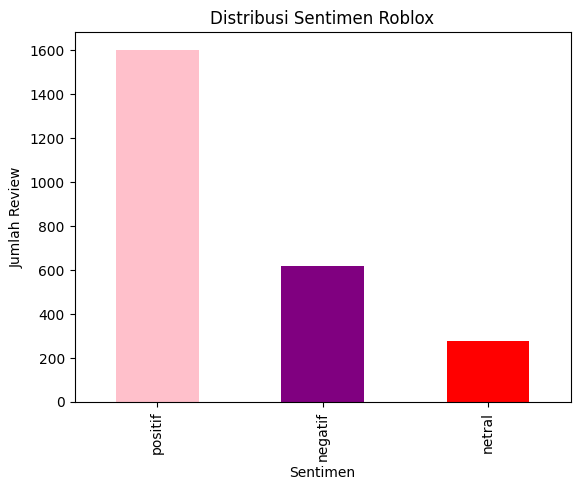

In [129]:
# Bar chart
sentiment_counts.plot(kind='bar', color=['pink','purple','red'])
plt.title('Distribusi Sentimen Roblox')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Review')
plt.show()

In [131]:
# Hitung jumlah tiap sentimen Mobile Legends
sentiment_counts = df_ml['Sentimen'].value_counts()
sentiment_counts

,count
Sentimen,
negatif,1825
positif,476
netral,199


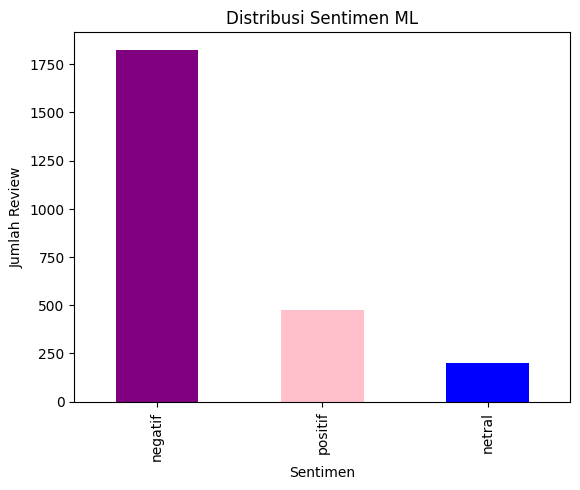

In [132]:
# Bar chart
sentiment_counts.plot(kind='bar', color=['purple','pink','blue'])
plt.title('Distribusi Sentimen ML')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Review')
plt.show()

In [133]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 41.6 MB/s eta 0:00:00


In [134]:
import pyLDAvis.gensim
import pyLDAvis
import warnings
warnings.filterwarnings('ignore')
pyLDAvis.enable_notebook()
vis_rb = pyLDAvis.gensim.prepare(lda_rb, corpus_rb, dictionary_rb)
pyLDAvis.display(vis_rb)

In [135]:
import pyLDAvis.gensim
import pyLDAvis
import warnings
warnings.filterwarnings('ignore')
pyLDAvis.enable_notebook()
vis_ml = pyLDAvis.gensim.prepare(lda_ml, corpus_ml, dictionary_ml)
pyLDAvis.display(vis_ml)

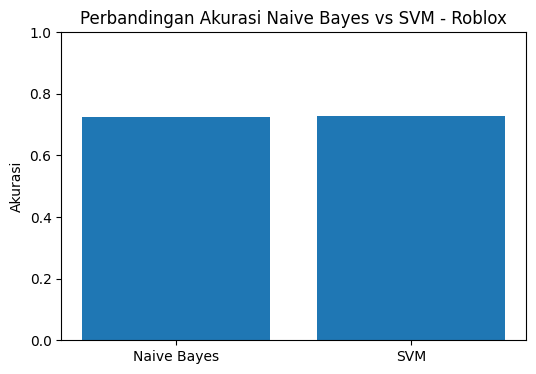

In [136]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def plot_accuracy(App_name, y_test, pred_rb, pred_svm_rb):
    acc_nb = accuracy_score(y_test, pred_rb)
    acc_svm = accuracy_score(y_test, pred_svm_rb)

    models = ['Naive Bayes', 'SVM']
    accuracies = [acc_nb, acc_svm]

    plt.figure(figsize=(6,4))
    plt.bar(models, accuracies)
    plt.ylim(0, 1)
    plt.ylabel("Akurasi")
    plt.title(f"Perbandingan Akurasi Naive Bayes vs SVM - {App_name}")
    plt.show()

plot_accuracy("Roblox", y_test_rb, pred_rb, pred_svm_rb)

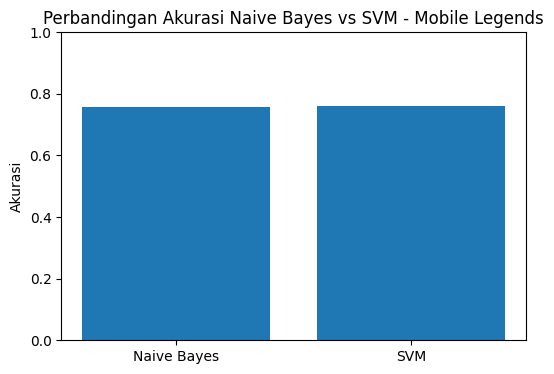

In [137]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def plot_accuracy(App_name, y_test, pred_ml, pred_svm_ml):
    acc_nb = accuracy_score(y_test, pred_ml)
    acc_svm = accuracy_score(y_test, pred_svm_ml)

    models = ['Naive Bayes', 'SVM']
    accuracies = [acc_nb, acc_svm]

    plt.figure(figsize=(6,4))
    plt.bar(models, accuracies)
    plt.ylim(0, 1)
    plt.ylabel("Akurasi")
    plt.title(f"Perbandingan Akurasi Naive Bayes vs SVM - {App_name}")
    plt.show()

plot_accuracy("Mobile Legends", y_test_ml, pred_ml, pred_svm_ml)

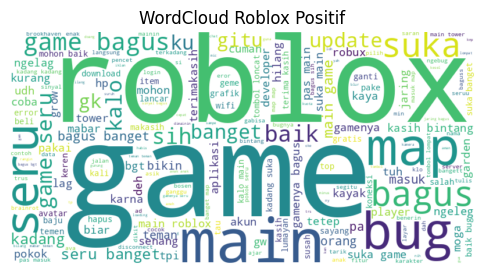

In [138]:
df_roblox = df[df['App_name'] == 'Roblox']
text_roblox_positif = " ".join(df_roblox[df_roblox['Sentimen']=='positif']['Rating Pre-processed'].fillna(''))
wc_roblox = WordCloud(width=800, height=400, background_color='white').generate(text_roblox_positif)

plt.figure(figsize=(6,4))
plt.title("WordCloud Roblox Positif")
plt.imshow(wc_roblox, interpolation='bilinear')
plt.axis("off")
plt.show()

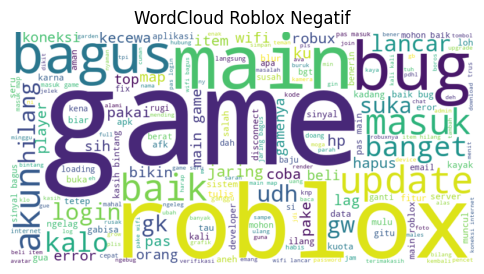

In [139]:
df_roblox = df[df['App_name'] == 'Roblox']
text_roblox_negatif = " ".join(df_roblox[df_roblox['Sentimen']=='negatif']['Rating Pre-processed'].fillna(''))
wc_roblox = WordCloud(width=800, height=400, background_color='white').generate(text_roblox_negatif)

plt.figure(figsize=(6,4))
plt.title("WordCloud Roblox Negatif")
plt.imshow(wc_roblox, interpolation='bilinear')
plt.axis("off")
plt.show()

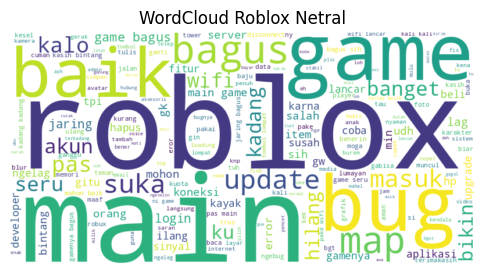

In [140]:
df_roblox = df[df['App_name'] == 'Roblox']
text_roblox_netral = " ".join(df_roblox[df_roblox['Sentimen']=='netral']['Rating Pre-processed'].fillna(''))
wc_roblox = WordCloud(width=800, height=400, background_color='white').generate(text_roblox_netral)

plt.figure(figsize=(6,4))
plt.title("WordCloud Roblox Netral")
plt.imshow(wc_roblox, interpolation='bilinear')
plt.axis("off")
plt.show()

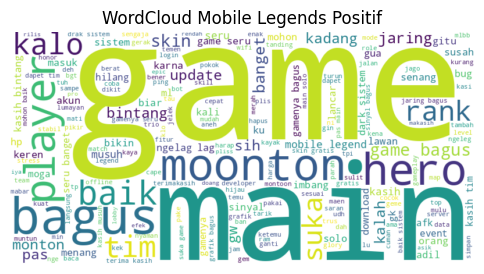

In [141]:
df_ml = df[df['App_name'] == 'Mobile Legends']
text_ml_positif = " ".join(df_ml[df_ml['Sentimen']=='positif']['Rating Pre-processed'].fillna(''))
wc_ml = WordCloud(width=800, height=400, background_color='white').generate(text_ml_positif)

plt.figure(figsize=(6,4))
plt.title("WordCloud Mobile Legends Positif")
plt.imshow(wc_ml, interpolation='bilinear')
plt.axis("off")
plt.show()

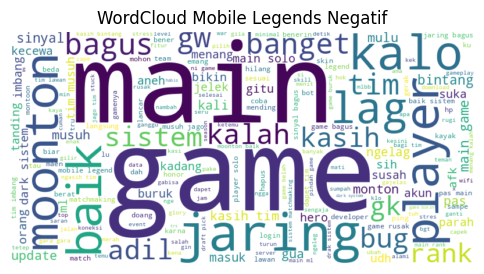

In [142]:
df_ml = df[df['App_name'] == 'Mobile Legends']
text_ml_negatif = " ".join(df_ml[df_ml['Sentimen']=='negatif']['Rating Pre-processed'].fillna(''))
wc_ml = WordCloud(width=800, height=400, background_color='white').generate(text_ml_negatif)

plt.figure(figsize=(6,4))
plt.title("WordCloud Mobile Legends Negatif")
plt.imshow(wc_ml, interpolation='bilinear')
plt.axis("off")
plt.show()

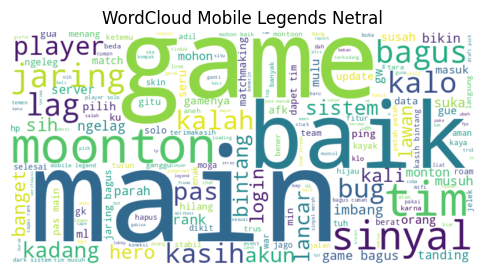

In [143]:
df_ml = df[df['App_name'] == 'Mobile Legends']
text_ml_netral = " ".join(df_ml[df_ml['Sentimen']=='netral']['Rating Pre-processed'].fillna(''))
wc_ml = WordCloud(width=800, height=400, background_color='white').generate(text_ml_netral)

plt.figure(figsize=(6,4))
plt.title("WordCloud Mobile Legends Netral")
plt.imshow(wc_ml, interpolation='bilinear')
plt.axis("off")
plt.show()

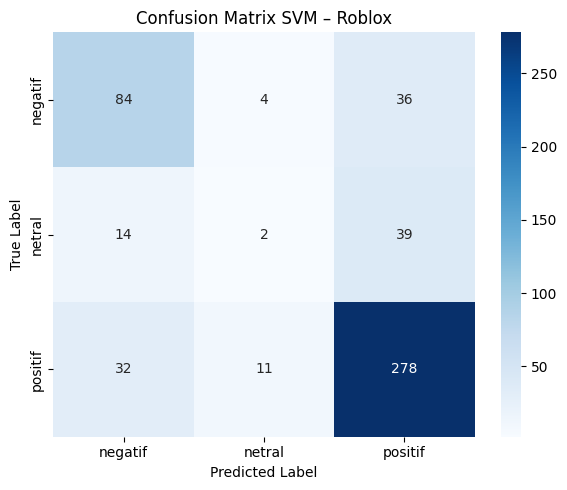

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_rb = confusion_matrix(y_test_rb, pred_svm_rb)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=svm_rb.classes_,
    yticklabels=svm_rb.classes_
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix SVM – Roblox')
plt.tight_layout()
plt.show()

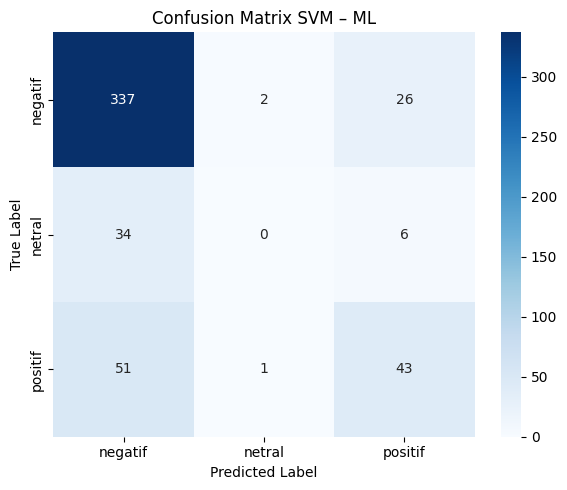

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_rb = confusion_matrix(y_test_ml, pred_svm_ml)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=svm_ml.classes_,
    yticklabels=svm_ml.classes_
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix SVM – ML')
plt.tight_layout()
plt.show()

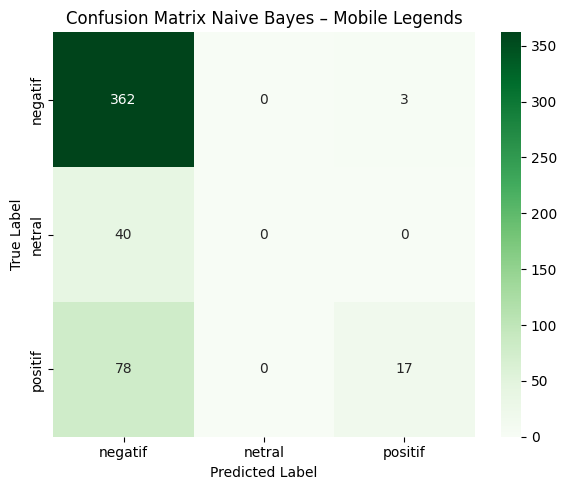

In [146]:
cm_nb = confusion_matrix(y_test_ml, pred_ml)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=model_ml.classes_,
    yticklabels=model_ml.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Naive Bayes – Mobile Legends")
plt.tight_layout()
plt.show()

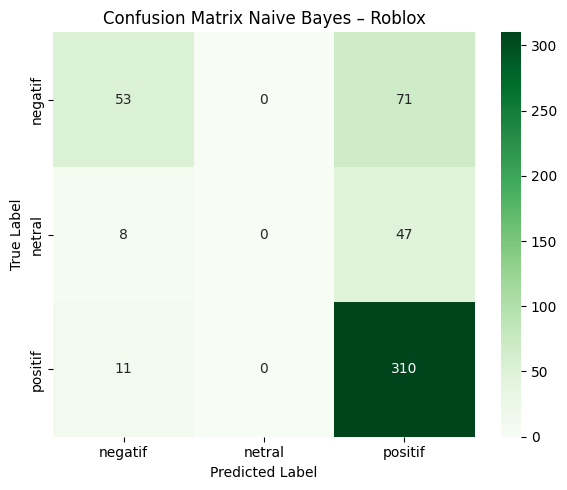

In [147]:
cm_nb = confusion_matrix(y_test_rb, pred_rb)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=model_rb.classes_,
    yticklabels=model_rb.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Naive Bayes – Roblox")
plt.tight_layout()
plt.show()

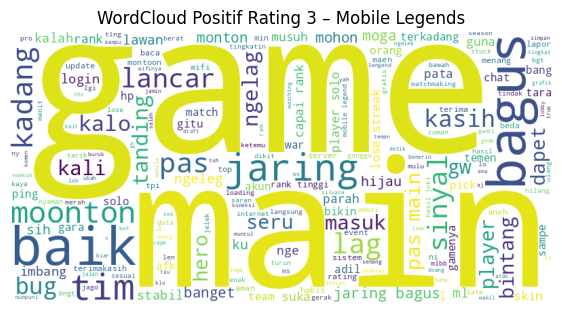

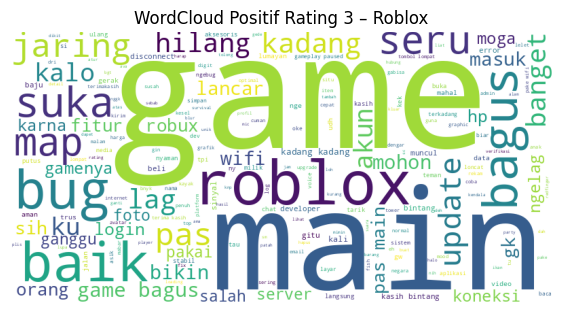

In [157]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

apps = df_3['App_name'].unique()

for app in apps:
  text_pos = " ".join(df_3[(df_3['App_name'] == app) & (df_3['Kecenderungan_sentimen'] == 'positif')]['Rating Pre-processed'].dropna())

  if text_pos.strip() != "":
        wc = WordCloud(width=800, height=400, background_color='white').generate(text_pos)
        plt.figure(figsize=(7,4))
        plt.imshow(wc)
        plt.axis('off')
        plt.title(f'WordCloud Positif Rating 3 – {app}')
        plt.show()


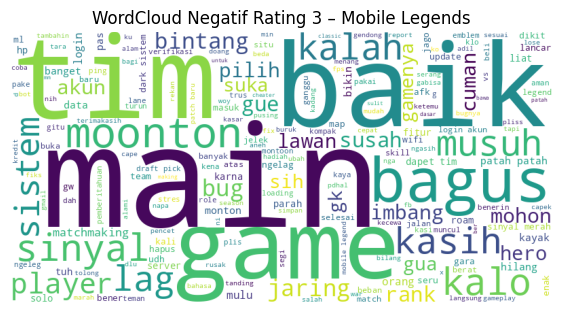

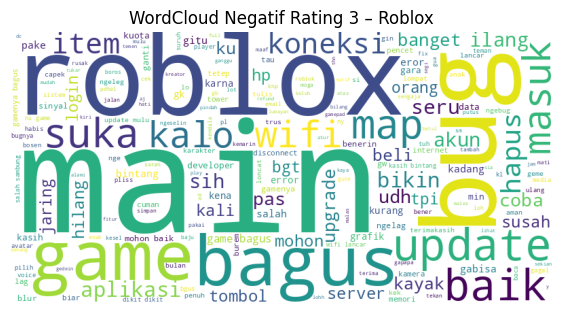

In [158]:
for app in apps:
    text_neg = " ".join(
        df_3[(df_3['App_name'] == app) & (df_3['Kecenderungan_sentimen'] == 'negatif')]['Rating Pre-processed'].dropna())

    if text_neg.strip() != "":
        wc = WordCloud(width=800, height=400, background_color='white').generate(text_neg)
        plt.figure(figsize=(7,4))
        plt.imshow(wc)
        plt.axis('off')
        plt.title(f'WordCloud Negatif Rating 3 – {app}')
        plt.show()
